# Introduction: from raw evidence to evaluated, reproducible models

This notebook is a portfolio-oriented companion to the Hack The Box Academy module **Applications of AI in InfoSec**. It follows a complete applied machine-learning lifecycle across several security data modalities: inventorying raw evidence, defining data-quality rules, transforming observations into model-ready representations, splitting data without leakage, training and tuning models, evaluating them with operationally meaningful metrics, and preserving the resulting artifacts for reuse.

The notebook intentionally keeps the executable workflow intact while adding a narrative layer around it. The code cells retain the lesson implementation and the progressively added analytical work; the surrounding prose explains why each operation exists, what the result tells us, and how the result informs the next decision. Where the notebook extends the lesson with audits, diagnostics, visualizations, validation controls, or artifact checks, those extensions are described as notebook analysis rather than presented as source material from the lesson.

## Scope and analytical stance

The recurring question is not simply *can a model classify an observation?* It is *what evidence was available, what assumptions were introduced, how trustworthy is the evaluation, and how would the artifact behave after it leaves the notebook?* That distinction matters in security work, where a false negative can represent an undetected attack, a false positive can consume analyst time, and a seemingly excellent aggregate score can conceal failure on a rare but important class.

The analyses therefore use a consistent progression:

1. establish the dataset’s structure, provenance, and quality;
2. make cleaning and representation choices explicit;
3. reserve evaluation data before model selection wherever possible;
4. measure more than a single headline accuracy;
5. inspect errors and subgroup behavior;
6. export, reload, and smoke-test the model artifact.

The notebook is stateful: execute code cells from top to bottom after a kernel restart when reproducing the work. The narrative assumes the imports, paths, helper functions, and fitted objects created earlier remain available. The source material and the notebook’s additions are also separated conceptually: the lesson supplies the baseline workflow, while the notebook layers in engineering discipline and analyst-facing diagnostics.

## Table of contents

1. [Introduction: from raw evidence to evaluated, reproducible models](#introduction-from-raw-evidence-to-evaluated-reproducible-models)
2. [Network event logs: establish a data contract](#network-event-logs-establish-a-data-contract)
3. [SMS spam detection: turn language into evidence](#sms-spam-detection-turn-language-into-evidence)
4. [Network anomaly detection: model structured traffic](#network-anomaly-detection-model-structured-traffic)
5. [Malware image classification: learn from byteplot structure](#malware-image-classification-learn-from-byteplot-structure)
6. [IMDB Sentiment classification as a deployment exercise: Skills assessment](#imdb-sentiment-classification-as-a-deployment-exercise-skills-assessment)
7. [Conclusion: a reusable security-ML workflow](#conclusion-a-reusable-security-ml-workflow)


# Network event logs: establish a data contract

We begin with a deliberately small network-log dataset. Its purpose is not to support a production claim; it is a compact environment in which the fundamentals of applied AI become visible: columns have different semantic types, malformed values can look superficially plausible, missingness may be encoded as text, and the target may be imbalanced. The fields describe a log identifier, source address, destination port, protocol, transferred bytes, and a threat label.

The first pass will establish the data contract: what each column represents, which values are valid, how much information is missing or malformed, and which assumptions are safe to carry into modeling. We will then compare exclusion and imputation strategies, transform skewed and categorical variables, create a reproducible split, and use a simple baseline before introducing a worked Bayesian probability example.


In [1]:
# HTB lesson content: combines the loading and initial-inspection snippets;
# the local path is normalized for this notebook.
import pandas as pd

data = pd.read_csv("demo_dataset.csv")

print(data.head())
print(data.info())
print(data.isnull().sum())

   log_id       source_ip destination_port protocol bytes_transferred  \
0      10      10.0.0.100      STRING_PORT      FTP              4096   
1      12  172.16.254.100              110     POP3          NEGATIVE   
2      27  172.16.254.200              110     POP3       NON_NUMERIC   
3       1   192.168.1.100               80     HTTP              1024   
4       2    192.168.1.81               53      TLS              9765   

  threat_level  
0            ?  
1            1  
2            1  
3            0  
4            0  
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   log_id             100 non-null    int64
 1   source_ip          99 non-null     str  
 2   destination_port   99 non-null     str  
 3   protocol           100 non-null    str  
 4   bytes_transferred  100 non-null    str  
 5   threat_level       100 non-null    str  

## Load and first inspection

The first code block loads the CSV and inspects its head, schema, and null counts. The dataset contains 100 records across six fields. Several columns arrive as strings even though they have numeric meaning, and the initial inspection exposes the important distinction between a literal null and a sentinel such as `STRING_PORT`, `NEGATIVE`, or `NON_NUMERIC`. A data frame can therefore appear structurally complete while still violating the semantics required by downstream analysis.

The next group turns that observation into executable validation rules. Rather than allowing coercion to silently decide what is valid, we will count malformed IP addresses, ports, protocols, bytes, and threat labels explicitly.


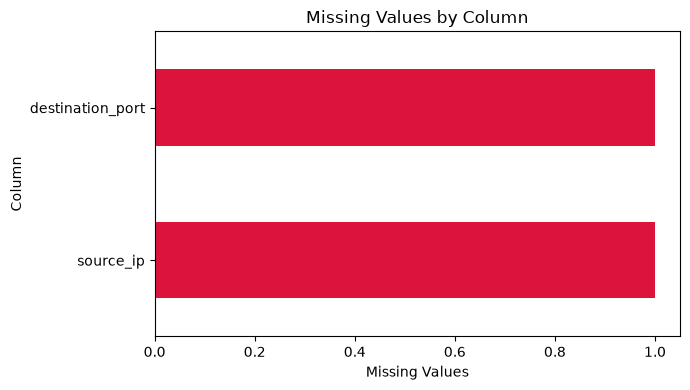

In [2]:
# Personal notebook addition (not in HTB): visualize the missingness
# identified by HTB's inspection step.
# Chart selection and presentation are personal.

import matplotlib.pyplot as plt

missing_counts = data.isna().sum()
# Hide columns with no missing values so the chart stays focused.
missing_counts = missing_counts[missing_counts > 0].sort_values()

plt.figure(figsize=(7, 4))
missing_counts.plot(kind="barh", color="crimson")
plt.title("Missing Values by Column")
plt.xlabel("Missing Values")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [3]:
# HTB lesson workflow: consolidate validation checks for IPs, ports,
# protocols, bytes, and threat level.
# Notebook adaptation: adds explicit NaN handling and fullmatch for the IP
# validator; validation criteria follow HTB.
import re

def is_valid_ip(ip):
    if pd.isna(ip):
        return False

    pattern = re.compile(
        r'^((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)\.){3}'
        r'(25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)$'
    )
    return bool(pattern.fullmatch(ip))

# Check for invalid IP addresses
invalid_ips = data[~data['source_ip'].astype(str).apply(is_valid_ip)]
print(invalid_ips)

def is_valid_port(port):
    try:
        port = int(port)
        return 0 <= port <= 65535
    except ValueError:
        return False

# Check for invalid port numbers
invalid_ports = data[~data['destination_port'].apply(is_valid_port)]
print(invalid_ports)

valid_protocols = [
    'TCP', 'TLS', 'SSH', 'POP3', 'DNS', 'HTTPS', 'SMTP', 'FTP', 'UDP', 'HTTP'
]

# Check for invalid protocol values
invalid_protocols = data[~data['protocol'].isin(valid_protocols)]
print(invalid_protocols)

def is_valid_bytes(bytes):
    try:
        bytes = int(bytes)
        return bytes >= 0
    except ValueError:
        return False

# Check for invalid bytes transferred
invalid_bytes = data[~data['bytes_transferred'].apply(is_valid_bytes)]
print(invalid_bytes)

def is_valid_threat_level(threat_level):
    try:
        threat_level = int(threat_level)
        return 0 <= threat_level <= 2
    except ValueError:
        return False

# Check for invalid threat levels
invalid_threat_levels = data[
    ~data['threat_level'].apply(is_valid_threat_level)
]
print(invalid_threat_levels)

    log_id       source_ip destination_port protocol bytes_transferred  \
40      41      10.0.0.300               25     SMTP              4096   
51      52    10.10.10.450      STRING_PORT      FTP              4096   
55      56             NaN               53      DNS              1024   
57      58   192.168.1.475              NaN      UDP              2048   
63      64      MISSING_IP               53      DNS              1024   
65      66   192.168.1.600      UNUSED_PORT      UDP              2048   
71      72      MISSING_IP               53      DNS              1024   
74      75    172.16.1.400               80     HTTP              1024   
82      83    172.16.1.450               80     HTTP              1024   
87      88      MISSING_IP               53      DNS              1024   
88      89    10.10.10.700              443      TLS               512   
92      93      INVALID_IP              110     POP3              4096   
93      94  192.168.1.1050            

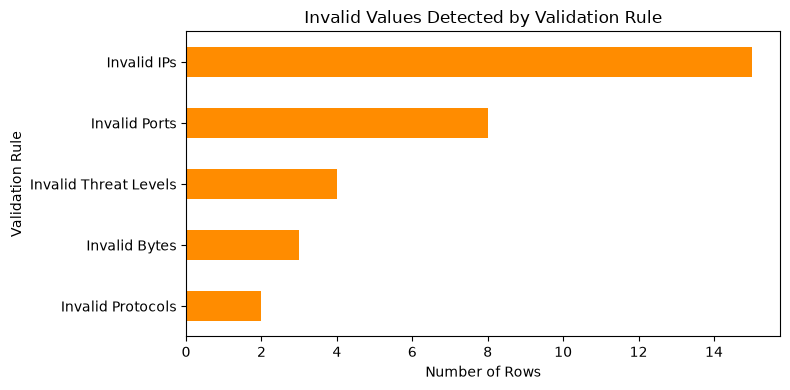

In [4]:
# Personal notebook addition (not in HTB): summarize counts from the
# HTB-derived validation outputs before dropping rows.
# Counts can overlap when one row violates multiple validation rules, so this
# is not a unique-row total.

invalid_counts = pd.Series({
    "Invalid IPs": len(invalid_ips),
    "Invalid Ports": len(invalid_ports),
    "Invalid Protocols": len(invalid_protocols),
    "Invalid Bytes": len(invalid_bytes),
    "Invalid Threat Levels": len(invalid_threat_levels)
}).sort_values()

plt.figure(figsize=(8, 4))
invalid_counts.plot(kind="barh", color="darkorange")
plt.title("Invalid Values Detected by Validation Rule")
plt.xlabel("Number of Rows")
plt.ylabel("Validation Rule")
plt.tight_layout()
plt.show()

In [5]:
# HTB lesson content: sequentially drop rows flagged by the five validation
# checks.
# HTB's errors='ignore' safeguard handles overlap across invalid-index sets.
data = data.drop(invalid_ips.index, errors='ignore') 
data = data.drop(invalid_ports.index, errors='ignore')
data = data.drop(invalid_protocols.index, errors='ignore')
data = data.drop(invalid_bytes.index, errors='ignore')
data = data.drop(invalid_threat_levels.index, errors='ignore')

print(data.describe(include='all'))

            log_id     source_ip destination_port protocol bytes_transferred  \
count    77.000000            77               77       77                77   
unique         NaN            68                6        9                73   
top            NaN  192.168.1.55               80     HTTP              1024   
freq           NaN             3               22       22                 4   
mean     46.519481           NaN              NaN      NaN               NaN   
std      28.591317           NaN              NaN      NaN               NaN   
min       1.000000           NaN              NaN      NaN               NaN   
25%      22.000000           NaN              NaN      NaN               NaN   
50%      45.000000           NaN              NaN      NaN               NaN   
75%      70.000000           NaN              NaN      NaN               NaN   
max     100.000000           NaN              NaN      NaN               NaN   

       threat_level  
count            

## Data-quality decisions: exclusion versus repair

The validation pass identifies invalid values in the source address, destination port, and transferred-byte fields. Dropping every row that violates a rule produces a smaller clean subset—77 rows in this example—but that choice is consequential: on a small dataset, removing 23% of the observations can change the class mix and discard potentially informative events.

The notebook therefore keeps the original frame available and develops a separate imputation path. This is an important analytical boundary: “clean” should not mean “silently altered,” and a repair strategy should be auditable against the raw observations. The next cells normalize known placeholders to missing values and coerce only fields whose semantics support numeric treatment.


In [6]:
# HTB lesson content: replace known placeholders, coerce numeric fields, and
# convert invalid source IPs to NaN.
import pandas as pd
import numpy as np
import re
from ipaddress import ip_address

df = pd.read_csv('demo_dataset.csv')

invalid_ips = ['INVALID_IP', 'MISSING_IP']
invalid_ports = ['STRING_PORT', 'UNUSED_PORT']
invalid_bytes = ['NON_NUMERIC', 'NEGATIVE']
invalid_threat = ['?']

df.replace(
    invalid_ips + invalid_ports + invalid_bytes + invalid_threat,
    np.nan,
    inplace=True
)

df['destination_port'] = pd.to_numeric(
    df['destination_port'], errors='coerce'
)
df['bytes_transferred'] = pd.to_numeric(
    df['bytes_transferred'], errors='coerce'
)
df['threat_level'] = pd.to_numeric(df['threat_level'], errors='coerce')

def is_valid_ip(ip):
    pattern = re.compile(
        r'^((25[0-5]|2[0-4][0-9]|[01]?\d?\d)\.){3}'
        r'(25[0-5]|2[0-4]\d|[01]?\d?\d)$'
    )
    if pd.isna(ip) or not pattern.match(str(ip)):
        return np.nan
    return ip

df['source_ip'] = df['source_ip'].apply(is_valid_ip)

In [7]:
# HTB lesson content: median-impute numeric fields and mode-impute the
# protocol field.
from sklearn.impute import SimpleImputer

numeric_cols = ['destination_port', 'bytes_transferred', 'threat_level']
categorical_cols = ['protocol']

num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [8]:
# HTB lesson content: apply KNN imputation to the numeric fields.
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])

In [9]:
# HTB lesson content: restore valid protocol values, fill missing IPs, and
# bound destination ports.
valid_protocols = [
    'TCP', 'TLS', 'SSH', 'POP3', 'DNS', 'HTTPS', 'SMTP', 'FTP', 'UDP', 'HTTP'
]
df.loc[~df['protocol'].isin(valid_protocols), 'protocol'] = (
    df['protocol'].mode()[0]
)

df['source_ip'] = df['source_ip'].fillna('0.0.0.0')
df['destination_port'] = df['destination_port'].clip(lower=0, upper=65535)

## Reconcile missing values while preserving meaning

The imputation workflow restores a usable 100-row analysis frame. Numeric fields use robust summaries or nearest-neighbor estimates; the protocol uses its mode; invalid ports are constrained to the legal range; and an unavailable address is represented explicitly as `0.0.0.0`. The address validator also has to handle `NaN` before applying string-based checks—an example of how data cleaning often fails at the interface between pandas’ missing-value representation and a domain-specific parser.

These choices are pragmatic for a teaching dataset, not universal defaults. In a production pipeline, the sentinel address would be documented as an “unknown” category, imputation statistics would be learned only on training data, and the proportion and mechanism of missingness would be monitored over time. With that caveat established, the following cells summarize the repaired data and inspect its distributions.


In [10]:
# HTB lesson content: inspect the cleaned dataset with descriptive statistics.
print(df.describe(include='all'))

            log_id source_ip  destination_port protocol  bytes_transferred  \
count   100.000000       100        100.000000      100          100.00000   
unique         NaN        76               NaN        9                NaN   
top            NaN   0.0.0.0               NaN     HTTP                NaN   
freq           NaN        15               NaN       27                NaN   
mean     50.500000       NaN        776.860000      NaN         4138.64000   
std      29.011492       NaN       6542.582099      NaN         2526.40978   
min       1.000000       NaN         22.000000      NaN          498.00000   
25%      25.750000       NaN         53.000000      NaN         1693.25000   
50%      50.500000       NaN         80.000000      NaN         4096.00000   
75%      75.250000       NaN        110.000000      NaN         5971.75000   
max     100.000000       NaN      65535.000000      NaN         9765.00000   

        threat_level  
count     100.000000  
unique           

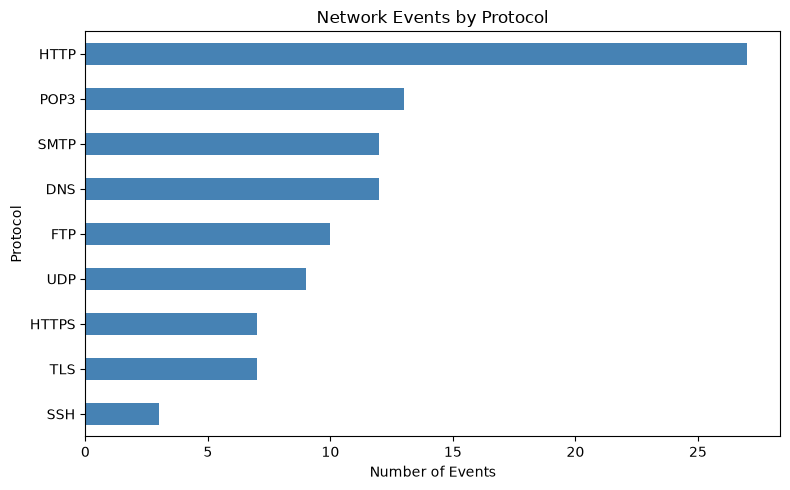

In [11]:
import matplotlib.pyplot as plt

# Personal notebook addition (not in HTB): plot protocol frequencies while the
# original categorical column still exists.
protocol_counts = df["protocol"].value_counts().sort_values()

plt.figure(figsize=(8, 5))
protocol_counts.plot(kind="barh", color="steelblue")
plt.title("Network Events by Protocol")
plt.xlabel("Number of Events")
plt.ylabel("Protocol")
plt.tight_layout()
plt.show()

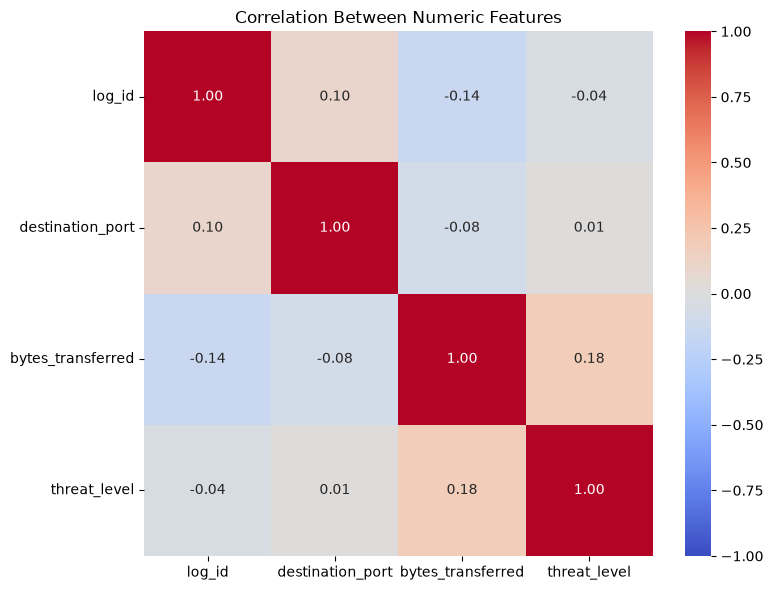

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Personal notebook addition (not in HTB): compare numeric features to
# identify relationships or possible redundancy.
numeric_view = df.select_dtypes(include="number")
correlation_matrix = numeric_view.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

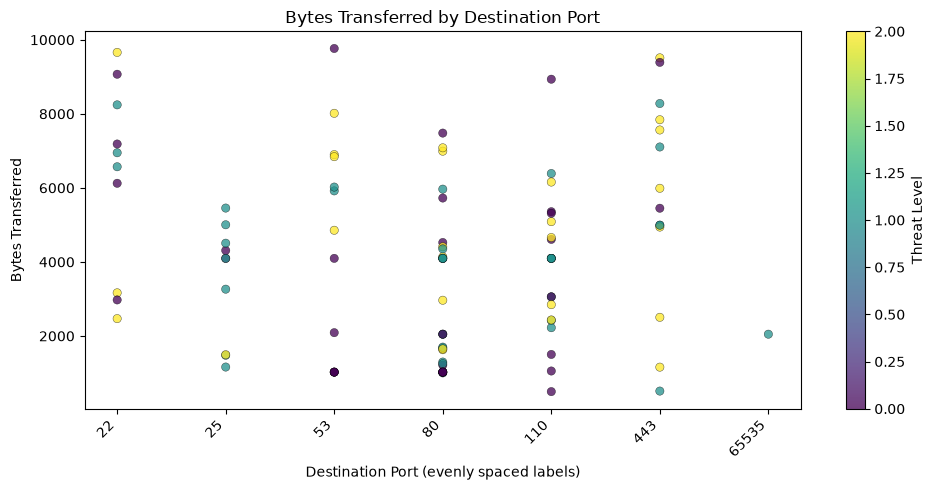

In [13]:
# Personal notebook addition (not in HTB): compare byte volume by port and
# threat level.
# Observed ports are placed at evenly spaced categorical positions so every
# label remains explicit.

port_values = sorted(df["destination_port"].dropna().unique())
port_positions = {port: position for position, port in enumerate(port_values)}
x_positions = df["destination_port"].map(port_positions)

plt.figure(figsize=(10, 5))

scatter = plt.scatter(
    x_positions,
    df["bytes_transferred"],
    c=df["threat_level"],
    cmap="viridis",
    alpha=0.75,
    edgecolors="black",
    linewidths=0.3
)

port_labels = [
    str(int(port)) if float(port).is_integer() else str(port)
    for port in port_values
]

plt.xticks(
    range(len(port_values)),
    port_labels,
    rotation=45,
    ha="right"
)
plt.colorbar(scatter, label="Threat Level")
plt.title("Bytes Transferred by Destination Port")
plt.xlabel("Destination Port (evenly spaced labels)")
plt.ylabel("Bytes Transferred")
plt.tight_layout()
plt.show()

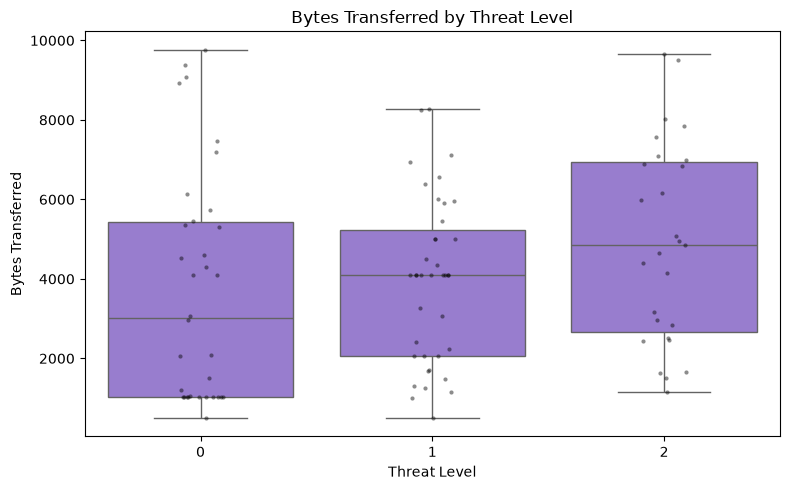

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Personal notebook addition (not in HTB): compare byte-transfer distributions
# by threat level.
plot_data = df.copy()
plot_data["threat_level"] = plot_data["threat_level"].round().astype(int)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=plot_data,
    x="threat_level",
    y="bytes_transferred",
    color="mediumpurple"
)
sns.stripplot(
    data=plot_data,
    x="threat_level",
    y="bytes_transferred",
    color="black",
    alpha=0.45,
    jitter=True,
    size=3
)
plt.title("Bytes Transferred by Threat Level")
plt.xlabel("Threat Level")
plt.ylabel("Bytes Transferred")
plt.tight_layout()
plt.show()

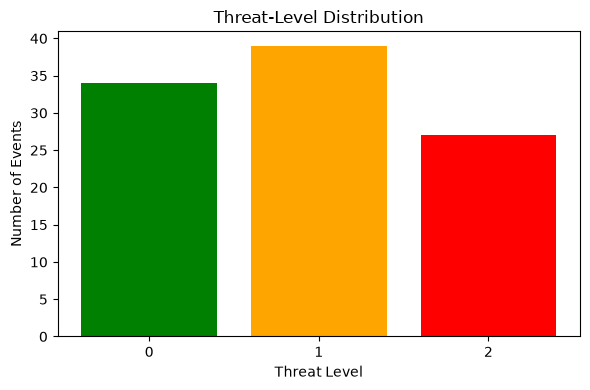

In [15]:
import matplotlib.pyplot as plt

# Personal notebook addition (not in HTB): treat threat levels as categories
# and show their frequencies after cleaning.
threat_counts = (
    df["threat_level"]
    .round()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))
plt.bar(
    threat_counts.index.astype(str),
    threat_counts.values,
    color=["green", "orange", "red"]
)

plt.title("Threat-Level Distribution")
plt.xlabel("Threat Level")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()

## Explore the cleaned event population

The cleaned frame now supports meaningful summaries: protocol frequencies show which transport types dominate the sample, correlations expose relationships among numeric fields, and the threat-count view shows how much signal is available for a classifier. The bytes-by-port and threat-level views are especially useful because they connect a raw measurement to a categorical network context.

This is the point at which descriptive analysis becomes feature design. A protocol is categorical and needs an explicit representation; transferred bytes are nonnegative and commonly right-skewed; and a port number is an identifier-like category rather than a continuous quantity whose numeric distance necessarily carries meaning. The next cells make those distinctions explicit.


In [16]:
# Personal notebook addition (not in HTB): preserve pre-log values for a later
# before-and-after comparison.

bytes_before_log = df["bytes_transferred"].copy()

In [17]:
# HTB lesson content: one-hot encode the protocol field and combine it with
# the remaining features.
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(df[['protocol']])

encoded_df = pd.DataFrame(
    encoded, columns=encoder.get_feature_names_out(['protocol'])
)
df = pd.concat([df.drop('protocol', axis=1), encoded_df], axis=1)

In [18]:
# HTB lesson content: apply log1p to bytes_transferred to reduce skew while
# retaining zero values.
import numpy as np

# Apply logarithmic transformation to a skewed feature to reduce its skewness
# Add 1 to avoid log(0)
df["bytes_transferred"] = np.log1p(df["bytes_transferred"])

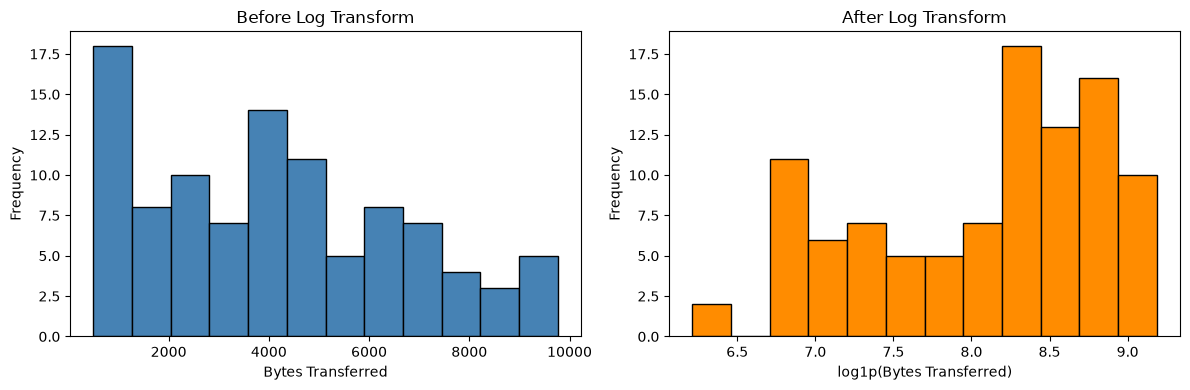

In [19]:
import matplotlib.pyplot as plt

# Personal notebook addition (not in HTB): compare the feature distribution
# before and after HTB's log transformation.
# The chart illustrates how log1p compresses large values and makes skew
# easier to inspect.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    bytes_before_log.dropna(),
    bins=12,
    color="steelblue",
    edgecolor="black"
)
axes[0].set_title("Before Log Transform")
axes[0].set_xlabel("Bytes Transferred")
axes[0].set_ylabel("Frequency")

axes[1].hist(
    df["bytes_transferred"].dropna(),
    bins=12,
    color="darkorange",
    edgecolor="black"
)
axes[1].set_title("After Log Transform")
axes[1].set_xlabel("log1p(Bytes Transferred)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Transform variables for modeling

Protocol is one-hot encoded so that the model does not interpret arbitrary integer labels as an order. Transferred bytes are preserved in their original units and then transformed with `log1p`, which handles zero safely while reducing the influence of extreme values. The before-and-after distribution makes the effect visible rather than leaving it as an opaque preprocessing step.

With the feature semantics established, the dataset is split into fit, validation, and test partitions. The two-stage split produces an overall 60/20/20 allocation: the second 25% split is taken from the 80% temporary remainder. The next cells verify the resulting threat proportions and set a majority-class baseline before any more sophisticated probability calculation.


In [20]:
# HTB lesson content: perform the two-stage 60%/20%/20% train, validation, and
# test split.
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop("threat_level", axis=1)
y = df["threat_level"]

# Initial split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1337
)

# Second split: from the 80% training portion, allocate 60% for final training
# and 20% for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=1337
)

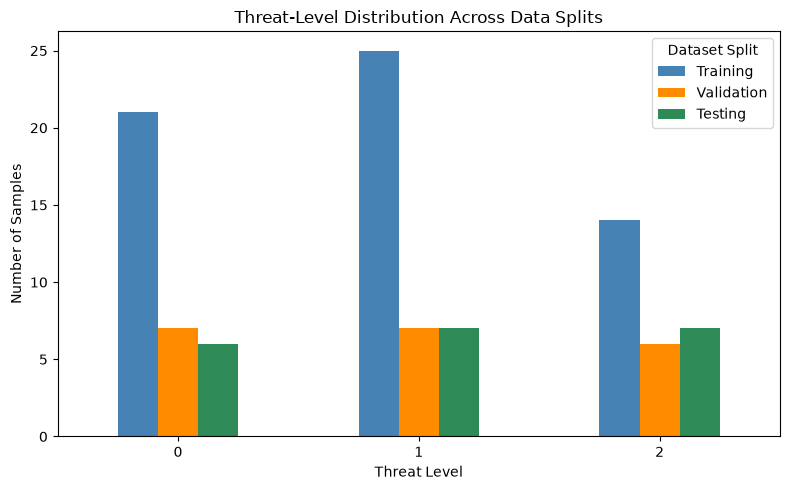

In [21]:
# Personal notebook addition (not in HTB): compare threat-level counts across
# the HTB-derived training, validation, and test subsets.
# This helps reveal whether the split produced noticeably different class
# balances.

split_counts = pd.DataFrame({
    "Training": y_train.round().astype(int).value_counts(),
    "Validation": y_val.round().astype(int).value_counts(),
    "Testing": y_test.round().astype(int).value_counts()
}).fillna(0).sort_index()

ax = split_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "darkorange", "seagreen"]
)

ax.set_title("Threat-Level Distribution Across Data Splits")
ax.set_xlabel("Threat Level")
ax.set_ylabel("Number of Samples")
ax.legend(title="Dataset Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
# Personal notebook addition (not in HTB): establish a majority-class baseline
# before evaluating a real model.
# It applies evaluation concepts from the Metrics lesson; HTB did not provide
# this baseline implementation.

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    ConfusionMatrixDisplay
)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

baseline_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Weighted Precision": precision_score(
        y_test, y_pred_baseline, average="weighted", zero_division=0
    ),
    "Weighted Recall": recall_score(
        y_test, y_pred_baseline, average="weighted", zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test, y_pred_baseline, average="weighted", zero_division=0
    ),
    "MCC": matthews_corrcoef(y_test, y_pred_baseline)
})

display(baseline_metrics.to_frame("Score"))

,Score
Accuracy,0.350000
Weighted Precision,0.122500
Weighted Recall,0.350000
Weighted F1,0.181481
MCC,0.000000


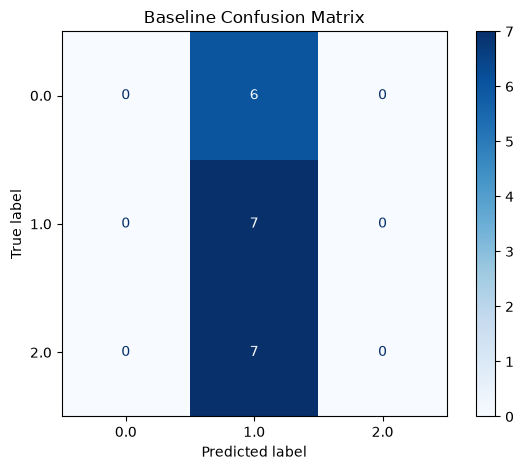

              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00         6
         1.0       0.35      1.00      0.52         7
         2.0       0.00      0.00      0.00         7

    accuracy                           0.35        20
   macro avg       0.12      0.33      0.17        20
weighted avg       0.12      0.35      0.18        20



In [23]:
# Personal notebook addition (not in HTB): show which classes the personal
# majority baseline confuses or misses.

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    cmap="Blues",
    values_format="d"
)

plt.title("Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

print(classification_report(
    y_test,
    y_pred_baseline,
    zero_division=0
))

## Establish a baseline before invoking a model

The majority-class baseline and its confusion matrix provide a necessary reference point. Accuracy alone can look respectable when one class dominates, while the confusion matrix makes the missed minority events visible. Any later classifier should be judged against this simple alternative, not against an abstract notion of perfection.

The following cells introduce Bayes’ theorem through a small two-feature example. With priors of 0.3 for spam and 0.7 for not-spam, conditional feature probabilities produce joint likelihoods of 0.20 and 0.06, an evidence term of 0.102, and a posterior spam probability of approximately 0.588. The worked calculation is a bridge from data-quality and baseline reasoning to the probabilistic text-classification case study that follows.


In [24]:
# HTB lesson example reimplemented as executable Python: Naive Bayes posterior
# calculation.
# Personal adaptation: descriptive variables and a results table; HTB supplied
# the probabilities and arithmetic, not this code form.

nb_prior_spam = 0.3
nb_prior_not_spam = 0.7

nb_f1_given_spam = 0.4
nb_f2_given_spam = 0.5
nb_f1_given_not_spam = 0.2
nb_f2_given_not_spam = 0.3

nb_joint_spam = nb_f1_given_spam * nb_f2_given_spam
nb_joint_not_spam = nb_f1_given_not_spam * nb_f2_given_not_spam

nb_evidence = (
    nb_joint_spam * nb_prior_spam
    + nb_joint_not_spam * nb_prior_not_spam
)

nb_spam_probability = (
    nb_joint_spam * nb_prior_spam
) / nb_evidence

nb_not_spam_probability = (
    nb_joint_not_spam * nb_prior_not_spam
) / nb_evidence

nb_results = pd.Series({
    "P(Spam | F1, F2)": nb_spam_probability,
    "P(Not Spam | F1, F2)": nb_not_spam_probability
})

display(nb_results.to_frame("Probability"))

,Probability
"P(Spam | F1, F2)",0.588235
"P(Not Spam | F1, F2)",0.411765


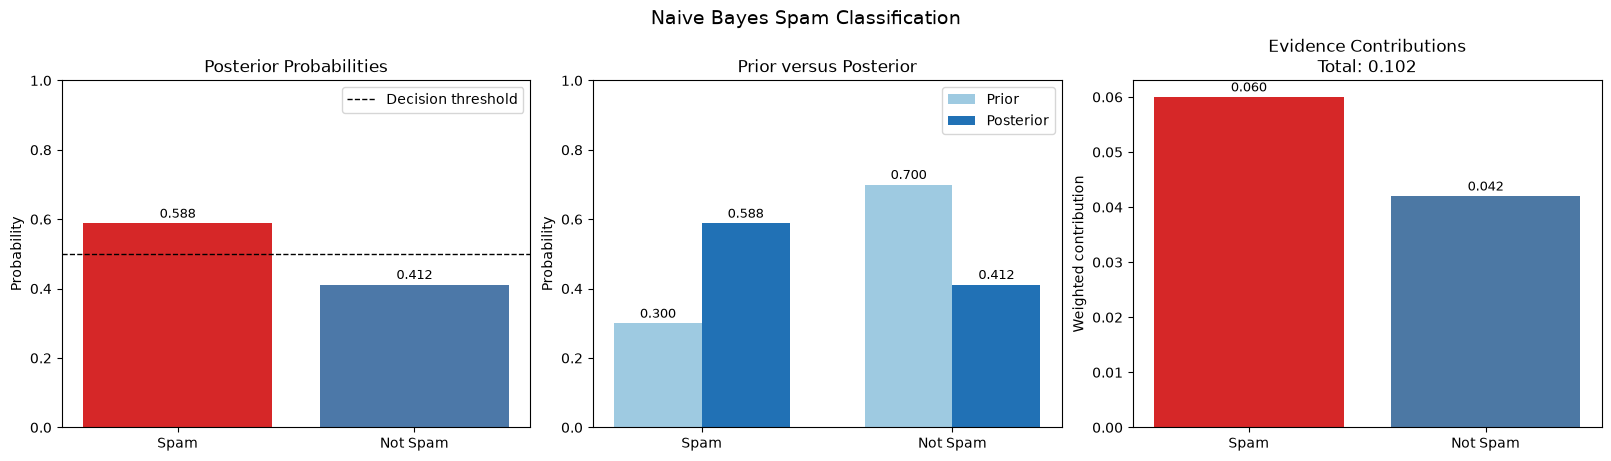

In [25]:
# Personal notebook addition (not in HTB): extend HTB's Naive Bayes example
# with a three-panel bar-chart comparison.

import numpy as np
import matplotlib.pyplot as plt

posterior_values = pd.Series({
    "Spam": nb_spam_probability,
    "Not Spam": nb_not_spam_probability
})

probability_comparison = pd.DataFrame(
    {
        "Prior": [nb_prior_spam, nb_prior_not_spam],
        "Posterior": [nb_spam_probability, nb_not_spam_probability]
    },
    index=["Spam", "Not Spam"]
)

evidence_contributions = pd.Series({
    "Spam": nb_joint_spam * nb_prior_spam,
    "Not Spam": nb_joint_not_spam * nb_prior_not_spam
})


def annotate_bars(ax, bars):
    for bar in bars:
        value = bar.get_height()
        ax.annotate(
            f"{value:.3f}",
            xy=(bar.get_x() + bar.get_width() / 2, value),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )


fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
    constrained_layout=True
)

# Chart 1: posterior probabilities
bars = axes[0].bar(
    posterior_values.index,
    posterior_values.values,
    color=["#d62728", "#4c78a8"]
)

axes[0].axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Decision threshold"
)

axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Probability")
axes[0].set_title("Posterior Probabilities")
axes[0].legend(loc="upper right")
annotate_bars(axes[0], bars)

# Chart 2: prior versus posterior
x = np.arange(2)
width = 0.35

prior_bars = axes[1].bar(
    x - width / 2,
    probability_comparison["Prior"],
    width,
    label="Prior",
    color="#9ecae1"
)

posterior_bars = axes[1].bar(
    x + width / 2,
    probability_comparison["Posterior"],
    width,
    label="Posterior",
    color="#2171b5"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(["Spam", "Not Spam"])
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Probability")
axes[1].set_title("Prior versus Posterior")
axes[1].legend(loc="upper right")

annotate_bars(axes[1], prior_bars)
annotate_bars(axes[1], posterior_bars)

# Chart 3: evidence contributions
bars = axes[2].bar(
    evidence_contributions.index,
    evidence_contributions.values,
    color=["#d62728", "#4c78a4"]
)

axes[2].set_ylabel("Weighted contribution")
axes[2].set_title(
    f"Evidence Contributions\nTotal: {nb_evidence:.3f}"
)

annotate_bars(axes[2], bars)

fig.suptitle(
    "Naive Bayes Spam Classification",
    fontsize=14
)

plt.show()

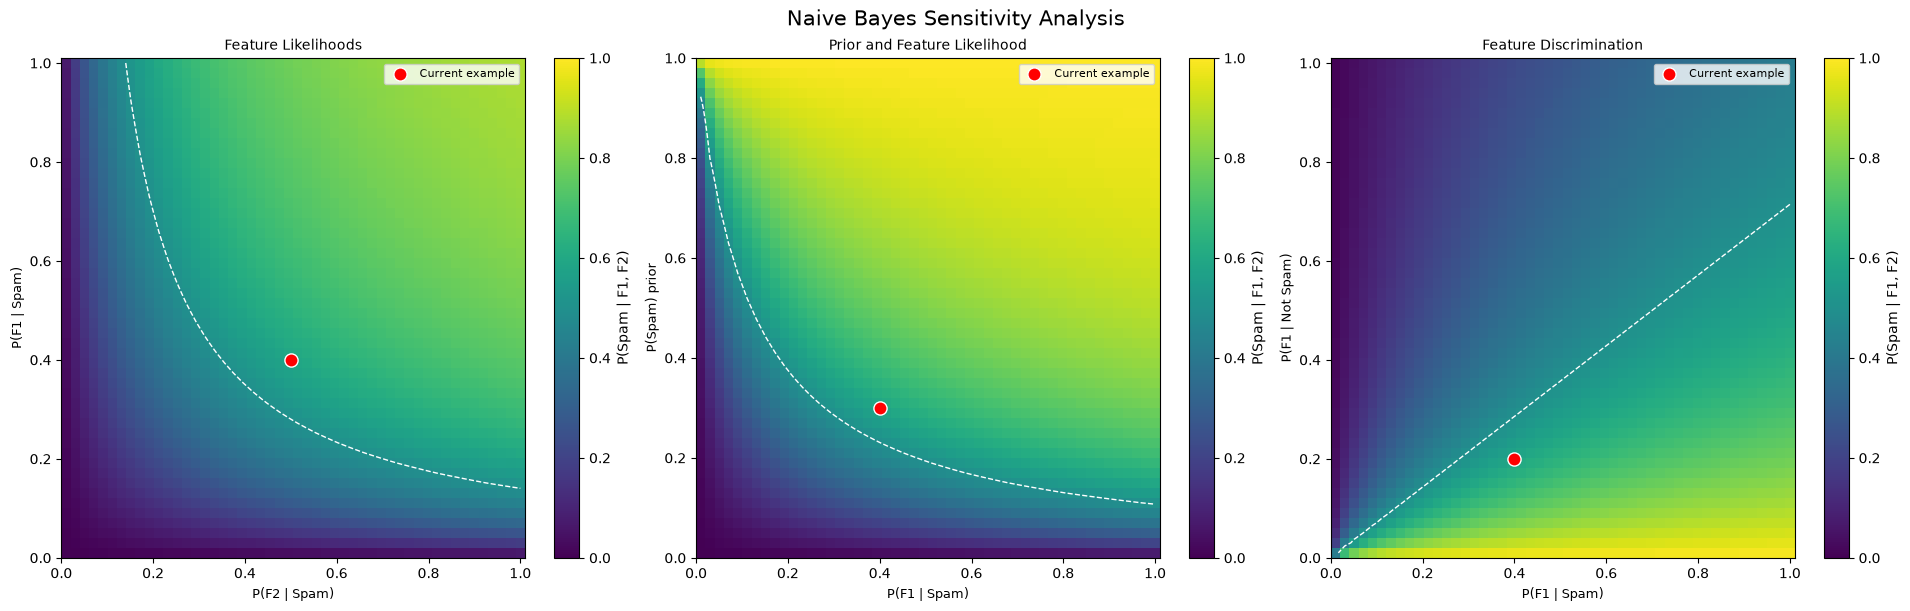

In [26]:
# Personal notebook addition (not in HTB): compare three Naive Bayes
# probability-gradient views horizontally.

import numpy as np
import matplotlib.pyplot as plt

axis_values = np.linspace(0.01, 1.0, 50)


def plot_gradient(
    ax,
    x_values,
    y_values,
    probability_grid,
    title,
    x_label,
    y_label,
    marker_x=None,
    marker_y=None
):
    image = ax.pcolormesh(
        x_values,
        y_values,
        probability_grid,
        shading="auto",
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    ax.contour(
        x_values,
        y_values,
        probability_grid,
        levels=[0.5],
        colors="white",
        linestyles="--",
        linewidths=1
    )

    if marker_x is not None and marker_y is not None:
        ax.scatter(
            marker_x,
            marker_y,
            color="red",
            edgecolor="white",
            s=90,
            label="Current example"
        )
        ax.legend(loc="upper right", fontsize=8)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)

    return image


# 1. Vary P(F1 | Spam) and P(F2 | Spam)
f1_spam_grid = axis_values[:, np.newaxis]
f2_spam_grid = axis_values[np.newaxis, :]

spam_joint_grid = f1_spam_grid * f2_spam_grid

posterior_grid = (
    spam_joint_grid * nb_prior_spam
) / (
    (spam_joint_grid * nb_prior_spam)
    + (nb_joint_not_spam * nb_prior_not_spam)
)


# 2. Vary spam prior and P(F1 | Spam)
spam_prior_axis = np.linspace(0.01, 0.99, 50)
f1_spam_axis = axis_values

spam_joint_prior_grid = (
    f1_spam_axis[np.newaxis, :] * nb_f2_given_spam
)

posterior_prior_grid = (
    spam_joint_prior_grid * spam_prior_axis[:, np.newaxis]
) / (
    (spam_joint_prior_grid * spam_prior_axis[:, np.newaxis])
    + (
        nb_joint_not_spam
        * (1 - spam_prior_axis[:, np.newaxis])
    )
)


# 3. Vary P(F1 | Spam) and P(F1 | Not Spam)
f1_spam_axis = axis_values
f1_not_spam_axis = axis_values

spam_joint_discrimination_grid = (
    f1_spam_axis[np.newaxis, :] * nb_f2_given_spam
)

not_spam_joint_discrimination_grid = (
    f1_not_spam_axis[:, np.newaxis]
    * nb_f2_given_not_spam
)

posterior_discrimination_grid = (
    spam_joint_discrimination_grid * nb_prior_spam
) / (
    (spam_joint_discrimination_grid * nb_prior_spam)
    + (
        not_spam_joint_discrimination_grid
        * nb_prior_not_spam
    )
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6),
    constrained_layout=True
)

image_1 = plot_gradient(
    axes[0],
    axis_values,
    axis_values,
    posterior_grid,
    "Feature Likelihoods",
    "P(F2 | Spam)",
    "P(F1 | Spam)",
    marker_x=nb_f2_given_spam,
    marker_y=nb_f1_given_spam
)

image_2 = plot_gradient(
    axes[1],
    f1_spam_axis,
    spam_prior_axis,
    posterior_prior_grid,
    "Prior and Feature Likelihood",
    "P(F1 | Spam)",
    "P(Spam) prior",
    marker_x=nb_f1_given_spam,
    marker_y=nb_prior_spam
)

image_3 = plot_gradient(
    axes[2],
    f1_spam_axis,
    f1_not_spam_axis,
    posterior_discrimination_grid,
    "Feature Discrimination",
    "P(F1 | Spam)",
    "P(F1 | Not Spam)",
    marker_x=nb_f1_given_spam,
    marker_y=nb_f1_given_not_spam
)

fig.colorbar(
    image_1,
    ax=axes[0],
    label="P(Spam | F1, F2)"
)

fig.colorbar(
    image_2,
    ax=axes[1],
    label="P(Spam | F1, F2)"
)

fig.colorbar(
    image_3,
    ax=axes[2],
    label="P(Spam | F1, F2)"
)

fig.suptitle(
    "Naive Bayes Sensitivity Analysis",
    fontsize=15
)

plt.show()

## From a toy posterior to an end-to-end text classifier

The probability-gradient and bar-chart views turn the worked posterior into an interpretable surface: changing priors or feature likelihoods changes the decision boundary. These visuals are explanatory rather than a substitute for held-out evaluation, but they make conditional independence, evidence, and posterior confidence concrete.

The remaining case studies apply the same lifecycle to larger and more realistic security problems. We next move from structured event records to the SMS Spam Collection, where the central representation problem is converting short, noisy language into sparse numeric evidence.


# SMS spam detection: turn language into evidence

The SMS Spam Collection contains 5,574 labeled messages divided into `ham` and `spam`. It is a useful security classification problem because the observations are short, the classes are not equally represented, duplicates and artifacts can matter, and the features must be learned from text rather than supplied as structured columns.

The workflow will be deliberately layered. We first download and extract the corpus idempotently, inspect balance and message structure, then preserve a raw copy while applying a transparent normalization pipeline. Count-based unigram and bigram features feed a tuned Multinomial Naive Bayes model; evaluation then separates cross-validation used for selection from the untouched holdout used for reporting. Finally, inference, persistence, and model-aware diagnostics turn a notebook experiment into a reusable artifact.


In [27]:
# HTB lesson workflow adapted for repeatable notebook runs: download and
# extract the SMS Spam Collection.
# Personal modifications: reuse valid data or archives, stream to a partial
# file, and validate extraction.

from pathlib import Path
import requests
import zipfile

DATASET_URL = (
    "https://archive.ics.uci.edu/static/public/228/"
    "sms+spam+collection.zip"
)

ARCHIVE_PATH = Path("sms+spam+collection.zip")
EXTRACT_DIR = Path("sms_spam_collection")
PARTIAL_PATH = Path("sms+spam+collection.zip.part")


def find_dataset_file():
    if not EXTRACT_DIR.exists():
        return None

    matches = [
        path
        for path in EXTRACT_DIR.rglob("SMSSpamCollection")
        if path.is_file()
    ]

    return matches[0] if matches else None


# Reuse an already extracted dataset.
DATASET_PATH = find_dataset_file()

if DATASET_PATH is not None and DATASET_PATH.stat().st_size > 0:
    print(f"Dataset already extracted: {DATASET_PATH}")
    print("Skipping download and extraction.")

else:
    # Reuse a valid local archive; otherwise download it.
    if ARCHIVE_PATH.exists() and zipfile.is_zipfile(ARCHIVE_PATH):
        print(f"Archive already available: {ARCHIVE_PATH}")
        print("Skipping download.")

    else:
        print("Downloading dataset archive...")

        try:
            with requests.get(
                DATASET_URL,
                stream=True,
                timeout=60
            ) as response:
                response.raise_for_status()

                with PARTIAL_PATH.open("wb") as output_file:
                    for chunk in response.iter_content(
                        chunk_size=1024 * 1024
                    ):
                        if chunk:
                            output_file.write(chunk)

            PARTIAL_PATH.replace(ARCHIVE_PATH)
            print("Download successful.")

        except Exception:
            if PARTIAL_PATH.exists():
                PARTIAL_PATH.unlink()
            raise

    # Extract only if the dataset file is not already present.
    print("Extracting dataset archive...")
    EXTRACT_DIR.mkdir(exist_ok=True)

    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        archive.extractall(EXTRACT_DIR)

    DATASET_PATH = find_dataset_file()

    if DATASET_PATH is None:
        raise FileNotFoundError(
            "Extraction completed, but SMSSpamCollection was not found."
        )

    print(f"Extraction successful: {DATASET_PATH}")

Dataset already extracted: sms_spam_collection/SMSSpamCollection
Skipping download and extraction.


In [28]:
# HTB lesson loading step adapted to use DATASET_PATH from the idempotent
# download cell.

import pandas as pd

df = pd.read_csv(
    DATASET_PATH,
    sep="\t",
    header=None,
    names=["label", "message"],
)

## Ingest the corpus before interpreting it

The loader checks for the archive and extracted file before downloading or unpacking anything. That small control makes the notebook safe to rerun and keeps data acquisition separate from analysis. Once loaded, the tab-separated file is normalized into a label/message frame so that later cells operate on an explicit schema rather than on positional assumptions.

Before changing the text, we will inspect class balance, message lengths, missingness, duplicates, common tokens, and relationships among simple message-level features. Those checks establish what kinds of preprocessing and evaluation risks the corpus presents.


In [29]:
# Personal notebook EDA (not in HTB): expand HTB's duplicate-check concept
# into engineered features and analysis tables.

import re
import numpy as np
import pandas as pd

from collections import Counter
from IPython.display import display


# Work on a separate analysis copy.
sms = df.loc[:, ["label", "message"]].copy()

sms["label"] = (
    sms["label"]
    .astype("string")
    .str.strip()
    .str.lower()
)

sms["message"] = (
    sms["message"]
    .fillna("")
    .astype("string")
)

rows_before_deduplication = len(sms)

sms = (
    sms
    .drop_duplicates(subset=["label", "message"])
    .reset_index(drop=True)
)

rows_after_deduplication = len(sms)
duplicates_removed = (
    rows_before_deduplication - rows_after_deduplication
)


# Normalize labels and define the target.
sms["is_spam"] = sms["label"].eq("spam")
sms["is_spam_numeric"] = sms["is_spam"].astype(int)

sms["message_lower"] = sms["message"].str.lower()

sms["tokens"] = sms["message_lower"].str.findall(
    r"[a-z0-9']+"
)


# Text and structural features.
sms["char_count"] = sms["message"].str.len()

sms["word_count"] = sms["tokens"].str.len()

sms["unique_word_count"] = sms["tokens"].map(
    lambda tokens: len(set(tokens))
)

sms["sentence_count"] = (
    sms["message"]
    .str.count(r"[.!?]")
    .add(1)
)

sms["digit_count"] = sms["message"].str.count(r"\d")

sms["uppercase_count"] = sms["message"].str.count(r"[A-Z]")

sms["punctuation_count"] = sms["message"].str.count(
    r"[^\w\s]"
)

sms["exclamation_count"] = sms["message"].str.count("!")

sms["question_count"] = sms["message"].str.count(r"\?")

sms["currency_count"] = sms["message"].str.count(
    r"[$£€₹]"
)

sms["url_count"] = (
    sms["message_lower"]
    .str.count(r"(?:https?://|www\.|bit\.ly|tinyurl)")
)

sms["has_url"] = (
    sms["message_lower"]
    .str.contains(
        r"(?:https?://|www\.|bit\.ly|tinyurl|\.com\b)",
        regex=True,
        na=False
    )
)

sms["has_email"] = (
    sms["message_lower"]
    .str.contains(
        r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b",
        regex=True,
        na=False
    )
)

sms["has_phone_number"] = (
    sms["message"]
    .str.contains(
        r"\b(?:\+?\d[\d\s().-]{6,}\d)\b",
        regex=True,
        na=False
    )
)

sms["char_per_word"] = (
    sms["char_count"] /
    sms["word_count"].replace(0, np.nan)
).fillna(0)

sms["uppercase_ratio"] = (
    sms["uppercase_count"] /
    sms["char_count"].replace(0, np.nan)
).fillna(0)

sms["digit_ratio"] = (
    sms["digit_count"] /
    sms["char_count"].replace(0, np.nan)
).fillna(0)

sms["unique_word_ratio"] = (
    sms["unique_word_count"] /
    sms["word_count"].replace(0, np.nan)
).fillna(0)


# Small stopword list for more meaningful token analysis.
STOPWORDS = {
    "a", "about", "after", "again", "all", "also", "am",
    "an", "and", "any", "are", "as", "at", "be", "been",
    "before", "but", "by", "can", "could", "did", "do",
    "does", "for", "from", "get", "got", "had", "has",
    "have", "he", "her", "here", "him", "his", "how", "i",
    "if", "in", "into", "is", "it", "its", "just", " me",
    "more", "most", "my", "no", "not", "now", "of", "on",
    "one", "or", "our", "out", "she", "so", "some", "than",
    "that", "the", "their", "there", "they", "this", "to",
    "up", "us", "was", "we", "were", "what", "when", "which",
    "who", "will", "with", "would", "you", "your"
}


def filtered_tokens(tokens):
    return [
        token
        for token in tokens
        if len(token) > 1 and token not in STOPWORDS
    ]


def token_counter(frame):
    counter = Counter()

    for tokens in frame["tokens"]:
        counter.update(filtered_tokens(tokens))

    return counter


def bigram_counter(frame):
    counter = Counter()

    for tokens in frame["tokens"]:
        cleaned_tokens = filtered_tokens(tokens)

        bigrams = zip(
            cleaned_tokens,
            cleaned_tokens[1:]
        )

        counter.update(
            " ".join(pair)
            for pair in bigrams
        )

    return counter


ham_messages = sms[sms["label"] == "ham"]
spam_messages = sms[sms["label"] == "spam"]

ham_token_counts = token_counter(ham_messages)
spam_token_counts = token_counter(spam_messages)

ham_bigram_counts = bigram_counter(ham_messages)
spam_bigram_counts = bigram_counter(spam_messages)


top_tokens_ham = pd.DataFrame(
    ham_token_counts.most_common(15),
    columns=["term", "count"]
)

top_tokens_spam = pd.DataFrame(
    spam_token_counts.most_common(15),
    columns=["term", "count"]
)

top_bigrams_ham = pd.DataFrame(
    ham_bigram_counts.most_common(15),
    columns=["term", "count"]
)

top_bigrams_spam = pd.DataFrame(
    spam_bigram_counts.most_common(15),
    columns=["term", "count"]
)


# Smoothed token log-odds.
token_vocabulary = sorted(
    set(ham_token_counts) |
    set(spam_token_counts)
)

ham_total_tokens = sum(ham_token_counts.values())
spam_total_tokens = sum(spam_token_counts.values())
vocabulary_size = len(token_vocabulary)

token_log_odds = pd.DataFrame({
    "token": token_vocabulary,
    "ham_count": [
        ham_token_counts[token]
        for token in token_vocabulary
    ],
    "spam_count": [
        spam_token_counts[token]
        for token in token_vocabulary
    ]
})

token_log_odds["ham_probability"] = (
    token_log_odds["ham_count"] + 1
) / (
    ham_total_tokens + vocabulary_size
)

token_log_odds["spam_probability"] = (
    token_log_odds["spam_count"] + 1
) / (
    spam_total_tokens + vocabulary_size
)

token_log_odds["log_odds"] = np.log(
    token_log_odds["spam_probability"] /
    token_log_odds["ham_probability"]
)

top_discriminative_tokens = pd.concat([
    token_log_odds.nlargest(8, "log_odds"),
    token_log_odds.nsmallest(8, "log_odds")
]).drop_duplicates(
    subset=["token"]
).sort_values("log_odds")


# Smoothed bigram log-odds.
bigram_vocabulary = sorted(
    set(ham_bigram_counts) |
    set(spam_bigram_counts)
)

ham_total_bigrams = sum(ham_bigram_counts.values())
spam_total_bigrams = sum(spam_bigram_counts.values())
bigram_vocabulary_size = len(bigram_vocabulary)

bigram_log_odds = pd.DataFrame({
    "term": bigram_vocabulary,
    "ham_count": [
        ham_bigram_counts[term]
        for term in bigram_vocabulary
    ],
    "spam_count": [
        spam_bigram_counts[term]
        for term in bigram_vocabulary
    ]
})

bigram_log_odds["ham_probability"] = (
    bigram_log_odds["ham_count"] + 1
) / (
    ham_total_bigrams + bigram_vocabulary_size
)

bigram_log_odds["spam_probability"] = (
    bigram_log_odds["spam_count"] + 1
) / (
    spam_total_bigrams + bigram_vocabulary_size
)

bigram_log_odds["log_odds"] = np.log(
    bigram_log_odds["spam_probability"] /
    bigram_log_odds["ham_probability"]
)

top_discriminative_bigrams = pd.concat([
    bigram_log_odds.nlargest(8, "log_odds"),
    bigram_log_odds.nsmallest(8, "log_odds")
]).drop_duplicates(
    subset=["term"]
).sort_values("log_odds")


# Core summary tables.
class_counts = (
    sms["label"]
    .value_counts()
    .reindex(["ham", "spam"])
    .fillna(0)
    .astype(int)
)

class_percentages = (
    class_counts / len(sms) * 100
).round(2)

summary_statistics = sms.groupby("label")[
    [
        "char_count",
        "word_count",
        "unique_word_count",
        "digit_count",
        "uppercase_ratio",
        "punctuation_count",
        "exclamation_count",
        "question_count",
        "url_count"
    ]
].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
]).round(3)

length_quantiles = sms.groupby("label")[
    ["char_count", "word_count"]
].quantile([
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]).unstack().round(2)


# Binary-feature prevalence by class.
feature_columns = [
    "has_url",
    "has_email",
    "has_phone_number",
    "currency_count",
    "url_count"
]

feature_labels = {
    "has_url": "Contains URL",
    "has_email": "Contains email",
    "has_phone_number": "Contains phone",
    "currency_count": "Contains currency",
    "url_count": "URL count"
}

feature_rate = (
    sms.groupby("label")[feature_columns]
    .mean()
    .T
    .rename(columns={"ham": "Ham", "spam": "Spam"})
    * 100
)

feature_rate.index = [
    feature_labels[column]
    for column in feature_rate.index
]

punctuation_means = (
    sms.groupby("label")[
        [
            "exclamation_count",
            "question_count",
            "punctuation_count"
        ]
    ]
    .mean()
    .T
    .rename(columns={"ham": "Ham", "spam": "Spam"})
    .round(3)
)


# Correlation matrix for numeric exploratory features.
correlation_columns = [
    "char_count",
    "word_count",
    "unique_word_count",
    "digit_count",
    "uppercase_ratio",
    "digit_ratio",
    "punctuation_count",
    "exclamation_count",
    "question_count",
    "is_spam_numeric"
]

correlation_matrix = sms[
    correlation_columns
].astype(float).corr().round(2)


# Console report.
print("=" * 70)
print("SMS SPAM DATASET ANALYSIS")
print("=" * 70)

print(f"Rows before duplicate removal: {rows_before_deduplication:,}")
print(f"Rows after duplicate removal:  {rows_after_deduplication:,}")
print(f"Duplicate rows removed:        {duplicates_removed:,}")
print(f"Columns in analysis frame:     {sms.shape[1]}")

print("\nClass counts:")
display(class_counts.to_frame("Count"))

print("\nClass percentages:")
display(class_percentages.to_frame("Percent"))

print("\nMissing values:")
display(sms[["label", "message"]].isna().sum().to_frame("Missing"))

print("\nGrouped descriptive statistics:")
display(summary_statistics)

print("\nMessage-length quantiles:")
display(length_quantiles)

print("\nFeature prevalence by class:")
display(feature_rate.round(2))

print("\nAverage punctuation-related features:")
display(punctuation_means)

print("\nMost common ham tokens:")
display(top_tokens_ham)

print("\nMost common spam tokens:")
display(top_tokens_spam)

print("\nMost common ham bigrams:")
display(top_bigrams_ham)

print("\nMost common spam bigrams:")
display(top_bigrams_spam)

print("\nMost spam-associated tokens:")
display(
    top_discriminative_tokens
    .query("log_odds > 0")
    .sort_values("log_odds", ascending=False)
)

print("\nMost ham-associated tokens:")
display(
    top_discriminative_tokens
    .query("log_odds < 0")
    .sort_values("log_odds")
)

print("\nCorrelation matrix:")
display(correlation_matrix)

SMS SPAM DATASET ANALYSIS
Rows before duplicate removal: 5,572
Rows after duplicate removal:  5,169
Duplicate rows removed:        403
Columns in analysis frame:     24

Class counts:


,Count
label,
ham,4516
spam,653



Class percentages:


,Percent
label,
ham,87.37
spam,12.63



Missing values:


...

,token,ham_count,spam_count,ham_probability,spam_probability,log_odds
2101,claim,0,96,0.000022,0.004841,5.403399
6174,prize,0,82,0.000022,0.004142,5.247529
383,150p,0,64,0.000022,0.003244,5.003076
8609,won,0,59,0.000022,0.002994,4.923033
7914,tone,0,45,0.000022,0.002296,4.657330
400,18,0,43,0.000022,0.002196,4.612878
3734,guaranteed,0,42,0.000022,0.002146,4.589889
8683,www,1,83,0.000044,0.004192,4.566358



Most ham-associated tokens:


,token,ham_count,spam_count,ham_probability,spam_probability,log_odds
3730,gt,288,0,0.006298,0.00005,-4.837738
4850,lt,287,0,0.006276,0.00005,-4.834272
4804,lor,159,0,0.003487,0.00005,-4.246485
2462,da,142,0,0.003116,0.00005,-4.134156
4085,i'll,137,0,0.003007,0.00005,-4.098565
4606,later,100,0,0.002201,0.00005,-3.786432
1275,ask,88,0,0.001939,0.00005,-3.659948
2753,doing,82,0,0.001809,0.00005,-3.590152



Correlation matrix:


,char_count,word_count,unique_word_count,digit_count,uppercase_ratio,digit_ratio,punctuation_count,exclamation_count,question_count,is_spam_numeric
char_count,1.00,0.98,0.97,0.38,0.06,0.27,0.63,0.25,0.10,0.38
word_count,0.98,1.00,0.98,0.32,0.05,0.22,0.59,0.23,0.10,0.32
unique_word_count,0.97,0.98,1.00,0.38,0.07,0.27,0.56,0.25,0.09,0.38
digit_count,0.38,0.32,0.38,1.00,0.16,0.88,0.20,0.26,-0.04,0.84
uppercase_ratio,0.06,0.05,0.07,0.16,1.00,0.15,0.03,0.19,0.01,0.16
digit_ratio,0.27,0.22,0.27,0.88,0.15,1.00,0.13,0.21,-0.04,0.76
punctuation_count,0.63,0.59,0.56,0.20,0.03,0.13,1.00,0.25,0.12,0.16
exclamation_count,0.25,0.23,0.25,0.26,0.19,0.21,0.25,1.00,0.03,0.25
question_count,0.10,0.10,0.09,-0.04,0.01,-0.04,0.12,0.03,1.00,-0.03
is_spam_numeric,0.38,0.32,0.38,0.84,0.16,0.76,0.16,0.25,-0.03,1.00


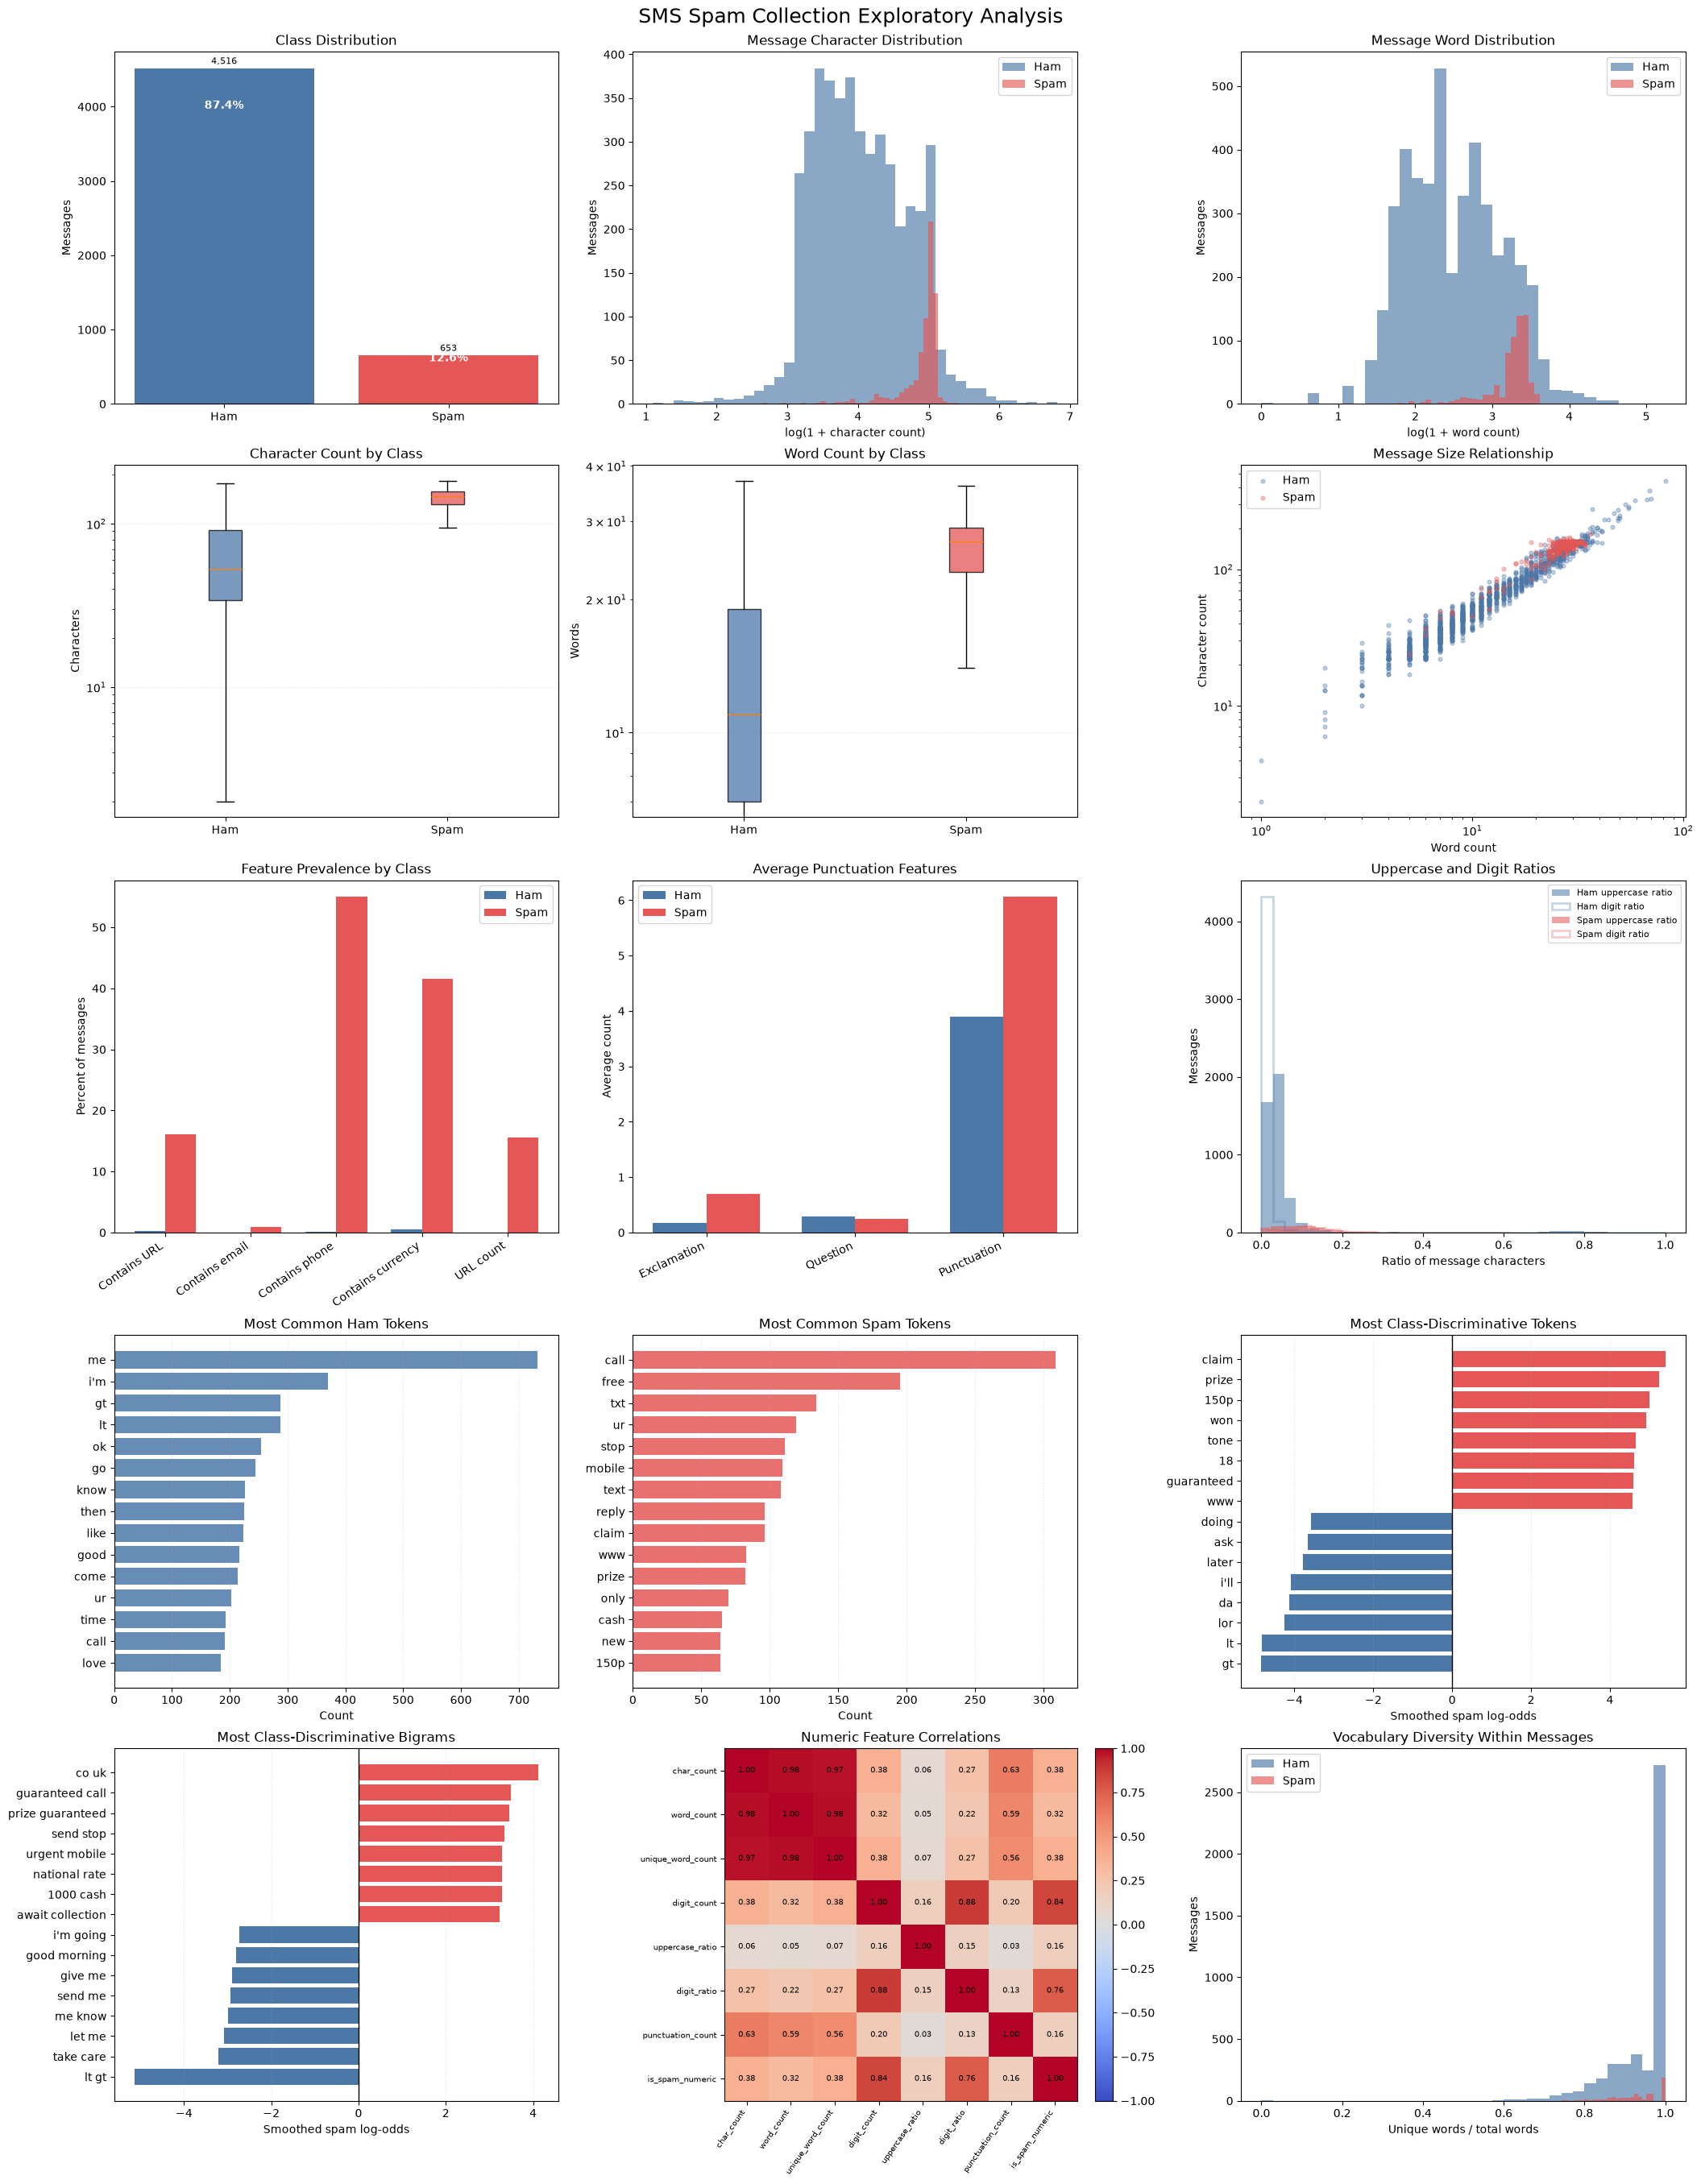

In [30]:
# Personal notebook addition (not in HTB): create a compact 5-row by 3-column
# EDA dashboard.

import numpy as np
import matplotlib.pyplot as plt


COLORS = {
    "ham": "#4c78a8",
    "spam": "#e45756"
}


def annotate_bars(ax, bars, decimals=0):
    for bar in bars:
        value = bar.get_height()

        if decimals == 0:
            label = f"{value:,.0f}"
        else:
            label = f"{value:.{decimals}f}"

        ax.annotate(
            label,
            xy=(
                bar.get_x() + bar.get_width() / 2,
                value
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )


def add_boxplot(
    ax,
    values,
    labels,
    colors,
    title,
    ylabel
):
    boxplot = ax.boxplot(
        values,
        tick_labels=labels,
        patch_artist=True,
        showfliers=False
    )

    for patch, color in zip(
        boxplot["boxes"],
        colors
    ):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.35
    )

def plot_ecdf(ax, values, label, color):
    sorted_values = np.sort(values)
    y_values = np.arange(
        1,
        len(sorted_values) + 1
    ) / len(sorted_values)

    ax.plot(
        sorted_values,
        y_values,
        label=label,
        color=color,
        linewidth=2
    )


def plot_term_bars(
    ax,
    frame,
    title,
    color,
    value_column="count"
):
    ordered = frame.sort_values(value_column)

    ax.barh(
        ordered["term"],
        ordered[value_column],
        color=color,
        alpha=0.85
    )

    ax.set_title(title)
    ax.set_xlabel(value_column.replace("_", " ").title())
    ax.grid(
        axis="x",
        linestyle=":",
        alpha=0.35
    )


fig, axes = plt.subplots(
    5,
    3,
    figsize=(21, 27),
    constrained_layout=True
)

axes = axes.ravel()


# ---------------------------------------------------------------------
# 1. Class distribution
# ---------------------------------------------------------------------
class_labels = ["Ham", "Spam"]
class_values = [
    class_counts["ham"],
    class_counts["spam"]
]

bars = axes[0].bar(
    class_labels,
    class_values,
    color=[
        COLORS["ham"],
        COLORS["spam"]
    ]
)

axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Messages")
annotate_bars(axes[0], bars)

for index, value in enumerate(class_values):
    axes[0].text(
        index,
        value * 0.88,
        f"{value / len(sms) * 100:.1f}%",
        ha="center",
        color="white",
        fontweight="bold"
    )


# ---------------------------------------------------------------------
# 2. Character-count distribution
# ---------------------------------------------------------------------
for label in ["ham", "spam"]:
    values = sms.loc[
        sms["label"] == label,
        "char_count"
    ]

    axes[1].hist(
        np.log1p(values),
        bins=40,
        alpha=0.65,
        color=COLORS[label],
        label=label.title()
    )

axes[1].set_title("Message Character Distribution")
axes[1].set_xlabel("log(1 + character count)")
axes[1].set_ylabel("Messages")
axes[1].legend()


# ---------------------------------------------------------------------
# 3. Word-count distribution
# ---------------------------------------------------------------------
for label in ["ham", "spam"]:
    values = sms.loc[
        sms["label"] == label,
        "word_count"
    ]

    axes[2].hist(
        np.log1p(values),
        bins=35,
        alpha=0.65,
        color=COLORS[label],
        label=label.title()
    )

axes[2].set_title("Message Word Distribution")
axes[2].set_xlabel("log(1 + word count)")
axes[2].set_ylabel("Messages")
axes[2].legend()


# ---------------------------------------------------------------------
# 4. Character-count boxplot
# ---------------------------------------------------------------------
add_boxplot(
    axes[3],
    [
        sms.loc[sms["label"] == "ham", "char_count"],
        sms.loc[sms["label"] == "spam", "char_count"]
    ],
    ["Ham", "Spam"],
    [COLORS["ham"], COLORS["spam"]],
    "Character Count by Class",
    "Characters"
)

axes[3].set_yscale("log")


# ---------------------------------------------------------------------
# 5. Word-count boxplot
# ---------------------------------------------------------------------
add_boxplot(
    axes[4],
    [
        sms.loc[sms["label"] == "ham", "word_count"],
        sms.loc[sms["label"] == "spam", "word_count"]
    ],
    ["Ham", "Spam"],
    [COLORS["ham"], COLORS["spam"]],
    "Word Count by Class",
    "Words"
)

axes[4].set_yscale("log")


# ---------------------------------------------------------------------
# 6. Character count versus word count
# ---------------------------------------------------------------------
scatter_sample = sms.sample(
    min(1800, len(sms)),
    random_state=42
)

for label in ["ham", "spam"]:
    subset = scatter_sample[
        scatter_sample["label"] == label
    ]

    axes[5].scatter(
        subset["word_count"],
        subset["char_count"],
        s=12,
        alpha=0.35,
        color=COLORS[label],
        label=label.title()
    )

axes[5].set_xscale("log")
axes[5].set_yscale("log")
axes[5].set_title("Message Size Relationship")
axes[5].set_xlabel("Word count")
axes[5].set_ylabel("Character count")
axes[5].legend()


# ---------------------------------------------------------------------
# 7. Binary and structural feature prevalence
# ---------------------------------------------------------------------
feature_x = np.arange(len(feature_rate.index))
feature_width = 0.36

axes[6].bar(
    feature_x - feature_width / 2,
    feature_rate["Ham"],
    feature_width,
    label="Ham",
    color=COLORS["ham"]
)

axes[6].bar(
    feature_x + feature_width / 2,
    feature_rate["Spam"],
    feature_width,
    label="Spam",
    color=COLORS["spam"]
)

axes[6].set_xticks(feature_x)
axes[6].set_xticklabels(
    feature_rate.index,
    rotation=35,
    ha="right"
)

axes[6].set_ylabel("Percent of messages")
axes[6].set_title("Feature Prevalence by Class")
axes[6].legend()


# ---------------------------------------------------------------------
# 8. Average punctuation counts
# ---------------------------------------------------------------------
punctuation_x = np.arange(
    len(punctuation_means.index)
)

axes[7].bar(
    punctuation_x - feature_width / 2,
    punctuation_means["Ham"],
    feature_width,
    label="Ham",
    color=COLORS["ham"]
)

axes[7].bar(
    punctuation_x + feature_width / 2,
    punctuation_means["Spam"],
    feature_width,
    label="Spam",
    color=COLORS["spam"]
)

axes[7].set_xticks(punctuation_x)
axes[7].set_xticklabels(
    [
        "Exclamation",
        "Question",
        "Punctuation"
    ],
    rotation=25,
    ha="right"
)

axes[7].set_ylabel("Average count")
axes[7].set_title("Average Punctuation Features")
axes[7].legend()


# ---------------------------------------------------------------------
# 9. Uppercase and digit ratios
# ---------------------------------------------------------------------
for label in ["ham", "spam"]:
    subset = sms[sms["label"] == label]

    axes[8].hist(
        subset["uppercase_ratio"],
        bins=35,
        alpha=0.55,
        color=COLORS[label],
        label=f"{label.title()} uppercase ratio"
    )

    axes[8].hist(
        subset["digit_ratio"],
        bins=35,
        alpha=0.30,
        color=COLORS[label],
        histtype="step",
        linewidth=2,
        label=f"{label.title()} digit ratio"
    )

axes[8].set_title("Uppercase and Digit Ratios")
axes[8].set_xlabel("Ratio of message characters")
axes[8].set_ylabel("Messages")
axes[8].legend(fontsize=8)


# ---------------------------------------------------------------------
# 10. Most common ham tokens
# ---------------------------------------------------------------------
plot_term_bars(
    axes[9],
    top_tokens_ham,
    "Most Common Ham Tokens",
    COLORS["ham"]
)


# ---------------------------------------------------------------------
# 11. Most common spam tokens
# ---------------------------------------------------------------------
plot_term_bars(
    axes[10],
    top_tokens_spam,
    "Most Common Spam Tokens",
    COLORS["spam"]
)


# ---------------------------------------------------------------------
# 12. Token log-odds
# ---------------------------------------------------------------------
token_plot = top_discriminative_tokens.sort_values(
    "log_odds"
)

token_colors = [
    COLORS["spam"] if value > 0 else COLORS["ham"]
    for value in token_plot["log_odds"]
]

axes[11].barh(
    token_plot["token"],
    token_plot["log_odds"],
    color=token_colors
)

axes[11].axvline(
    0,
    color="black",
    linewidth=1
)

axes[11].set_title("Most Class-Discriminative Tokens")
axes[11].set_xlabel("Smoothed spam log-odds")
axes[11].grid(
    axis="x",
    linestyle=":",
    alpha=0.35
)


# ---------------------------------------------------------------------
# 13. Bigram log-odds
# ---------------------------------------------------------------------
bigram_plot = top_discriminative_bigrams.sort_values(
    "log_odds"
)

bigram_colors = [
    COLORS["spam"] if value > 0 else COLORS["ham"]
    for value in bigram_plot["log_odds"]
]

axes[12].barh(
    bigram_plot["term"],
    bigram_plot["log_odds"],
    color=bigram_colors
)

axes[12].axvline(
    0,
    color="black",
    linewidth=1
)

axes[12].set_title("Most Class-Discriminative Bigrams")
axes[12].set_xlabel("Smoothed spam log-odds")
axes[12].grid(
    axis="x",
    linestyle=":",
    alpha=0.35
)


# ---------------------------------------------------------------------
# 14. Correlation matrix
# ---------------------------------------------------------------------
corr_columns_for_plot = [
    "char_count",
    "word_count",
    "unique_word_count",
    "digit_count",
    "uppercase_ratio",
    "digit_ratio",
    "punctuation_count",
    "is_spam_numeric"
]

corr = correlation_matrix.loc[
    corr_columns_for_plot,
    corr_columns_for_plot
]

image = axes[13].imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

axes[13].set_title("Numeric Feature Correlations")
axes[13].set_xticks(
    np.arange(len(corr.columns))
)
axes[13].set_yticks(
    np.arange(len(corr.columns))
)

axes[13].set_xticklabels(
    corr.columns,
    rotation=55,
    ha="right",
    fontsize=7
)

axes[13].set_yticklabels(
    corr.columns,
    fontsize=7
)

for row in range(len(corr.index)):
    for column in range(len(corr.columns)):
        axes[13].text(
            column,
            row,
            f"{corr.iloc[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

fig.colorbar(
    image,
    ax=axes[13],
    fraction=0.046,
    pad=0.04
)


# ---------------------------------------------------------------------
# 15. Unique-word ratio distribution
# ---------------------------------------------------------------------
for label in ["ham", "spam"]:
    values = sms.loc[
        sms["label"] == label,
        "unique_word_ratio"
    ]

    axes[14].hist(
        values,
        bins=35,
        alpha=0.65,
        color=COLORS[label],
        label=label.title()
    )

axes[14].set_title("Vocabulary Diversity Within Messages")
axes[14].set_xlabel("Unique words / total words")
axes[14].set_ylabel("Messages")
axes[14].legend()


fig.suptitle(
    "SMS Spam Collection Exploratory Analysis",
    fontsize=18
)

plt.show()

## EDA establishes the modeling priorities

The exploratory dashboard shows the shape of the problem: ham is the majority class, spam messages have different length and token patterns, and a small set of terms or n-grams can carry disproportionate class information. Duplicate and near-duplicate messages deserve attention because they can make a random split look more independent than the underlying corpus really is.

The notebook also adds feature prevalence, log-odds, correlation, distribution, and model-aware views. Together these do more than rank frequent words: they connect the corpus’ generative structure to the eventual classifier and provide hypotheses that preprocessing should preserve rather than erase. The next step is a controlled text-normalization pipeline with an audit of what changed.


In [31]:
# HTB lesson prerequisite adapted for repeatable runs: ensure punkt,
# punkt_tab, and stopwords are available.
# Personal modification: download only missing resources and stop if an
# acquisition fails.

import nltk

required_nltk_resources = {
    "punkt": "tokenizers/punkt",
    "punkt_tab": "tokenizers/punkt_tab",
    "stopwords": "corpora/stopwords"
}

for package_name, resource_path in required_nltk_resources.items():
    try:
        nltk.data.find(resource_path)
        print(f"{package_name}: already available")
    except LookupError:
        print(f"{package_name}: downloading")
        downloaded = nltk.download(package_name)

        if not downloaded:
            raise RuntimeError(
                f"Unable to download required NLTK resource: {package_name}"
            )

punkt: already available
punkt_tab: already available
stopwords: already available


In [32]:
# HTB lesson preprocessing workflow adapted to retain raw records and every
# intermediate representation.
# Personal modifications: use a deduplicated analysis copy, descriptive
# columns, and preserve raw inputs; step comments identify HTB operations.

import re
import pandas as pd

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


spam_preprocessed = (
    df.loc[:, ["label", "message"]]
    .rename(columns={"message": "message_raw"})
    .drop_duplicates(
        subset=["label", "message_raw"]
    )
    .reset_index(drop=True)
)

spam_preprocessed["label"] = (
    spam_preprocessed["label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

spam_preprocessed["message_raw"] = (
    spam_preprocessed["message_raw"]
    .fillna("")
    .astype(str)
)

# HTB: lowercase the message text.
spam_preprocessed["message_lower"] = (
    spam_preprocessed["message_raw"]
    .str.lower()
)

# HTB: remove punctuation and numbers while preserving $ and !.
spam_preprocessed["message_clean"] = (
    spam_preprocessed["message_lower"]
    .apply(
        lambda text: re.sub(
            r"[^a-z\s$!]",
            "",
            text
        )
    )
)

# HTB: tokenize the cleaned text.
spam_preprocessed["tokens"] = (
    spam_preprocessed["message_clean"]
    .apply(word_tokenize)
)

# HTB: remove English stop words.
spam_stop_words = set(
    stopwords.words("english")
)

spam_preprocessed["tokens_without_stopwords"] = (
    spam_preprocessed["tokens"]
    .apply(
        lambda tokens: [
            token
            for token in tokens
            if token not in spam_stop_words
        ]
    )
)

# HTB: stem the remaining tokens.
spam_stemmer = PorterStemmer()

spam_preprocessed["tokens_stemmed"] = (
    spam_preprocessed["tokens_without_stopwords"]
    .apply(
        lambda tokens: [
            spam_stemmer.stem(token)
            for token in tokens
        ]
    )
)

# HTB: join the tokens back into strings.
spam_preprocessed["message_preprocessed"] = (
    spam_preprocessed["tokens_stemmed"]
    .apply(" ".join)
)

spam_preprocessed["is_spam_numeric"] = (
    spam_preprocessed["label"]
    .eq("spam")
    .astype(int)
)

spam_preprocessed["preprocessed_word_count"] = (
    spam_preprocessed["tokens_stemmed"]
    .str.len()
)

display(
    spam_preprocessed[
        [
            "label",
            "message_raw",
            "message_preprocessed"
        ]
    ].head(10)
)

,label,message_raw,message_preprocessed
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back ! id like fun ...
6,ham,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,spam,WINNER!! As a valued network customer you have...,winner ! ! valu network custom select receivea...
9,spam,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


## Normalize text without losing an audit trail

The preprocessing path lowercases text, tokenizes it, removes punctuation and numeric noise while preserving security-relevant symbols such as `$` and `!`, removes stop words, applies Porter stemming, and joins the tokens back into a model-ready string. The raw message remains intact in a separate column, so every transformed example can be traced back to its source representation.

That raw-versus-processed comparison is an engineering safeguard as much as a linguistic choice. It lets us measure how much text was removed, investigate unexpected model behavior, and compare models trained on original versus normalized strings. With the transformation audited, the next cells convert the processed corpus into sparse features.


In [33]:
# Personal notebook addition (not in HTB): audit the effect of HTB
# preprocessing by comparing raw and processed representations.

raw_token_lists = (
    spam_preprocessed["message_raw"]
    .str.findall(r"[A-Za-z0-9']+")
)

raw_vocabulary = {
    token
    for token_list in raw_token_lists
    for token in token_list
}

preprocessed_vocabulary = {
    token
    for token_list in spam_preprocessed["tokens_stemmed"]
    for token in token_list
}

preprocessing_audit = pd.DataFrame({
    "Raw dataset": [
        len(spam_preprocessed),
        spam_preprocessed["message_raw"].str.len().mean(),
        raw_token_lists.str.len().mean(),
        len(raw_vocabulary),
        spam_preprocessed["message_raw"].eq("").sum()
    ],
    "HTB-preprocessed": [
        len(spam_preprocessed),
        spam_preprocessed["message_preprocessed"].str.len().mean(),
        spam_preprocessed["preprocessed_word_count"].mean(),
        len(preprocessed_vocabulary),
        spam_preprocessed["message_preprocessed"].eq("").sum()
    ]
}, index=[
    "Rows",
    "Average characters",
    "Average tokens",
    "Vocabulary size",
    "Empty messages"
]).round(2)

display(preprocessing_audit)

display(
    spam_preprocessed[
        [
            "label",
            "message_raw",
            "message_lower",
            "message_clean",
            "message_preprocessed"
        ]
    ].head(10)
)

,Raw dataset,HTB-preprocessed
Rows,5169.00,5169.00
Average characters,79.34,47.03
Average tokens,15.70,9.08
Vocabulary size,11115.00,7121.00
Empty messages,0.00,6.00


,label,message_raw,message_lower,message_clean,message_preprocessed
0,ham,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",go until jurong point crazy available only in ...,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,ok lar joking wif u oni,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,free entry in a wkly comp to win fa cup final...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,u dun say so early hor u c already then say,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,nah dont think goe usf live around though
5,spam,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now ...,freemsg hey darl week word back ! id like fun ...
6,ham,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...,even brother like speak treat like aid patent
7,ham,As per your request 'Melle Melle (Oru Minnamin...,as per your request 'melle melle (oru minnamin...,as per your request melle melle oru minnaminun...,per request mell mell oru minnaminungint nurun...
8,spam,WINNER!! As a valued network customer you have...,winner!! as a valued network customer you have...,winner!! as a valued network customer you have...,winner ! ! valu network custom select receivea...
9,spam,Had your mobile 11 months or more? U R entitle...,had your mobile 11 months or more? u r entitle...,had your mobile months or more u r entitled t...,mobil month u r entitl updat latest colour mob...


In [34]:
# HTB lesson feature-extraction workflow adapted to use preserved
# preprocessing outputs and report matrix diagnostics.
# HTB's CountVectorizer parameters and binary label mapping are retained;
# namespacing and diagnostics are personal.

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer


feature_texts = (
    spam_preprocessed["message_preprocessed"]
    .fillna("")
    .astype(str)
)

feature_targets = (
    spam_preprocessed["is_spam_numeric"]
    .astype(int)
    .to_numpy()
)


count_vectorizer = CountVectorizer(
    min_df=1,
    max_df=0.9,
    ngram_range=(1, 2)
)

X_count = count_vectorizer.fit_transform(
    feature_texts
)

y_count = feature_targets

count_feature_names = (
    count_vectorizer
    .get_feature_names_out()
)


assert X_count.shape[0] == y_count.shape[0]
assert X_count.shape[1] == len(count_feature_names)


count_matrix_density = (
    X_count.nnz /
    (X_count.shape[0] * X_count.shape[1])
)

print(f"Feature matrix shape: {X_count.shape}")
print(f"Vocabulary size: {len(count_feature_names):,}")
print(f"Non-zero values: {X_count.nnz:,}")
print(f"Matrix density: {count_matrix_density:.6f}")
print(f"Spam labels: {y_count.sum():,}")
print(f"Ham labels: {(y_count == 0).sum():,}")

Feature matrix shape: (5169, 37069)
Vocabulary size: 37,069
Non-zero values: 80,181
Matrix density: 0.000418
Spam labels: 653
Ham labels: 4,516


In [35]:
# Personal notebook addition (not in HTB): inspect a bounded sample of the
# HTB-derived CountVectorizer output.

feature_matrix_summary = pd.DataFrame({
    "Metric": [
        "Messages",
        "Features",
        "Non-zero entries",
        "Density",
        "Average features per message"
    ],
    "Value": [
        X_count.shape[0],
        X_count.shape[1],
        X_count.nnz,
        count_matrix_density,
        X_count.nnz / X_count.shape[0]
    ]
})

display(feature_matrix_summary)


sample_columns = min(
    25,
    X_count.shape[1]
)

sample_matrix = pd.DataFrame(
    X_count[:5, :sample_columns].toarray(),
    columns=count_feature_names[:sample_columns]
)

sample_matrix.insert(
    0,
    "Document",
    range(1, len(sample_matrix) + 1)
)

display(sample_matrix)


sample_document_index = 0
sample_row = X_count.getrow(
    sample_document_index
)

sample_features = pd.DataFrame({
    "Feature": count_feature_names[
        sample_row.indices
    ],
    "Count": sample_row.data
}).sort_values(
    ["Count", "Feature"],
    ascending=[False, True]
)

display(sample_features)

,Metric,Value
0,Messages,5169.000000
1,Features,37069.000000
2,Non-zero entries,80181.000000
3,Density,0.000418
4,Average features per message,15.511898


,Document,aa,aa exhaust,aah,aah bless,aah cuddl,aah speak,aaniy,aaniy pudunga,aaooooright,...,ab sara,abbey,abbey happi,abdomen,abdomen gyna,abeg,abeg make,abelu,abelu havhear,aberdeen
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,Feature,Count
12,amor,1
26,amor wat,1
4,avail,1
18,avail bugi,1
9,buffet,1
23,buffet cine,1
5,bugi,1
19,bugi great,1
10,cine,1
24,cine got,1


In [36]:
# Personal notebook addition (not in HTB): compare n-gram feature spaces
# motivated by HTB's unigram-and-bigram configuration.

ngram_comparison_rows = []

for representation_name, ngram_range in [
    ("Unigrams only", (1, 1)),
    ("Unigrams + bigrams", (1, 2))
]:
    comparison_vectorizer = CountVectorizer(
        min_df=1,
        max_df=0.9,
        ngram_range=ngram_range
    )

    comparison_matrix = (
        comparison_vectorizer
        .fit_transform(feature_texts)
    )

    ngram_comparison_rows.append({
        "Representation": representation_name,
        "N-gram range": str(ngram_range),
        "Vocabulary size": comparison_matrix.shape[1],
        "Non-zero entries": comparison_matrix.nnz,
        "Density": (
            comparison_matrix.nnz /
            (
                comparison_matrix.shape[0] *
                comparison_matrix.shape[1]
            )
        ),
        "Average features per message": (
            comparison_matrix.nnz /
            comparison_matrix.shape[0]
        )
    })

ngram_comparison = (
    pd.DataFrame(ngram_comparison_rows)
    .set_index("Representation")
    .round(6)
)

display(ngram_comparison)

,N-gram range,Vocabulary size,Non-zero entries,Density,Average features per message
Representation,,,,,
Unigrams only,"(1, 1)",7101,41716,0.001137,8.070420
Unigrams + bigrams,"(1, 2)",37069,80181,0.000418,15.511898


## Feature extraction: preserve local lexical signal

`CountVectorizer` creates a sparse document-term matrix using unigrams and adjacent bigrams, bounded by `min_df=1` and `max_df=0.9`. The representation preserves token presence and local phrase structure without pretending that the entire message’s word order is available. The matrix dimensions and sample feature names make the vocabulary explicit and provide a quick check for accidental empty or runaway feature spaces.

The label mapping is also explicit: spam is encoded as 1 and ham as 0. The next group fits a vectorizer-plus-classifier pipeline, tunes the Naive Bayes smoothing parameter with cross-validation, and evaluates the selected pipeline on data it did not see during fitting.


In [37]:
# HTB lesson training workflow adapted with an explicit stratified holdout
# before five-fold hyperparameter tuning.
# HTB's pipeline, MultinomialNB, alpha grid, CV folds, and F1 scoring are
# retained; split design and diagnostics are personal.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline


spam_training_texts = (
    spam_preprocessed["message_preprocessed"]
    .fillna("")
    .astype(str)
)

spam_training_labels = (
    spam_preprocessed["is_spam_numeric"]
    .astype(int)
)


spam_train_texts, spam_test_texts, spam_y_train, spam_y_test = (
    train_test_split(
        spam_training_texts,
        spam_training_labels,
        test_size=0.20,
        stratify=spam_training_labels,
        random_state=42
    )
)


spam_nb_pipeline = Pipeline([
    (
        "vectorizer",
        CountVectorizer(
            min_df=1,
            max_df=0.9,
            ngram_range=(1, 2)
        )
    ),
    (
        "classifier",
        MultinomialNB()
    )
])


spam_param_grid = {
    "classifier__alpha": [
        0.01,
        0.1,
        0.15,
        0.2,
        0.25,
        0.5,
        0.75,
        1.0
    ]
}


spam_grid_search = GridSearchCV(
    spam_nb_pipeline,
    spam_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)


spam_grid_search.fit(
    spam_train_texts,
    spam_y_train
)


spam_best_model = (
    spam_grid_search.best_estimator_
)

print(
    "Best model parameters:",
    spam_grid_search.best_params_
)

print(
    f"Best cross-validation F1: "
    f"{spam_grid_search.best_score_:.4f}"
)

Best model parameters: {'classifier__alpha': 0.25}
Best cross-validation F1: 0.9288


In [38]:
# Personal notebook extension (not in HTB): evaluate the HTB-derived best
# model on an untouched test split with additional metrics.

import pandas as pd

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)


spam_test_predictions = (
    spam_best_model
    .predict(spam_test_texts)
)

spam_test_probabilities = (
    spam_best_model
    .predict_proba(spam_test_texts)[:, 1]
)


spam_holdout_metrics = pd.DataFrame({
    "Metric": [
        "F1",
        "Precision",
        "Recall",
        "ROC AUC",
        "Average Precision"
    ],
    "Value": [
        f1_score(
            spam_y_test,
            spam_test_predictions
        ),
        precision_score(
            spam_y_test,
            spam_test_predictions
        ),
        recall_score(
            spam_y_test,
            spam_test_predictions
        ),
        roc_auc_score(
            spam_y_test,
            spam_test_probabilities
        ),
        average_precision_score(
            spam_y_test,
            spam_test_probabilities
        )
    ]
}).round(4)

display(spam_holdout_metrics)


spam_classification_report = pd.DataFrame(
    classification_report(
        spam_y_test,
        spam_test_predictions,
        target_names=["Ham", "Spam"],
        output_dict=True
    )
).T.round(4)

display(spam_classification_report)


spam_confusion_matrix = confusion_matrix(
    spam_y_test,
    spam_test_predictions,
    labels=[0, 1]
)

display(
    pd.DataFrame(
        spam_confusion_matrix,
        index=["Actual Ham", "Actual Spam"],
        columns=["Predicted Ham", "Predicted Spam"]
    )
)

,Metric,Value
0,F1,0.9035
1,Precision,0.9141
2,Recall,0.8931
3,ROC AUC,0.9744
4,Average Precision,0.9470


,precision,recall,f1-score,support
Ham,0.9845,0.9878,0.9862,903.0000
Spam,0.9141,0.8931,0.9035,131.0000
accuracy,0.9758,0.9758,0.9758,0.9758
macro avg,0.9493,0.9405,0.9448,1034.0000
weighted avg,0.9756,0.9758,0.9757,1034.0000


,Predicted Ham,Predicted Spam
Actual Ham,892,11
Actual Spam,14,117


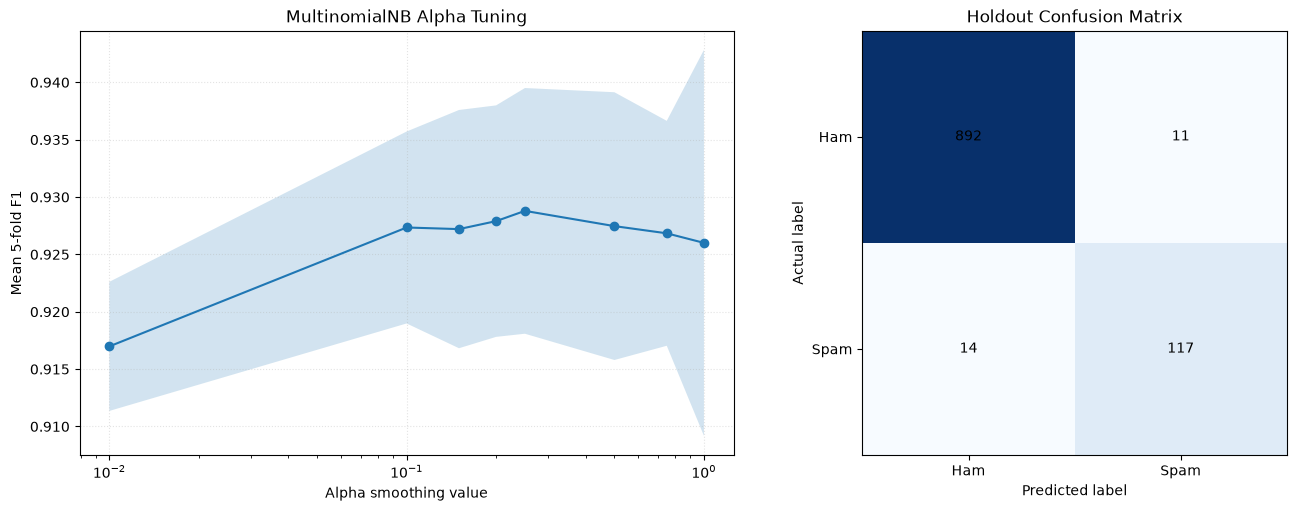

In [39]:
# Personal notebook extension (not in HTB): visualize HTB-inspired alpha
# tuning and holdout classification errors.

import matplotlib.pyplot as plt


spam_grid_results = pd.DataFrame(
    spam_grid_search.cv_results_
)

spam_grid_results["alpha"] = (
    spam_grid_results[
        "param_classifier__alpha"
    ]
    .astype(float)
)

spam_grid_results = (
    spam_grid_results
    .sort_values("alpha")
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    constrained_layout=True
)


axes[0].plot(
    spam_grid_results["alpha"],
    spam_grid_results["mean_test_score"],
    marker="o"
)

axes[0].fill_between(
    spam_grid_results["alpha"],
    spam_grid_results["mean_test_score"]
    - spam_grid_results["std_test_score"],
    spam_grid_results["mean_test_score"]
    + spam_grid_results["std_test_score"],
    alpha=0.2
)

axes[0].set_xscale("log")
axes[0].set_title("MultinomialNB Alpha Tuning")
axes[0].set_xlabel("Alpha smoothing value")
axes[0].set_ylabel("Mean 5-fold F1")
axes[0].grid(
    linestyle=":",
    alpha=0.35
)


axes[1].imshow(
    spam_confusion_matrix,
    cmap="Blues"
)

axes[1].set_title("Holdout Confusion Matrix")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Actual label")
axes[1].set_xticks(
    [0, 1],
    ["Ham", "Spam"]
)
axes[1].set_yticks(
    [0, 1],
    ["Ham", "Spam"]
)

for row in range(2):
    for column in range(2):
        axes[1].text(
            column,
            row,
            spam_confusion_matrix[row, column],
            ha="center",
            va="center"
        )

plt.show()

## Train, tune, and evaluate the spam detector

The model-selection pipeline keeps vectorization inside cross-validation, avoiding vocabulary leakage from validation folds. Grid search selects `alpha=0.25`, with a mean cross-validated F1 of approximately 0.9288. On the holdout set, the classifier reaches about 0.9035 F1, 0.9141 precision, 0.8931 recall, 0.9744 ROC AUC, and 0.9470 average precision.

The confusion matrix gives the operational detail behind those aggregates: 892 ham messages were correctly retained, 11 ham messages were flagged as spam, 14 spam messages were missed, and 117 spam messages were detected. The gap between precision and recall is not merely a score difference; it represents the threshold tradeoff between protecting the inbox from unwanted mail and preserving legitimate messages. The following cells test the fitted pipeline on new messages and package it for reuse.


In [40]:
# HTB lesson inference workflow adapted to the notebook's namespaced pipeline
# and preserved preprocessing variables.
# HTB's example messages and preprocessing logic are retained; variable
# structure and tabular display are personal.

import re
import pandas as pd

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize


spam_inference_stop_words = set(
    stopwords.words("english")
)

spam_inference_stemmer = PorterStemmer()


def preprocess_for_spam_model(message):
    message = message.lower()

    message = re.sub(
        r"[^a-z\s$!]",
        "",
        message
    )

    tokens = word_tokenize(message)

    tokens = [
        token
        for token in tokens
        if token not in spam_inference_stop_words
    ]

    tokens = [
        spam_inference_stemmer.stem(token)
        for token in tokens
    ]

    return " ".join(tokens)


spam_new_messages = [
    (
        "Congratulations! You've won a $1000 Walmart gift card. "
        "Go to http://bit.ly/1234 to claim now."
    ),
    "Hey, are we still meeting up for lunch today?",
    (
        "Urgent! Your account has been compromised. "
        "Verify your details here: www.fakebank.com/verify"
    ),
    "Reminder: Your appointment is scheduled for tomorrow at 10am.",
    (
        "FREE entry in a weekly competition to win an iPad. "
        "Just text WIN to 80085 now!"
    )
]


spam_processed_messages = [
    preprocess_for_spam_model(message)
    for message in spam_new_messages
]


spam_new_features = (
    spam_best_model
    .named_steps["vectorizer"]
    .transform(spam_processed_messages)
)

spam_new_predictions = (
    spam_best_model
    .named_steps["classifier"]
    .predict(spam_new_features)
)

spam_new_probabilities = (
    spam_best_model
    .named_steps["classifier"]
    .predict_proba(spam_new_features)
)


spam_prediction_results = pd.DataFrame({
    "Original message": spam_new_messages,
    "Processed message": spam_processed_messages,
    "Prediction": [
        "Spam" if prediction == 1
        else "Not-Spam"
        for prediction in spam_new_predictions
    ],
    "Spam probability": spam_new_probabilities[:, 1],
    "Not-spam probability": spam_new_probabilities[:, 0]
})


display(
    spam_prediction_results[
        [
            "Original message",
            "Prediction",
            "Spam probability",
            "Not-spam probability"
        ]
    ].round(4)
)

,Original message,Prediction,Spam probability,Not-spam probability
0,Congratulations! You've won a $1000 Walmart gi...,Spam,1.0000,0.0000
1,"Hey, are we still meeting up for lunch today?",Not-Spam,0.0000,1.0000
2,Urgent! Your account has been compromised. Ver...,Spam,0.9945,0.0055
3,Reminder: Your appointment is scheduled for to...,Not-Spam,0.0039,0.9961
4,FREE entry in a weekly competition to win an i...,Spam,1.0000,0.0000


In [41]:
# HTB lesson model-persistence workflow adapted to save this notebook's spam
# pipeline and verify exact reload predictions.
# Reload verification is a personal reproducibility safeguard.

from pathlib import Path

import joblib
import numpy as np


spam_model_path = Path(
    "spam_detection_model.joblib"
)


joblib.dump(
    spam_best_model,
    spam_model_path
)


loaded_spam_model = joblib.load(
    spam_model_path
)


loaded_predictions = (
    loaded_spam_model
    .predict(spam_test_texts)
)


assert np.array_equal(
    loaded_predictions,
    spam_test_predictions
)


print(
    f"Model saved and verified: {spam_model_path}"
)

Model saved and verified: spam_detection_model.joblib


## From predictive result to usable artifact

Inference examples demonstrate the full path from raw message to predicted label and probability. Saving the complete pipeline with `joblib` is important: the deployed artifact must include the exact text transformation and feature vocabulary that the classifier expects, not just the fitted estimator. Reloading the artifact and comparing predictions provides a basic integrity check.

The manifest and extended diagnostics then record what was trained, how it was evaluated, and where uncertainty or error concentrates. The final visualization set is intentionally model-aware: it examines probability behavior and feature-level evidence rather than treating a single metric as the complete explanation of model quality.


In [42]:
# Personal notebook addition (not in HTB): prepare a model-evaluation manifest
# for audit and reproducibility.

from hashlib import sha256

import pandas as pd


evaluation_model_path = Path(
    spam_model_path
)


if not evaluation_model_path.is_file():
    raise FileNotFoundError(
        f"Model file not found: {evaluation_model_path}"
    )


holdout_metric_values = (
    spam_holdout_metrics
    .set_index("Metric")["Value"]
)


evaluation_manifest = pd.DataFrame([{
    "Model file": str(evaluation_model_path),
    "Model size (bytes)": evaluation_model_path.stat().st_size,
    "Model SHA-256": sha256(
        evaluation_model_path.read_bytes()
    ).hexdigest(),
    "Best alpha": (
        spam_grid_search
        .best_params_["classifier__alpha"]
    ),
    "Cross-validation F1": (
        spam_grid_search.best_score_
    ),
    "Holdout F1": holdout_metric_values["F1"],
    "Holdout precision": holdout_metric_values["Precision"],
    "Holdout recall": holdout_metric_values["Recall"],
    "Holdout ROC AUC": holdout_metric_values["ROC AUC"],
    "Test messages": len(spam_test_texts)
}]).T.rename(
    columns={0: "Value"}
)


display(evaluation_manifest)

,Value
Model file,spam_detection_model.joblib
Model size (bytes),1461853
Model SHA-256,772f546871539d5945a2bdfc0636a7bea2581701b1a3ad...
Best alpha,0.25
Cross-validation F1,0.928794
Holdout F1,0.9035
Holdout precision,0.9141
Holdout recall,0.8931
Holdout ROC AUC,0.9744
Test messages,1034


In [43]:
# Personal notebook experiment (not in HTB): compare raw text with
# HTB-preprocessed text using a separate TF-IDF model.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    roc_auc_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)
from sklearn.pipeline import Pipeline


raw_texts = (
    sms["message"]
    .fillna("")
    .astype(str)
)

preprocessed_texts = (
    spam_preprocessed["message_preprocessed"]
    .fillna("")
    .astype(str)
)

raw_targets = (
    sms["is_spam_numeric"]
    .astype(int)
    .to_numpy()
)

preprocessed_targets = (
    spam_preprocessed["is_spam_numeric"]
    .astype(int)
    .to_numpy()
)

assert len(raw_texts) == len(preprocessed_texts)
assert np.array_equal(
    raw_targets,
    preprocessed_targets
)


comparison_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def evaluate_text_representation(
    texts,
    targets,
    representation_name
):
    text_model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.98,
                sublinear_tf=True,
                max_features=12000
            )
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=42
            )
        )
    ])

    out_of_fold_probabilities = cross_val_predict(
        text_model,
        texts.to_numpy(),
        targets,
        cv=comparison_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    text_model.fit(
        texts.to_numpy(),
        targets
    )

    vocabulary_size = len(
        text_model
        .named_steps["tfidf"]
        .vocabulary_
    )

    return {
        "Representation": representation_name,
        "ROC AUC": roc_auc_score(
            targets,
            out_of_fold_probabilities
        ),
        "Average Precision": average_precision_score(
            targets,
            out_of_fold_probabilities
        ),
        "Brier Score": brier_score_loss(
            targets,
            out_of_fold_probabilities
        ),
        "Vocabulary Size": vocabulary_size
    }


representation_comparison = pd.DataFrame([
    evaluate_text_representation(
        raw_texts,
        raw_targets,
        "Raw text"
    ),
    evaluate_text_representation(
        preprocessed_texts,
        preprocessed_targets,
        "HTB-preprocessed text"
    )
]).set_index(
    "Representation"
).round(3)

display(representation_comparison)

,ROC AUC,Average Precision,Brier Score,Vocabulary Size
Representation,,,,
Raw text,0.991,0.975,0.028,6533
HTB-preprocessed text,0.986,0.949,0.034,3559


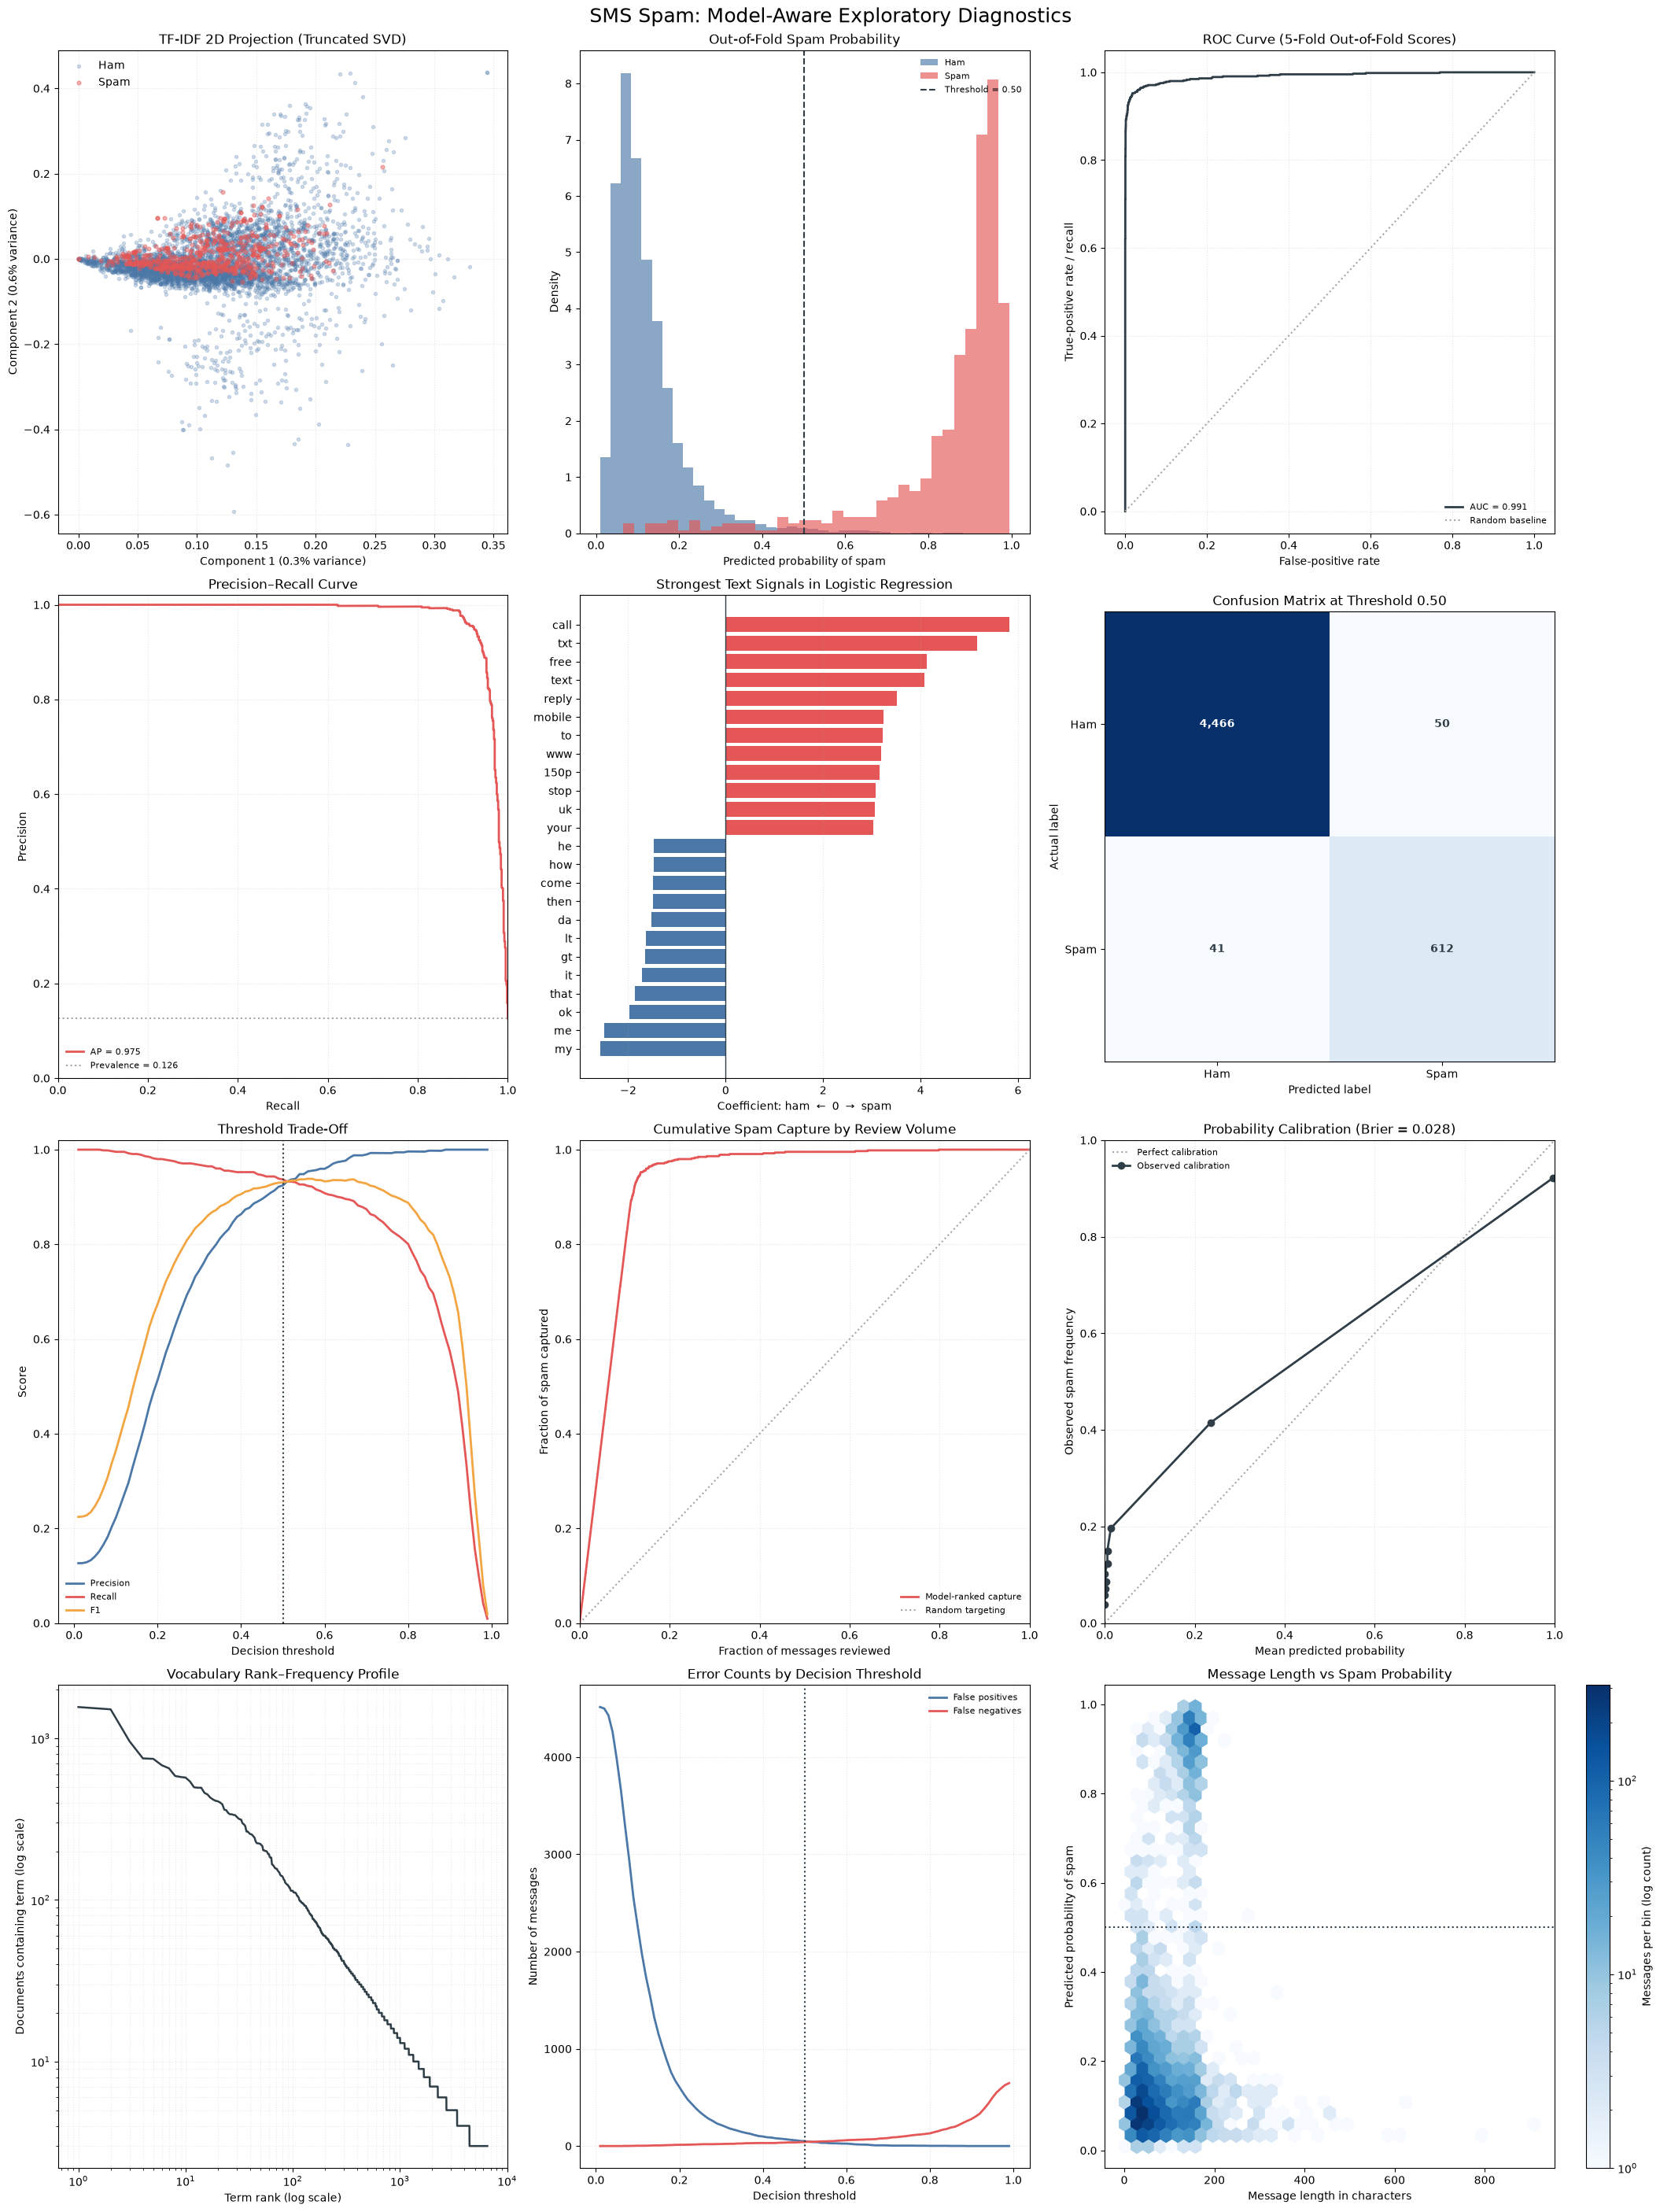

5-fold out-of-fold ROC AUC: 0.991
5-fold out-of-fold average precision: 0.975
Brier score: 0.028
Vocabulary size: 6,533 terms
TF-IDF matrix shape: 5,169 messages x 6,533 terms


In [44]:
# Personal notebook addition (not in HTB): advanced diagnostics for the SMS
# Spam Collection.
#
# Reference-informed themes:
# - TF-IDF and dimensionality reduction
# - exploratory distributions and projections
# - ROC, precision-recall, calibration, and confusion-matrix analysis
# - threshold selection for security-oriented triage
# The analysis is informed by HTB metrics/preprocessing concepts and external
# references; this implementation is personal.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline


# ---------------------------------------------------------------------
# 1. Prepare text and labels
# ---------------------------------------------------------------------
advanced_texts = (
    sms["message"]
    .fillna("")
    .astype(str)
)

advanced_y = (
    sms["is_spam_numeric"]
    .astype(int)
    .to_numpy()
)


# ---------------------------------------------------------------------
# 2. Build a reproducible TF-IDF + logistic-regression pipeline
# ---------------------------------------------------------------------
advanced_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.98,
            sublinear_tf=True,
            max_features=12000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            solver="liblinear",
            random_state=42
        )
    )
])


# ---------------------------------------------------------------------
# 3. Generate out-of-fold probabilities
#
# Each message receives a probability from a model that did not train
# on that message. This gives a more honest evaluation than scoring the
# same rows used during model fitting.
# ---------------------------------------------------------------------
advanced_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

advanced_oof_probability = cross_val_predict(
    advanced_pipeline,
    advanced_texts,
    advanced_y,
    cv=advanced_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# Fit the final model on all available messages for feature inspection.
advanced_pipeline.fit(
    advanced_texts,
    advanced_y
)

advanced_vectorizer = (
    advanced_pipeline
    .named_steps["tfidf"]
)

advanced_classifier = (
    advanced_pipeline
    .named_steps["classifier"]
)

advanced_tfidf = (
    advanced_vectorizer
    .transform(advanced_texts)
)

advanced_oof_prediction = (
    advanced_oof_probability >= 0.50
).astype(int)


# ---------------------------------------------------------------------
# 4. Derive model diagnostics
# ---------------------------------------------------------------------
advanced_svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

advanced_projection = (
    advanced_svd
    .fit_transform(advanced_tfidf)
)

advanced_fpr, advanced_tpr, _ = roc_curve(
    advanced_y,
    advanced_oof_probability
)

advanced_precision_curve, advanced_recall_curve, _ = (
    precision_recall_curve(
        advanced_y,
        advanced_oof_probability
    )
)

advanced_thresholds = np.linspace(
    0.01,
    0.99,
    99
)

advanced_threshold_metrics = pd.DataFrame({
    "threshold": advanced_thresholds,
    "precision": [
        precision_score(
            advanced_y,
            advanced_oof_probability >= threshold,
            zero_division=0
        )
        for threshold in advanced_thresholds
    ],
    "recall": [
        recall_score(
            advanced_y,
            advanced_oof_probability >= threshold,
            zero_division=0
        )
        for threshold in advanced_thresholds
    ],
    "f1": [
        f1_score(
            advanced_y,
            advanced_oof_probability >= threshold,
            zero_division=0
        )
        for threshold in advanced_thresholds
    ]
})

advanced_confusion = confusion_matrix(
    advanced_y,
    advanced_oof_prediction,
    labels=[0, 1]
)

advanced_calibration_predicted, advanced_calibration_observed = (
    calibration_curve(
        advanced_y,
        advanced_oof_probability,
        n_bins=10,
        strategy="quantile"
    )
)

advanced_ranked_indices = np.argsort(
    advanced_oof_probability
)[::-1]

advanced_ranked_labels = (
    advanced_y[advanced_ranked_indices]
)

advanced_cumulative_capture = (
    np.cumsum(advanced_ranked_labels)
    / advanced_ranked_labels.sum()
)

advanced_population_fraction = (
    np.arange(1, len(advanced_ranked_labels) + 1)
    / len(advanced_ranked_labels)
)

advanced_document_frequency = np.diff(
    advanced_tfidf.tocsc().indptr
)

advanced_document_frequency = np.sort(
    advanced_document_frequency
)[::-1]

advanced_term_rank = np.arange(
    1,
    len(advanced_document_frequency) + 1
)

advanced_false_positive_counts = np.array([
    np.sum(
        (advanced_oof_probability >= threshold)
        & (advanced_y == 0)
    )
    for threshold in advanced_thresholds
])

advanced_false_negative_counts = np.array([
    np.sum(
        (advanced_oof_probability < threshold)
        & (advanced_y == 1)
    )
    for threshold in advanced_thresholds
])

advanced_message_lengths = (
    advanced_texts
    .str.len()
    .to_numpy()
)


# ---------------------------------------------------------------------
# 5. Extract strongest text signals from the fitted model
# ---------------------------------------------------------------------
advanced_feature_names = (
    advanced_vectorizer
    .get_feature_names_out()
)

advanced_coefficients = (
    advanced_classifier
    .coef_[0]
)

advanced_top_n = min(
    12,
    max(1, len(advanced_feature_names) // 2)
)

advanced_negative_indices = np.argsort(
    advanced_coefficients
)[:advanced_top_n]

advanced_positive_indices = np.argsort(
    advanced_coefficients
)[-advanced_top_n:]

advanced_signal_indices = np.concatenate([
    advanced_negative_indices,
    advanced_positive_indices
])

advanced_signal_order = (
    advanced_signal_indices[
        np.argsort(
            advanced_coefficients[
                advanced_signal_indices
            ]
        )
    ]
)


# ---------------------------------------------------------------------
# 6. Build the advanced visualization dashboard
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    4,
    3,
    figsize=(21, 28),
    constrained_layout=True
)

axes = axes.ravel()

ADV_HAM = "#4c78a8"
ADV_SPAM = "#e45756"
ADV_DARK = "#2f3e46"
ADV_GOLD = "#f2a541"


# ---------------------------------------------------------------------
# View 1: TF-IDF latent-space projection
# ---------------------------------------------------------------------
axes[0].scatter(
    advanced_projection[advanced_y == 0, 0],
    advanced_projection[advanced_y == 0, 1],
    s=9,
    alpha=0.25,
    color=ADV_HAM,
    label="Ham"
)

axes[0].scatter(
    advanced_projection[advanced_y == 1, 0],
    advanced_projection[advanced_y == 1, 1],
    s=12,
    alpha=0.45,
    color=ADV_SPAM,
    label="Spam"
)

axes[0].set_title(
    "TF-IDF 2D Projection (Truncated SVD)"
)

axes[0].set_xlabel(
    f"Component 1 "
    f"({advanced_svd.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

axes[0].set_ylabel(
    f"Component 2 "
    f"({advanced_svd.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

axes[0].legend(frameon=False)
axes[0].grid(
    linestyle=":",
    alpha=0.3
)


# ---------------------------------------------------------------------
# View 2: Out-of-fold probability distributions
# ---------------------------------------------------------------------
axes[1].hist(
    advanced_oof_probability[advanced_y == 0],
    bins=35,
    density=True,
    alpha=0.65,
    color=ADV_HAM,
    label="Ham"
)

axes[1].hist(
    advanced_oof_probability[advanced_y == 1],
    bins=35,
    density=True,
    alpha=0.65,
    color=ADV_SPAM,
    label="Spam"
)

axes[1].axvline(
    0.50,
    color=ADV_DARK,
    linestyle="--",
    linewidth=1.5,
    label="Threshold = 0.50"
)

axes[1].set_title(
    "Out-of-Fold Spam Probability"
)

axes[1].set_xlabel(
    "Predicted probability of spam"
)

axes[1].set_ylabel(
    "Density"
)

axes[1].legend(
    frameon=False,
    fontsize=8
)


# ---------------------------------------------------------------------
# View 3: ROC curve
# ---------------------------------------------------------------------
advanced_auc = roc_auc_score(
    advanced_y,
    advanced_oof_probability
)

axes[2].plot(
    advanced_fpr,
    advanced_tpr,
    color=ADV_DARK,
    linewidth=2,
    label=f"AUC = {advanced_auc:.3f}"
)

axes[2].plot(
    [0, 1],
    [0, 1],
    color="0.65",
    linestyle=":",
    label="Random baseline"
)

axes[2].set_title(
    "ROC Curve (5-Fold Out-of-Fold Scores)"
)

axes[2].set_xlabel(
    "False-positive rate"
)

axes[2].set_ylabel(
    "True-positive rate / recall"
)

axes[2].legend(
    frameon=False,
    fontsize=8
)

axes[2].grid(
    linestyle=":",
    alpha=0.3
)


# ---------------------------------------------------------------------
# View 4: Precision-recall curve
# ---------------------------------------------------------------------
advanced_average_precision = average_precision_score(
    advanced_y,
    advanced_oof_probability
)

axes[3].plot(
    advanced_recall_curve,
    advanced_precision_curve,
    color=ADV_SPAM,
    linewidth=2,
    label=f"AP = {advanced_average_precision:.3f}"
)

axes[3].axhline(
    advanced_y.mean(),
    color="0.65",
    linestyle=":",
    label=f"Prevalence = {advanced_y.mean():.3f}"
)

axes[3].set_title(
    "Precision–Recall Curve"
)

axes[3].set_xlabel(
    "Recall"
)

axes[3].set_ylabel(
    "Precision"
)

axes[3].set_xlim(
    0,
    1
)

axes[3].set_ylim(
    0,
    1.02
)

axes[3].legend(
    frameon=False,
    fontsize=8
)

axes[3].grid(
    linestyle=":",
    alpha=0.3
)


# ---------------------------------------------------------------------
# View 5: Model-derived text signals
# ---------------------------------------------------------------------
axes[4].barh(
    advanced_feature_names[advanced_signal_order],
    advanced_coefficients[advanced_signal_order],
    color=[
        ADV_HAM if value < 0 else ADV_SPAM
        for value in advanced_coefficients[
            advanced_signal_order
        ]
    ]
)

axes[4].axvline(
    0,
    color=ADV_DARK,
    linewidth=1
)

axes[4].set_title(
    "Strongest Text Signals in Logistic Regression"
)

axes[4].set_xlabel(
    "Coefficient: ham  ←  0  →  spam"
)

axes[4].grid(
    axis="x",
    linestyle=":",
    alpha=0.3
)


# ---------------------------------------------------------------------
# View 6: Confusion matrix
# ---------------------------------------------------------------------
axes[5].imshow(
    advanced_confusion,
    cmap="Blues"
)

axes[5].set_title(
    "Confusion Matrix at Threshold 0.50"
)

axes[5].set_xlabel(
    "Predicted label"
)

axes[5].set_ylabel(
    "Actual label"
)

axes[5].set_xticks(
    [0, 1],
    ["Ham", "Spam"]
)

axes[5].set_yticks(
    [0, 1],
    ["Ham", "Spam"]
)

for row in range(2):
    for column in range(2):
        cell_value = advanced_confusion[row, column]

        axes[5].text(
            column,
            row,
            f"{cell_value:,}",
            ha="center",
            va="center",
            color=(
                "white"
                if cell_value > advanced_confusion.max() * 0.5
                else ADV_DARK
            ),
            fontweight="bold"
        )


# ---------------------------------------------------------------------
# View 7: Precision/recall/F1 threshold trade-off
# ---------------------------------------------------------------------
axes[6].plot(
    advanced_threshold_metrics["threshold"],
    advanced_threshold_metrics["precision"],
    label="Precision",
    color=ADV_HAM,
    linewidth=2
)

axes[6].plot(
    advanced_threshold_metrics["threshold"],
    advanced_threshold_metrics["recall"],
    label="Recall",
    color=ADV_SPAM,
    linewidth=2
)

axes[6].plot(
    advanced_threshold_metrics["threshold"],
    advanced_threshold_metrics["f1"],
    label="F1",
    color=ADV_GOLD,
    linewidth=2
)

axes[6].axvline(
    0.50,
    color=ADV_DARK,
    linestyle=":",
    linewidth=1.5
)

axes[6].set_title(
    "Threshold Trade-Off"
)

axes[6].set_xlabel(
    "Decision threshold"
)

axes[6].set_ylabel(
    "Score"
)

axes[6].set_ylim(
    0,
    1.02
)

axes[6].legend(
    frameon=False,
    fontsize=8
)

axes[6].grid(
    linestyle=":",
    alpha=0.3
)


# ---------------------------------------------------------------------
# View 8: Cumulative spam capture
# ---------------------------------------------------------------------
axes[7].plot(
    advanced_population_fraction,
    advanced_cumulative_capture,
    color=ADV_SPAM,
    linewidth=2,
    label="Model-ranked capture"
)

axes[7].plot(
    [0, 1],
    [0, 1],
    color="0.65",
    linestyle=":",
    label="Random targeting"
)

axes[7].set_title(
    "Cumulative Spam Capture by Review Volume"
)

axes[7].set_xlabel(
    "Fraction of messages reviewed"
)

axes[7].set_ylabel(
    "Fraction of spam captured"
)

axes[7].set_xlim(
    0,
    1
)

axes[7].set_ylim(
    0,
    1.02
)

axes[7].legend(
    frameon=False,
    fontsize=8
)

axes[7].grid(
    linestyle=":",
    alpha=0.3
)


# ---------------------------------------------------------------------
# View 9: Calibration / reliability
# ---------------------------------------------------------------------
advanced_brier = brier_score_loss(
    advanced_y,
    advanced_oof_probability
)

axes[8].plot(
    [0, 1],
    [0, 1],
    color="0.65",
    linestyle=":",
    label="Perfect calibration"
)

axes[8].plot(
    advanced_calibration_predicted,
    advanced_calibration_observed,
    marker="o",
    color=ADV_DARK,
    linewidth=2,
    label="Observed calibration"
)

axes[8].set_title(
    f"Probability Calibration (Brier = {advanced_brier:.3f})"
)

axes[8].set_xlabel(
    "Mean predicted probability"
)

axes[8].set_ylabel(
    "Observed spam frequency"
)

axes[8].set_xlim(
    0,
    1
)

axes[8].set_ylim(
    0,
    1
)

axes[8].legend(
    frameon=False,
    fontsize=8
)

axes[8].grid(
    linestyle=":",
    alpha=0.3
)


# ---------------------------------------------------------------------
# View 10: Vocabulary rank-frequency profile
# ---------------------------------------------------------------------
axes[9].loglog(
    advanced_term_rank,
    advanced_document_frequency,
    color=ADV_DARK,
    linewidth=1.8
)

axes[9].set_title(
    "Vocabulary Rank–Frequency Profile"
)

axes[9].set_xlabel(
    "Term rank (log scale)"
)

axes[9].set_ylabel(
    "Documents containing term (log scale)"
)

axes[9].grid(
    which="both",
    linestyle=":",
    alpha=0.25
)


# ---------------------------------------------------------------------
# View 11: False-positive and false-negative counts
# ---------------------------------------------------------------------
axes[10].plot(
    advanced_thresholds,
    advanced_false_positive_counts,
    color=ADV_HAM,
    linewidth=2,
    label="False positives"
)

axes[10].plot(
    advanced_thresholds,
    advanced_false_negative_counts,
    color=ADV_SPAM,
    linewidth=2,
    label="False negatives"
)

axes[10].axvline(
    0.50,
    color=ADV_DARK,
    linestyle=":",
    linewidth=1.5
)

axes[10].set_title(
    "Error Counts by Decision Threshold"
)

axes[10].set_xlabel(
    "Decision threshold"
)

axes[10].set_ylabel(
    "Number of messages"
)

axes[10].legend(
    frameon=False,
    fontsize=8
)

axes[10].grid(
    linestyle=":",
    alpha=0.3
)


# ---------------------------------------------------------------------
# View 12: Message length versus model probability
# ---------------------------------------------------------------------
advanced_hexbin = axes[11].hexbin(
    advanced_message_lengths,
    advanced_oof_probability,
    gridsize=35,
    mincnt=1,
    cmap="Blues",
    bins="log"
)

axes[11].axhline(
    0.50,
    color=ADV_DARK,
    linestyle=":",
    linewidth=1.5
)

axes[11].set_title(
    "Message Length vs Spam Probability"
)

axes[11].set_xlabel(
    "Message length in characters"
)

axes[11].set_ylabel(
    "Predicted probability of spam"
)

advanced_colorbar = fig.colorbar(
    advanced_hexbin,
    ax=axes[11]
)

advanced_colorbar.set_label(
    "Messages per bin (log count)"
)


fig.suptitle(
    "SMS Spam: Model-Aware Exploratory Diagnostics",
    fontsize=18
)

plt.show()


# ---------------------------------------------------------------------
# Compact numerical summary
# ---------------------------------------------------------------------
print(
    f"5-fold out-of-fold ROC AUC: "
    f"{advanced_auc:.3f}"
)

print(
    f"5-fold out-of-fold average precision: "
    f"{advanced_average_precision:.3f}"
)

print(
    f"Brier score: "
    f"{advanced_brier:.3f}"
)

print(
    f"Vocabulary size: "
    f"{len(advanced_feature_names):,} terms"
)

print(
    f"TF-IDF matrix shape: "
    f"{advanced_tfidf.shape[0]:,} messages x "
    f"{advanced_tfidf.shape[1]:,} terms"
)

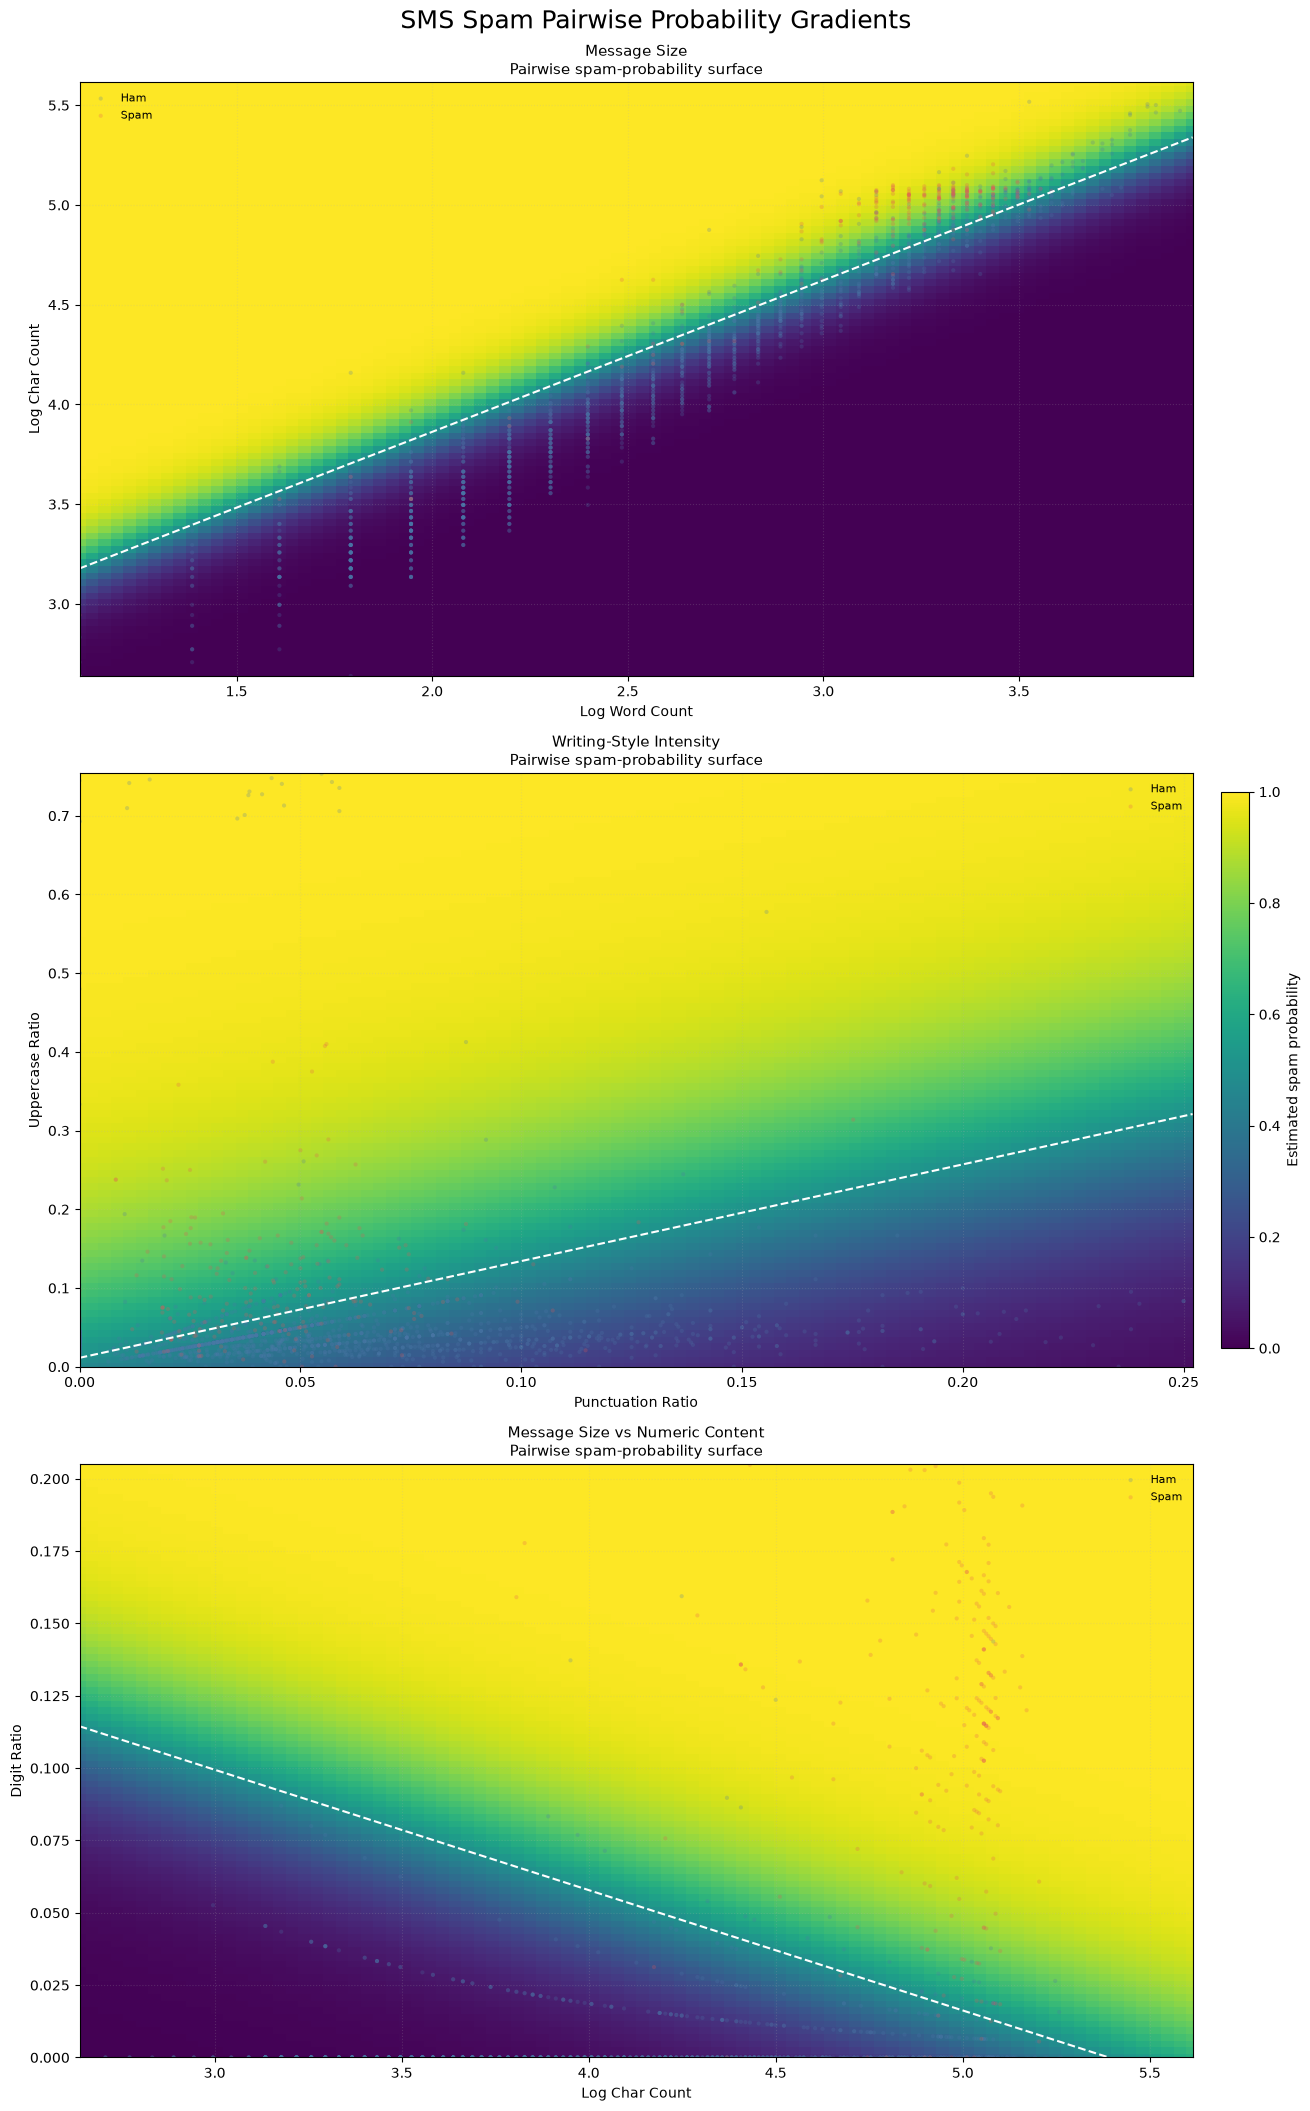

In [45]:
# Personal notebook addition (not in HTB): create three pairwise
# spam-probability gradient surfaces from engineered metadata features.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


gradient_frame = sms.copy()

gradient_frame["message"] = (
    gradient_frame["message"]
    .fillna("")
    .astype(str)
)

gradient_frame["label"] = (
    gradient_frame["label"]
    .astype(str)
    .str.lower()
)

gradient_frame["is_spam_numeric"] = (
    gradient_frame["label"]
    .eq("spam")
    .astype(int)
)

gradient_frame["char_count"] = (
    gradient_frame["message"]
    .str.len()
)

gradient_frame["word_count"] = (
    gradient_frame["message"]
    .str.split()
    .str.len()
)

gradient_frame["digit_count"] = (
    gradient_frame["message"]
    .str.count(r"\d")
)

gradient_frame["uppercase_count"] = (
    gradient_frame["message"]
    .apply(
        lambda text: sum(
            character.isupper()
            for character in text
        )
    )
)

gradient_frame["punctuation_count"] = (
    gradient_frame["message"]
    .str.count(r"[^\w\s]")
)

safe_char_count = (
    gradient_frame["char_count"]
    .clip(lower=1)
)

gradient_frame["log_word_count"] = np.log1p(
    gradient_frame["word_count"]
)

gradient_frame["log_char_count"] = np.log1p(
    gradient_frame["char_count"]
)

gradient_frame["digit_ratio"] = (
    gradient_frame["digit_count"]
    / safe_char_count
)

gradient_frame["uppercase_ratio"] = (
    gradient_frame["uppercase_count"]
    / safe_char_count
)

gradient_frame["punctuation_ratio"] = (
    gradient_frame["punctuation_count"]
    / safe_char_count
)


gradient_pairs = [
    (
        "log_word_count",
        "log_char_count",
        "Message Size"
    ),
    (
        "punctuation_ratio",
        "uppercase_ratio",
        "Writing-Style Intensity"
    ),
    (
        "log_char_count",
        "digit_ratio",
        "Message Size vs Numeric Content"
    )
]


gradient_colors = {
    "ham": "#4c78a8",
    "spam": "#e45756"
}


def robust_axis(values, points=90):
    bounds = np.nanpercentile(
        values,
        [1, 99]
    )

    if bounds[0] == bounds[1]:
        bounds[0] -= 0.5
        bounds[1] += 0.5

    return np.linspace(
        bounds[0],
        bounds[1],
        points
    ), bounds


def plot_gradient_surface(
    ax,
    frame,
    x_name,
    y_name,
    title,
    rng
):
    pair_frame = (
        frame[
            [
                x_name,
                y_name,
                "label",
                "is_spam_numeric"
            ]
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .copy()
    )

    pair_frame[x_name] = (
        pair_frame[x_name]
        .astype(float)
    )

    pair_frame[y_name] = (
        pair_frame[y_name]
        .astype(float)
    )

    pair_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="liblinear",
            random_state=42
        )
    )

    pair_model.fit(
        pair_frame[
            [
                x_name,
                y_name
            ]
        ],
        pair_frame["is_spam_numeric"]
    )

    x_axis, x_bounds = robust_axis(
        pair_frame[x_name]
    )

    y_axis, y_bounds = robust_axis(
        pair_frame[y_name]
    )

    x_grid, y_grid = np.meshgrid(
        x_axis,
        y_axis
    )

    grid_frame = pd.DataFrame({
        x_name: x_grid.ravel(),
        y_name: y_grid.ravel()
    })

    probability_grid = (
        pair_model
        .predict_proba(grid_frame)[:, 1]
        .reshape(x_grid.shape)
    )

    image = ax.pcolormesh(
        x_axis,
        y_axis,
        probability_grid,
        shading="auto",
        cmap="viridis",
        vmin=0,
        vmax=1
    )

    if (
        probability_grid.min() < 0.5
        and probability_grid.max() > 0.5
    ):
        ax.contour(
            x_axis,
            y_axis,
            probability_grid,
            levels=[0.5],
            colors="white",
            linestyles="--",
            linewidths=1.5
        )

    # Keep plotted observations inside the same robust bounds as the surface.
    visible_points = pair_frame[
        (pair_frame[x_name] >= x_bounds[0])
        & (pair_frame[x_name] <= x_bounds[1])
        & (pair_frame[y_name] >= y_bounds[0])
        & (pair_frame[y_name] <= y_bounds[1])
    ]

    sample_size = min(
        1600,
        len(visible_points)
    )

    sample_indices = rng.choice(
        len(visible_points),
        size=sample_size,
        replace=False
    )

    sampled_points = visible_points.iloc[
        sample_indices
    ]

    for label, color in gradient_colors.items():
        subset = sampled_points[
            sampled_points["label"] == label
        ]

        ax.scatter(
            subset[x_name],
            subset[y_name],
            s=9,
            alpha=0.24,
            color=color,
            edgecolors="none",
            label=label.title()
        )

    ax.set_xlim(
        x_bounds[0],
        x_bounds[1]
    )

    ax.set_ylim(
        y_bounds[0],
        y_bounds[1]
    )

    ax.set_title(
        f"{title}\nPairwise spam-probability surface",
        fontsize=11
    )

    ax.set_xlabel(
        x_name.replace("_", " ").title()
    )

    ax.set_ylabel(
        y_name.replace("_", " ").title()
    )

    ax.legend(
        frameon=False,
        fontsize=8
    )

    ax.grid(
        linestyle=":",
        alpha=0.2
    )

    return image


rng = np.random.default_rng(42)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(13, 21),
    constrained_layout=True
)

gradient_images = []

for axis, pair in zip(
    axes,
    gradient_pairs
):
    x_name, y_name, title = pair

    image = plot_gradient_surface(
        axis,
        gradient_frame,
        x_name,
        y_name,
        title,
        rng
    )

    gradient_images.append(image)


gradient_colorbar = fig.colorbar(
    gradient_images[0],
    ax=axes,
    fraction=0.025,
    pad=0.02
)

gradient_colorbar.set_label(
    "Estimated spam probability"
)

fig.suptitle(
    "SMS Spam Pairwise Probability Gradients",
    fontsize=18
)

plt.show()

## SMS case study synthesis

This case study demonstrates a reusable pattern for security text: preserve raw evidence, make normalization inspectable, keep feature learning inside the validation pipeline, tune against a metric aligned with the operational risk, and export preprocessing together with the model. It also shows why class balance, duplicate structure, and error slices should be understood before a score is promoted to a deployment claim.

The next dataset changes the feature geometry completely. Instead of short messages, we work with NSL-KDD network records containing categorical protocol/service fields, numeric traffic measurements, and a taxonomy of normal traffic and attack families. The core lifecycle remains the same, but the representation and evaluation questions become multi-class and highly imbalanced.


# Network anomaly detection: model structured traffic

NSL-KDD is a refined version of the KDD’99 intrusion-detection benchmark. The loaded file contains 148,517 rows and 43 columns, including protocol, service, connection statistics, and an attack label. Its value for this exercise is the combination of scale, categorical structure, attack taxonomy, and severe class imbalance; its age and benchmark provenance also mean that results should be interpreted as a controlled experiment rather than as evidence of current network performance.

We will first inventory the raw schema and attack distribution, then construct both a binary normal-versus-attack target and a five-class attack taxonomy. Categorical fields will be one-hot encoded, numeric signals will remain numeric, and stratified fit/validation/test partitions will preserve class proportions. A random forest will then provide a strong tabular baseline with interpretable feature importance and a persisted artifact.


In [46]:
# HTB lesson download-and-extract workflow adapted for repeatable local reuse
# of the NSL-KDD dataset.
# Personal modifications: reuse data or archive, check HTTP status, and locate
# KDD+.txt if extraction nests it.

from pathlib import Path
import io
import zipfile
import requests

network_dataset_url = (
    "https://academy.hackthebox.com/storage/modules/292/KDD_dataset.zip"
)
network_archive = Path("KDD_dataset.zip")
network_file = Path("KDD+.txt")

if network_file.exists():
    print(f"Dataset already available: {network_file}")
else:
    if not network_archive.exists():
        response = requests.get(network_dataset_url, timeout=30)
        response.raise_for_status()
        network_archive.write_bytes(response.content)
        print(f"Downloaded: {network_archive}")
    else:
        print(f"Using existing archive: {network_archive}")

    with zipfile.ZipFile(network_archive) as archive:
        archive.extractall(".")

    if not network_file.exists():
        candidates = list(Path(".").rglob("KDD+.txt"))

        if len(candidates) != 1:
            raise FileNotFoundError(
                "Could not uniquely locate KDD+.txt after extraction."
            )

        network_file = candidates[0]

    print(f"Dataset ready: {network_file}")

Dataset already available: KDD+.txt


In [47]:
# HTB lesson schema and load workflow adapted to preserve prior
# spam-classification variables through network_ names.
# The column order follows HTB; namespacing, header handling, and validation
# are personal.

import pandas as pd

network_columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "attack", "level"
]

network_df = pd.read_csv(
    network_file,
    names=network_columns,
    header=None
)

assert network_df.shape[1] == len(network_columns)

display(network_df.head())
print(f"Shape: {network_df.shape}")

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Shape: (148517, 43)


## Schema and initial inventory

The loader establishes the NSL-KDD schema and confirms that the frame has 43 named columns. The initial inventory reports no missing values but does reveal 610 duplicate rows—an important distinction between completeness and independence. The next dashboard examines protocols, services, and attack labels so that the target construction is grounded in the observed data rather than in an assumed class balance.


In [48]:
# Personal notebook addition (not in HTB): audit structure, missingness,
# duplicates, and label distributions before HTB preprocessing.

network_missing = (
    network_df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_values")
)

network_audit = pd.DataFrame({
    "dtype": network_df.dtypes.astype(str),
    "missing_values": network_df.isna().sum(),
    "unique_values": network_df.nunique(dropna=False)
})

display(network_audit)
print(f"Duplicate rows: {network_df.duplicated().sum():,}")
print(f"Missing values: {network_df.isna().sum().sum():,}")

display(
    network_df["attack"]
    .value_counts(dropna=False)
    .head(20)
    .rename("count")
    .to_frame()
)

display(
    network_df["protocol_type"]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

,dtype,missing_values,unique_values
duration,int64,0,3424
protocol_type,str,0,3
service,str,0,70
flag,str,0,11
src_bytes,int64,0,3601
dst_bytes,int64,0,10401
land,int64,0,2
wrong_fragment,int64,0,3
urgent,int64,0,4
hot,int64,0,29


Duplicate rows: 610
Missing values: 0


,count
attack,
normal,77054
neptune,45871
satan,4368
ipsweep,3740
smurf,3311
portsweep,3088
nmap,1566
back,1315
guess_passwd,1284


,count
protocol_type,
tcp,121569
udp,17614
icmp,9334


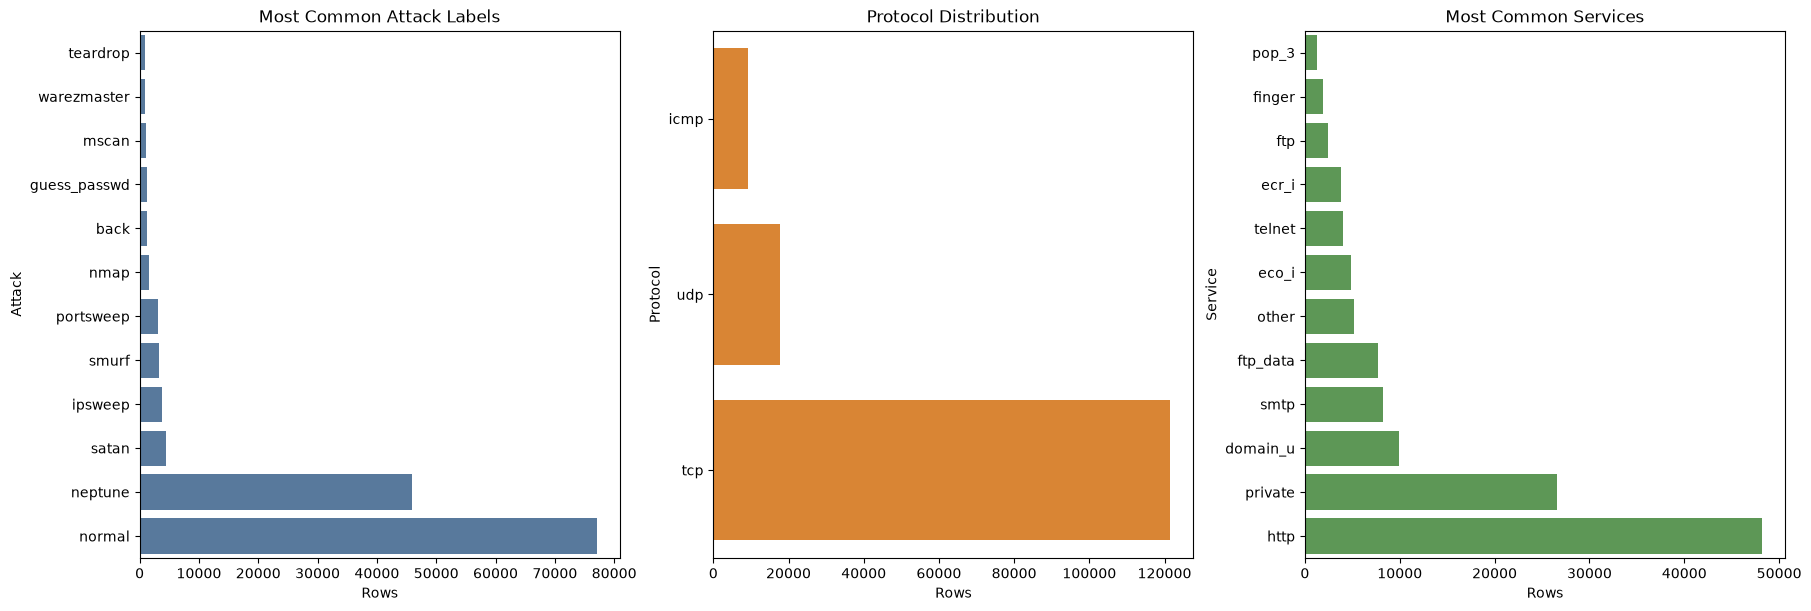

In [49]:
# Personal notebook addition (not in HTB): visualize initial attack, protocol,
# and service distributions.

import matplotlib.pyplot as plt
import seaborn as sns

attack_counts = (
    network_df["attack"]
    .value_counts()
    .head(12)
    .sort_values()
)

protocol_counts = (
    network_df["protocol_type"]
    .value_counts()
    .sort_values()
)

service_counts = (
    network_df["service"]
    .value_counts()
    .head(12)
    .sort_values()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

sns.barplot(
    x=attack_counts.values,
    y=attack_counts.index,
    ax=axes[0],
    color="#4C78A8"
)
axes[0].set_title("Most Common Attack Labels")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("Attack")

sns.barplot(
    x=protocol_counts.values,
    y=protocol_counts.index,
    ax=axes[1],
    color="#F58518"
)
axes[1].set_title("Protocol Distribution")
axes[1].set_xlabel("Rows")
axes[1].set_ylabel("Protocol")

sns.barplot(
    x=service_counts.values,
    y=service_counts.index,
    ax=axes[2],
    color="#54A24B"
)
axes[2].set_title("Most Common Services")
axes[2].set_xlabel("Rows")
axes[2].set_ylabel("Service")

plt.show()

## Translate the attack taxonomy into targets

The raw distribution is dominated by normal traffic (77,054 rows), followed by a large `neptune` group and much smaller attack families. TCP is the majority protocol, with UDP and ICMP forming smaller but meaningful populations. These counts immediately warn us that weighted metrics will be influenced by common classes and may hide poor performance on rare attack categories.

The target mapping therefore keeps two views: `attack_flag` for the operational binary question “normal or attack,” and `attack_map` for the more informative five-class taxonomy of normal, DoS, Probe, Privilege, and Access attacks. The mapping is fail-closed: known spelling corrections are applied explicitly and an unmapped label is treated as an error rather than silently assigned to a class. The next cells encode the explanatory variables.


In [50]:
# HTB lesson target-mapping workflow adapted to actual KDD+.txt label
# spellings and checked for complete coverage.

network_df["attack_flag"] = (
    network_df["attack"]
    .ne("normal")
    .astype("int8")
)

# Personal corrections to HTB's lists: KDD+.txt uses loadmodule, httptunnel,
# and xlock (not loadmdoule, http_tunnel, and xclock).
network_attack_groups = {
    1: [
        "apache2", "back", "land", "neptune", "mailbomb",
        "pod", "processtable", "smurf", "teardrop",
        "udpstorm", "worm"
    ],
    2: [
        "ipsweep", "mscan", "nmap", "portsweep",
        "saint", "satan"
    ],
    3: [
        "buffer_overflow", "loadmodule", "perl", "ps",
        "rootkit", "sqlattack", "xterm"
    ],
    4: [
        "ftp_write", "guess_passwd", "httptunnel", "imap",
        "multihop", "named", "phf", "sendmail",
        "snmpgetattack", "snmpguess", "spy",
        "warezclient", "warezmaster", "xlock", "xsnoop"
    ]
}

network_attack_to_class = {"normal": 0}

for class_id, attack_names in network_attack_groups.items():
    for attack_name in attack_names:
        network_attack_to_class[attack_name] = class_id

network_df["attack_map"] = (
    network_df["attack"]
    .map(network_attack_to_class)
)

unmapped_attacks = (
    network_df.loc[
        network_df["attack_map"].isna(),
        "attack"
    ]
    .unique()
    .tolist()
)

if unmapped_attacks:
    raise ValueError(
        f"Unmapped attack labels: {unmapped_attacks}"
    )

network_df["attack_map"] = (
    network_df["attack_map"]
    .astype("int8")
)

display(
    network_df[
        ["attack", "attack_flag", "attack_map"]
    ].head()
)

display(
    network_df["attack_map"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

,attack,attack_flag,attack_map
0,normal,0,0
1,normal,0,0
2,neptune,1,1
3,normal,0,0
4,normal,0,0


,count
attack_map,
0,77054
1,53387
2,14077
3,119
4,3880


In [51]:
# HTB lesson categorical-encoding workflow adapted with network_ names,
# explicit int8 dtype, and shape diagnostics.

network_categorical_features = [
    "protocol_type",
    "service"
]

network_encoded = pd.get_dummies(
    network_df[network_categorical_features],
    dtype="int8"
)

print(
    f"Encoded categorical shape: "
    f"{network_encoded.shape}"
)

display(network_encoded.head())

Encoded categorical shape: (148517, 73)


,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,...,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
# HTB lesson feature-assembly workflow adapted with network_ names and
# validation assertions.

network_numeric_features = [
    "duration", "src_bytes", "dst_bytes",
    "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "num_compromised",
    "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds",
    "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

network_train_set = (
    network_encoded
    .join(network_df[network_numeric_features])
    .copy()
)

network_multi_y = (
    network_df["attack_map"]
    .copy()
)

assert len(network_train_set) == len(network_multi_y)
assert network_train_set.isna().sum().sum() == 0

print(
    f"Feature matrix shape: "
    f"{network_train_set.shape}"
)

print(
    f"Target shape: "
    f"{network_multi_y.shape}"
)

Feature matrix shape: (148517, 107)
Target shape: (148517,)


## Assemble a model-ready matrix without erasing semantics

Protocol and service are represented categorically, while the numeric traffic features remain quantitative. The resulting matrix has 107 columns—73 categorical expansions plus the selected numeric signals. This is a useful checkpoint because it makes the feature contract visible and provides a stable reference for persistence and later inference.

Stratified splitting yields 83,169 fit rows, 35,644 validation rows, and 29,704 test rows. The following proportion check confirms that the rare classes are not accidentally concentrated in one partition before the random forest is trained.


In [53]:
# HTB lesson two-stage split adapted with stratification, network_ names, and
# an explicit proportion summary.

from sklearn.model_selection import train_test_split

network_train_X, network_test_X, network_train_y, network_test_y = (
    train_test_split(
        network_train_set,
        network_multi_y,
        test_size=0.20,
        random_state=1337,
        stratify=network_multi_y
    )
)

network_fit_X, network_val_X, network_fit_y, network_val_y = (
    train_test_split(
        network_train_X,
        network_train_y,
        test_size=0.30,
        random_state=1337,
        stratify=network_train_y
    )
)

network_split_summary = pd.DataFrame({
    "fit": network_fit_y.value_counts(normalize=True),
    "validation": network_val_y.value_counts(normalize=True),
    "test": network_test_y.value_counts(normalize=True)
}).fillna(0).round(4)

display(network_split_summary)

print(f"Fit rows: {len(network_fit_X):,}")
print(f"Validation rows: {len(network_val_X):,}")
print(f"Test rows: {len(network_test_X):,}")

,fit,validation,test
attack_map,,,
0,0.5188,0.5188,0.5188
1,0.3595,0.3595,0.3595
2,0.0948,0.0948,0.0948
4,0.0261,0.0261,0.0261
3,0.0008,0.0008,0.0008


Fit rows: 83,169
Validation rows: 35,644
Test rows: 29,704


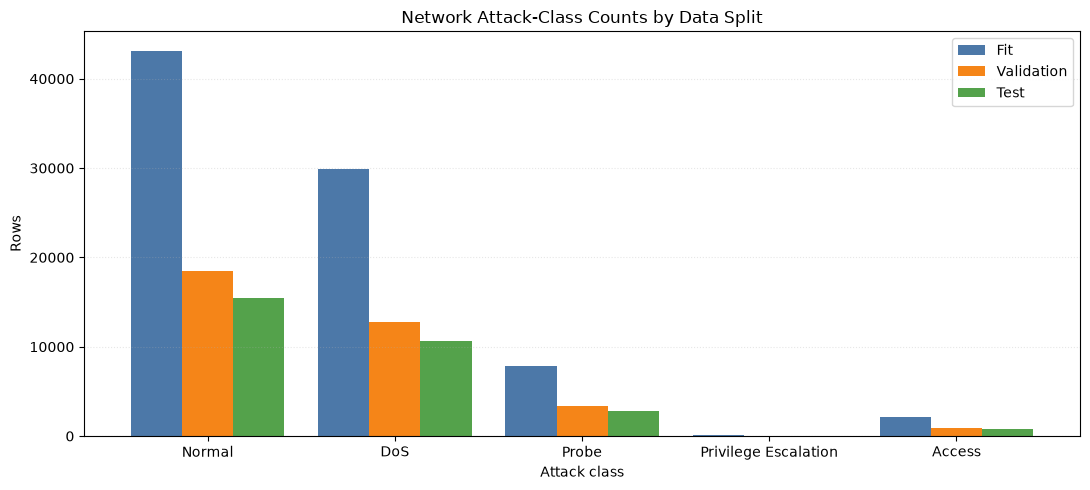

In [54]:
# Verify class proportions across the HTB-derived data partitions.
# Personal notebook addition (not in HTB)

network_split_counts = pd.DataFrame({
    "Fit": network_fit_y.value_counts(),
    "Validation": network_val_y.value_counts(),
    "Test": network_test_y.value_counts()
}).reindex(range(5), fill_value=0)

network_split_counts.index = [
    "Normal",
    "DoS",
    "Probe",
    "Privilege Escalation",
    "Access"
]

ax = network_split_counts.plot(
    kind="bar",
    figsize=(11, 5),
    color=["#4C78A8", "#F58518", "#54A24B"],
    width=0.82
)

ax.set_title("Network Attack-Class Counts by Data Split")
ax.set_xlabel("Attack class")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

## Validate partitions before fitting the forest

The split diagnostics show that the class composition is preserved across fit, validation, and test data. That is a prerequisite for interpreting per-class metrics: a rare class should be difficult because it is rare, not because the split omitted it.

The random forest now learns an ensemble of bootstrapped decision trees with randomized feature subsets. Validation performance is used for model inspection and tuning decisions; the test partition remains a final check. Feature importance will provide a first explanation of which traffic measurements drive the ensemble’s decisions.


,Validation Value
Accuracy,0.9949
Weighted Precision,0.9948
Weighted Recall,0.9949
Weighted F1,0.9948
Macro Precision,0.9623
Macro Recall,0.8755
Macro F1,0.9067


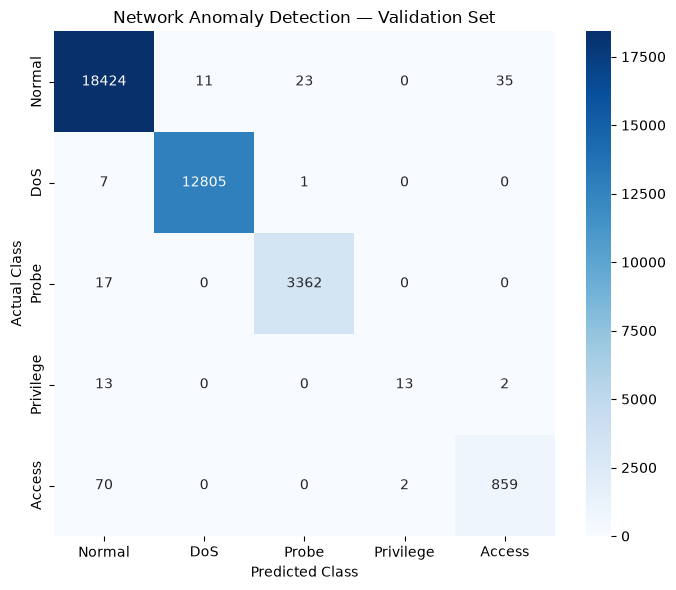

Validation classification report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     18493
         DoS       1.00      1.00      1.00     12813
       Probe       0.99      0.99      0.99      3379
   Privilege       0.87      0.46      0.60        28
      Access       0.96      0.92      0.94       931

    accuracy                           0.99     35644
   macro avg       0.96      0.88      0.91     35644
weighted avg       0.99      0.99      0.99     35644



In [55]:
# HTB lesson random-forest training and validation workflow adapted with
# network_ names, parallel training, and additional macro metrics.
# HTB's estimator, weighted metrics, confusion matrix, and classification
# report are retained.

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

network_class_labels = ["Normal", "DoS", "Probe", "Privilege", "Access"]
network_class_ids = list(range(len(network_class_labels)))

network_rf_model = RandomForestClassifier(
    random_state=1337,
    n_jobs=-1,
)

network_rf_model.fit(network_fit_X, network_fit_y)

network_val_predictions = network_rf_model.predict(network_val_X)

network_validation_metrics = pd.DataFrame(
    {
        "Accuracy": [
            accuracy_score(network_val_y, network_val_predictions)
        ],
        "Weighted Precision": [
            precision_score(
                network_val_y,
                network_val_predictions,
                average="weighted",
                zero_division=0,
            )
        ],
        "Weighted Recall": [
            recall_score(
                network_val_y,
                network_val_predictions,
                average="weighted",
                zero_division=0,
            )
        ],
        "Weighted F1": [
            f1_score(
                network_val_y,
                network_val_predictions,
                average="weighted",
                zero_division=0,
            )
        ],
        "Macro Precision": [
            precision_score(
                network_val_y,
                network_val_predictions,
                average="macro",
                zero_division=0,
            )
        ],
        "Macro Recall": [
            recall_score(
                network_val_y,
                network_val_predictions,
                average="macro",
                zero_division=0,
            )
        ],
        "Macro F1": [
            f1_score(
                network_val_y,
                network_val_predictions,
                average="macro",
                zero_division=0,
            )
        ],
    }
).T.rename(columns={0: "Validation Value"})

display(network_validation_metrics.round(4))

network_val_confusion = confusion_matrix(
    network_val_y,
    network_val_predictions,
    labels=network_class_ids,
)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    network_val_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=network_class_labels,
    yticklabels=network_class_labels,
    ax=ax,
)

ax.set_title("Network Anomaly Detection — Validation Set")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

print("Validation classification report:")
print(
    classification_report(
        network_val_y,
        network_val_predictions,
        labels=network_class_ids,
        target_names=network_class_labels,
        zero_division=0,
    )
)

,Test Value
Accuracy,0.9952
Weighted Precision,0.9951
Weighted Recall,0.9952
Weighted F1,0.9952
Macro Precision,0.9113
Macro Recall,0.8836
Macro F1,0.8964


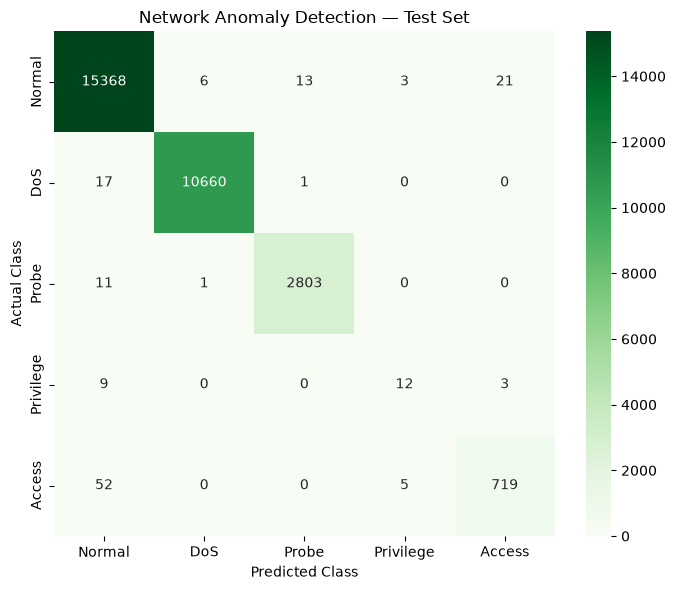

Test classification report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     15411
         DoS       1.00      1.00      1.00     10678
       Probe       1.00      1.00      1.00      2815
   Privilege       0.60      0.50      0.55        24
      Access       0.97      0.93      0.95       776

    accuracy                           1.00     29704
   macro avg       0.91      0.88      0.90     29704
weighted avg       1.00      1.00      1.00     29704



In [56]:
# HTB lesson held-out test evaluation adapted with network_ names, macro
# metrics, and zero-division safeguards.
# HTB's weighted metrics, confusion matrix, and classification report are
# retained.

network_test_predictions = network_rf_model.predict(network_test_X)

network_test_metrics = pd.DataFrame(
    {
        "Accuracy": [
            accuracy_score(network_test_y, network_test_predictions)
        ],
        "Weighted Precision": [
            precision_score(
                network_test_y,
                network_test_predictions,
                average="weighted",
                zero_division=0,
            )
        ],
        "Weighted Recall": [
            recall_score(
                network_test_y,
                network_test_predictions,
                average="weighted",
                zero_division=0,
            )
        ],
        "Weighted F1": [
            f1_score(
                network_test_y,
                network_test_predictions,
                average="weighted",
                zero_division=0,
            )
        ],
        "Macro Precision": [
            precision_score(
                network_test_y,
                network_test_predictions,
                average="macro",
                zero_division=0,
            )
        ],
        "Macro Recall": [
            recall_score(
                network_test_y,
                network_test_predictions,
                average="macro",
                zero_division=0,
            )
        ],
        "Macro F1": [
            f1_score(
                network_test_y,
                network_test_predictions,
                average="macro",
                zero_division=0,
            )
        ],
    }
).T.rename(columns={0: "Test Value"})

display(network_test_metrics.round(4))

network_test_confusion = confusion_matrix(
    network_test_y,
    network_test_predictions,
    labels=network_class_ids,
)

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    network_test_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=network_class_labels,
    yticklabels=network_class_labels,
    ax=ax,
)

ax.set_title("Network Anomaly Detection — Test Set")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

print("Test classification report:")
print(
    classification_report(
        network_test_y,
        network_test_predictions,
        labels=network_class_ids,
        target_names=network_class_labels,
        zero_division=0,
    )
)

,Feature,Importance
0,src_bytes,0.131229
1,same_srv_rate,0.068134
2,count,0.063663
3,dst_host_diff_srv_rate,0.057894
4,dst_bytes,0.057586
5,dst_host_srv_serror_rate,0.051101
6,serror_rate,0.042472
7,dst_host_same_srv_rate,0.042367
8,diff_srv_rate,0.041787
9,dst_host_serror_rate,0.036171


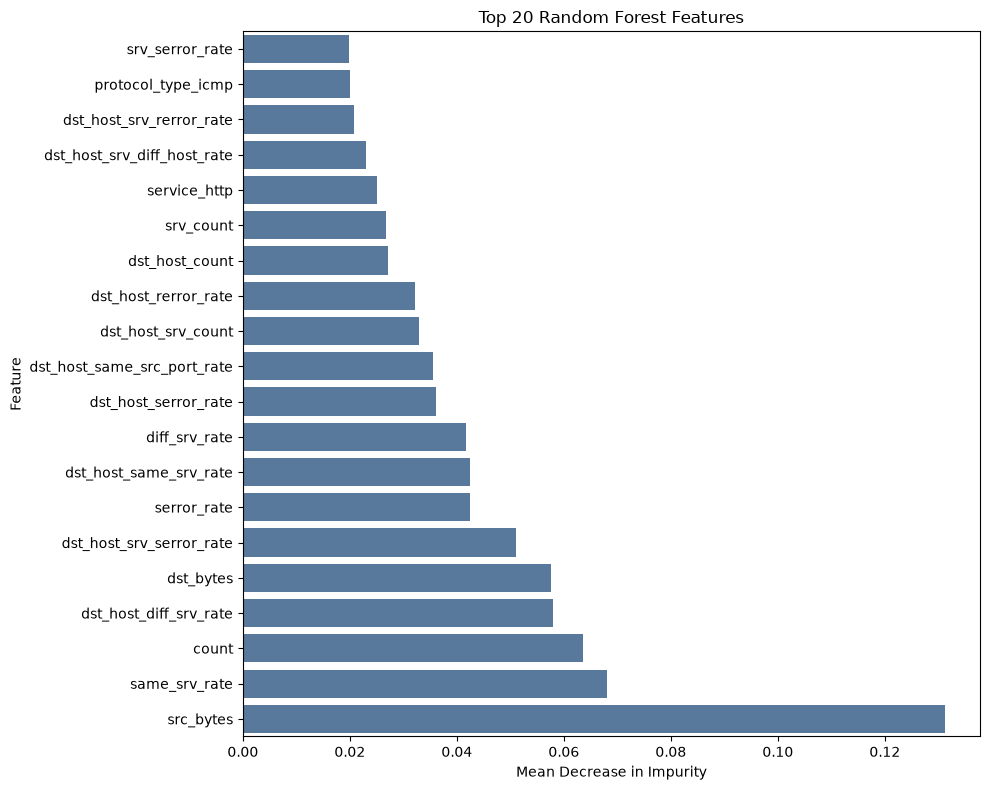

In [57]:
# Personal notebook addition (not in HTB): inspect RandomForest feature
# importances after HTB's model training.

network_feature_importance = (
    pd.DataFrame(
        {
            "Feature": network_train_set.columns,
            "Importance": network_rf_model.feature_importances_,
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(network_feature_importance.head(20).round(6))

network_top_features = (
    network_feature_importance.head(20)
    .sort_values("Importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=network_top_features,
    x="Importance",
    y="Feature",
    color="#4C78A8",
    ax=ax,
)

ax.set_title("Top 20 Random Forest Features")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

In [58]:
# HTB lesson model-persistence step adapted to this notebook's namespaced
# model and filename.
# Reload-prediction and SHA-256 verification are personal reproducibility
# safeguards.

from pathlib import Path
import hashlib
import joblib
import numpy as np

network_model_path = Path("network_anomaly_detection_model.joblib")

joblib.dump(network_rf_model, network_model_path)

network_loaded_model = joblib.load(network_model_path)

network_reload_sample = network_test_X.head(1_000)

original_predictions = network_rf_model.predict(network_reload_sample)
reloaded_predictions = network_loaded_model.predict(network_reload_sample)

assert np.array_equal(original_predictions, reloaded_predictions)

network_model_sha256 = hashlib.sha256(
    network_model_path.read_bytes()
).hexdigest()

print(f"Model saved to: {network_model_path}")
print(f"Verified predictions on {len(network_reload_sample):,} rows.")
print(f"SHA-256: {network_model_sha256}")

Model saved to: network_anomaly_detection_model.joblib
Verified predictions on 1,000 rows.
SHA-256: d42258c5ebd1e27de4aee2c1038ac1d18f06c5ee032905f8e38f36cdadbd84d1


## Network case study synthesis

The random forest performs strongly on aggregate: validation weighted accuracy/F1 are approximately 0.9949/0.9948, and test weighted accuracy/F1 are approximately 0.9952/0.9952. The macro recall is lower—about 0.8755 on validation and 0.8836 on test—because the rare Privilege class is much harder to detect than the dominant classes. This is precisely why weighted results and macro results belong together.

The leading features (`src_bytes`, `same_srv_rate`, `count`, `dst_host_diff_srv_rate`, and `dst_bytes`) connect the model to recognizable traffic behavior. Saving and reloading the artifact produces identical predictions for held-out rows, which closes the loop from training to reproducible inference. We now move from tabular traffic to image-like representations of executable bytes.

# Malware image classification: learn from byteplot structure

The Malimg dataset contains 9,339 grayscale PNG images across 25 malware families. Each image is a byteplot derived from a Portable Executable: pixel intensity corresponds to a byte value, so horizontal and vertical structure can expose packing, code, data, and other family-level regularities without executing the original binary. This is a static-analysis framing, not a claim that images contain every signal required for malware triage.

The workflow will verify the image manifest and class balance, create a reproducible train/test split, build ImageFolder/DataLoader pipelines, audit for duplicate content, and use a pretrained ResNet50 transfer-learning model. Validation monitoring, checkpointing, early stopping, and final untouched-test evaluation make the deep-learning experiment comparable in discipline to the tabular cases.

In [59]:
# HTB lesson download-and-extract commands adapted for idempotent local
# notebook execution.
# Personal modifications: reuse the existing dataset or archive and verify the
# extracted directory.

from pathlib import Path
import zipfile
import requests

malware_dataset_url = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "ikrambenabd/malimg-original"
)

malware_archive_path = Path("malimg.zip")
malware_dataset_dir = Path("malimg_paper_dataset_imgs")

if (
    malware_dataset_dir.is_dir()
    and any(malware_dataset_dir.rglob("*.png"))
):
    print(f"Dataset already available: {malware_dataset_dir}")
else:
    if not malware_archive_path.exists():
        response = requests.get(
            malware_dataset_url,
            timeout=60
        )
        response.raise_for_status()
        malware_archive_path.write_bytes(response.content)
        print(f"Downloaded: {malware_archive_path}")
    else:
        print(f"Using existing archive: {malware_archive_path}")

    with zipfile.ZipFile(malware_archive_path) as archive:
        archive.extractall(".")

    candidate_dirs = [
        path
        for path in Path(".").rglob("malimg_paper_dataset_imgs")
        if path.is_dir()
    ]

    if len(candidate_dirs) != 1:
        raise FileNotFoundError(
            "Could not uniquely locate malimg_paper_dataset_imgs."
        )

    malware_dataset_dir = candidate_dirs[0]
    print(f"Dataset ready: {malware_dataset_dir}")

Dataset already available: malimg_paper_dataset_imgs


In [60]:
# Personal notebook addition (not in HTB): build a file-level manifest and
# validate the documented dataset footprint.

import pandas as pd

malware_image_records = []

for family_dir in sorted(malware_dataset_dir.iterdir()):
    if not family_dir.is_dir():
        continue

    for image_path in sorted(family_dir.rglob("*.png")):
        malware_image_records.append(
            {
                "family": family_dir.name,
                "filename": image_path.name,
                "path": str(image_path),
                "size_bytes": image_path.stat().st_size,
            }
        )

malware_image_manifest = pd.DataFrame(malware_image_records)

if malware_image_manifest.empty:
    raise ValueError("No PNG images were found in the malware dataset.")

malware_family_summary = (
    malware_image_manifest
    .groupby("family", as_index=False)
    .agg(
        image_count=("path", "size"),
        total_bytes=("size_bytes", "sum"),
    )
    .sort_values(
        ["image_count", "family"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

assert len(malware_image_manifest) == 9339
assert malware_family_summary["family"].nunique() == 25

print(f"Images: {len(malware_image_manifest):,}")
print(f"Families: {malware_family_summary['family'].nunique()}")
print(f"Total bytes: {malware_image_manifest['size_bytes'].sum():,}")

display(malware_family_summary)

Images: 9,339
Families: 25
Total bytes: 1,175,659,711


,family,image_count,total_bytes
0,Allaple.A,2949,198325884
1,Allaple.L,1591,85024391
2,Yuner.A,800,267207200
3,Instantaccess,431,70380792
4,VB.AT,408,124077381
5,Fakerean,381,37958915
6,Lolyda.AA1,213,3388097
7,C2LOP.gen!g,200,90302725
8,Alueron.gen!J,198,16863359
9,Lolyda.AA2,184,2894139


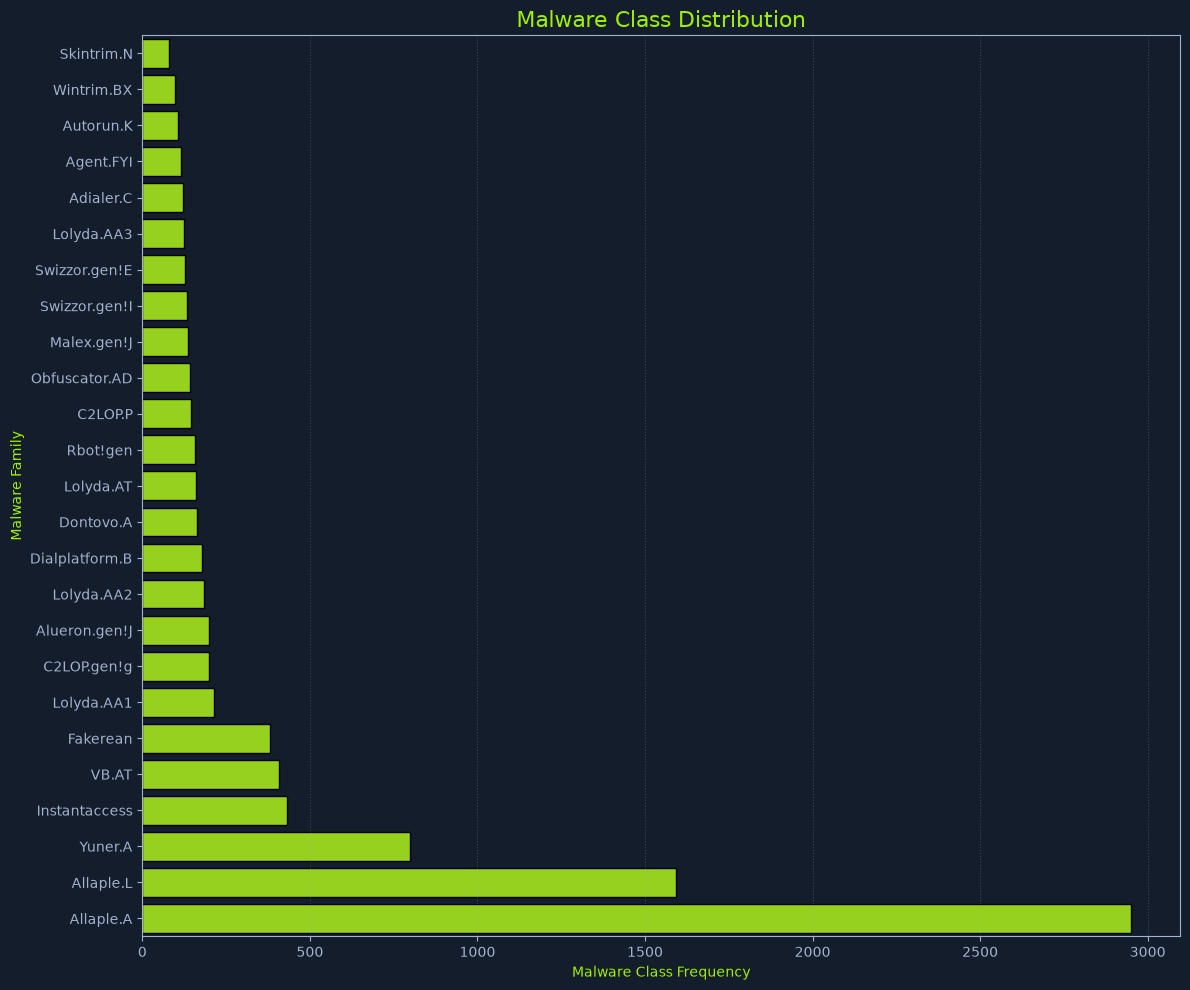

In [61]:
# Reproduce the HTB class-distribution visualization using the notebook
# manifest.
# Adapted from HTB lesson content; personal modifications follow:
# - Uses malware_family_summary generated in cell [60].
# - Adds deterministic sorting and explicit figure/axes formatting.
# - Adds grid and readability styling.

import matplotlib.pyplot as plt
import seaborn as sns

htb_green = "#9FEF00"
node_black = "#141D2B"
hacker_grey = "#A4B1CD"

malware_plot_data = (
    malware_family_summary
    .sort_values("image_count", ascending=True)
)

fig, ax = plt.subplots(
    figsize=(12, 10),
    facecolor=node_black,
)

ax.set_facecolor(node_black)

sns.barplot(
    data=malware_plot_data,
    x="image_count",
    y="family",
    color=htb_green,
    edgecolor="black",
    ax=ax,
)

ax.set_title(
    "Malware Class Distribution",
    color=htb_green,
    fontsize=16,
)

ax.set_xlabel(
    "Malware Class Frequency",
    color=htb_green,
)

ax.set_ylabel(
    "Malware Family",
    color=htb_green,
)

ax.tick_params(
    axis="x",
    colors=hacker_grey,
)

ax.tick_params(
    axis="y",
    colors=hacker_grey,
)

for spine in ax.spines.values():
    spine.set_color(hacker_grey)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.25,
    color=hacker_grey,
)

plt.tight_layout()
plt.show()

## Establish the image population before training

The manifest confirms the expected 9,339 image files and 25 family labels. Class counts and representative image grids show both the imbalance problem and the visual premise of the dataset: families can exhibit recurring byteplot textures, but the available number of examples varies substantially by class.

The next step is not yet model fitting. We first create the lesson’s 80/20 train/test partition and make the image transformations and loader behavior explicit. On a local macOS runtime, the loader is configured conservatively (`num_workers=0`) to favor reproducibility and predictable process behavior.


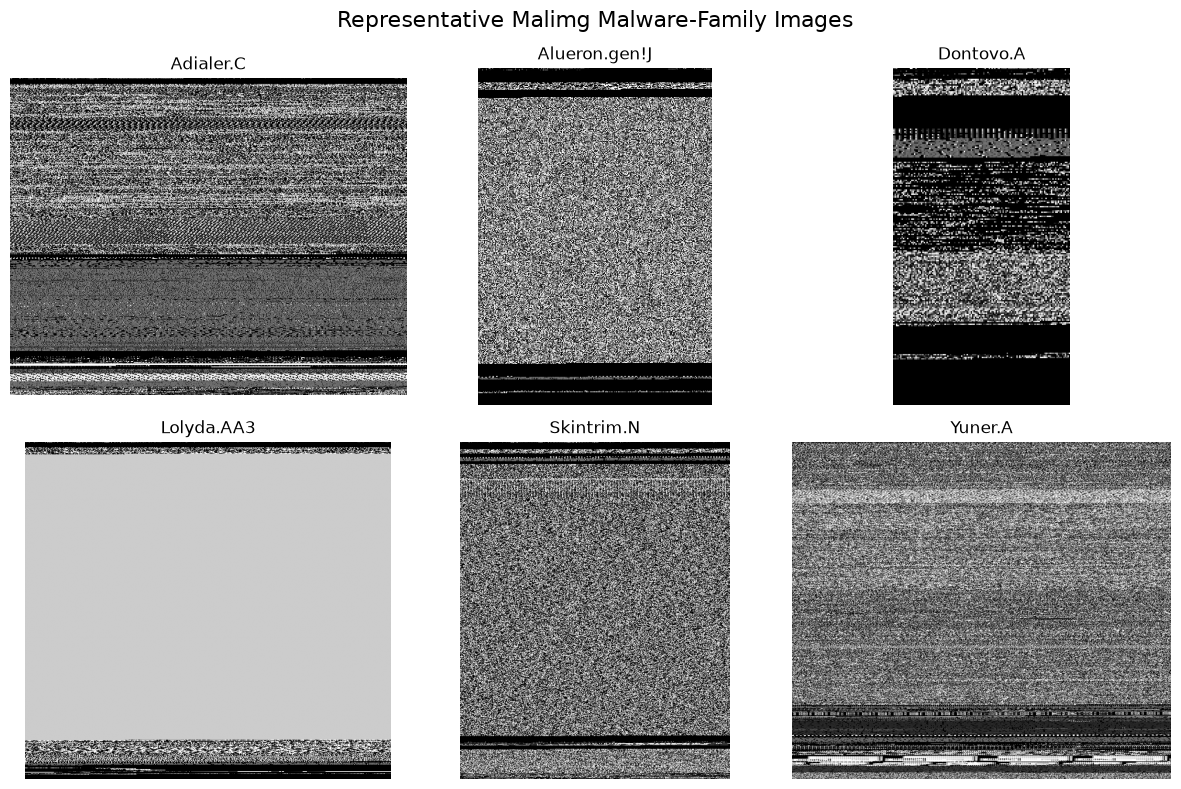

In [62]:
# Display representative malware images from the manifest without loading
# executable binaries.
# Personal notebook addition (not in HTB)

import numpy as np
import matplotlib.pyplot as plt

sample_positions = np.linspace(
    0,
    len(malware_family_summary) - 1,
    num=6,
    dtype=int,
)

sample_families = (
    malware_family_summary
    .sort_values("family")
    .iloc[sample_positions]["family"]
    .tolist()
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

for ax, family in zip(axes.flat, sample_families):
    sample_path = (
        malware_image_manifest.loc[
            malware_image_manifest["family"] == family,
            "path",
        ]
        .sort_values()
        .iloc[0]
    )

    image_array = plt.imread(sample_path)

    if image_array.ndim == 3:
        image_array = image_array[..., 0]

    ax.imshow(
        image_array,
        cmap="gray",
    )

    ax.set_title(family)
    ax.axis("off")

fig.suptitle(
    "Representative Malimg Malware-Family Images",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [63]:
# Create a reproducible 80/20 Malimg train/test split without overwriting an
# existing split.
# HTB lesson workflow adapted: preserves its 80/20 ratio and empty validation
# set; adds re-run safety and verification.

from pathlib import Path

try:
    import splitfolders
except ImportError as error:
    raise ImportError(
        "Install split-folders once in the ai environment: "
        "python -m pip install split-folders"
    ) from error


MALWARE_TRAIN_RATIO = 0.80
MALWARE_TEST_RATIO = 1 - MALWARE_TRAIN_RATIO

malware_split_source_dir = Path(malware_dataset_dir)
malware_split_dir = Path("malimg_split_80_20")

malware_train_dir = malware_split_dir / "train"
malware_test_dir = malware_split_dir / "test"
malware_val_dir = malware_split_dir / "val"


def count_malware_pngs(directory):
    if not directory.is_dir():
        return 0

    return sum(
        path.is_file()
        for path in directory.rglob("*.png")
    )


malware_source_count = count_malware_pngs(
    malware_split_source_dir
)

if malware_source_count == 0:
    raise FileNotFoundError(
        f"No PNG images found in: {malware_split_source_dir}"
    )


if malware_split_dir.exists():
    malware_train_count = count_malware_pngs(malware_train_dir)
    malware_test_count = count_malware_pngs(malware_test_dir)
    malware_val_count = count_malware_pngs(malware_val_dir)

    if (
        malware_train_count + malware_test_count
        == malware_source_count
        and malware_val_count == 0
    ):
        print(
            "Existing split is valid; skipping split creation."
        )
    else:
        raise RuntimeError(
            f"{malware_split_dir} already exists but is incomplete "
            "or does not match the source dataset. Inspect it manually "
            "before deleting, renaming, or recreating it."
        )

else:
    splitfolders.ratio(
        input=str(malware_split_source_dir),
        output=str(malware_split_dir),
        seed=1337,
        ratio=(
            MALWARE_TRAIN_RATIO,
            0.0,
            MALWARE_TEST_RATIO
        ),
        group_prefix=None,
        move=False,
    )

    malware_train_count = count_malware_pngs(malware_train_dir)
    malware_test_count = count_malware_pngs(malware_test_dir)
    malware_val_count = count_malware_pngs(malware_val_dir)


malware_split_summary = pd.DataFrame(
    {
        "PNG files": [
            malware_source_count,
            malware_train_count,
            malware_test_count,
            malware_val_count,
        ]
    },
    index=[
        "Source dataset",
        "Training split",
        "Test split",
        "Validation split",
    ],
)

display(malware_split_summary)

assert (
    malware_train_count + malware_test_count
    == malware_source_count
)
assert malware_val_count == 0

Existing split is valid; skipping split creation.


,PNG files
Source dataset,9339
Training split,7459
Test split,1880
Validation split,0


In [64]:
# Build Malimg ImageFolder datasets and stable local DataLoaders.
# HTB lesson workflow adapted: retains Resize → ToTensor → Normalize; uses
# smaller batches and zero workers for local macOS/Jupyter stability.

import torch

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder


MALWARE_IMAGE_SIZE = (75, 75)
MALWARE_TRAIN_BATCH_SIZE = 64
MALWARE_TEST_BATCH_SIZE = 64
MALWARE_NUM_WORKERS = 0

malware_normalize_mean = [
    0.485,
    0.456,
    0.406,
]

malware_normalize_std = [
    0.229,
    0.224,
    0.225,
]

malware_image_transform = transforms.Compose([
    transforms.Resize(MALWARE_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=malware_normalize_mean,
        std=malware_normalize_std,
    ),
])

malware_train_dataset = ImageFolder(
    root=str(malware_train_dir),
    transform=malware_image_transform,
)

malware_test_dataset = ImageFolder(
    root=str(malware_test_dir),
    transform=malware_image_transform,
)

assert (
    malware_train_dataset.classes
    == malware_test_dataset.classes
)

malware_class_names = malware_train_dataset.classes
malware_class_count = len(malware_class_names)

assert malware_class_count == 25

malware_loader_generator = torch.Generator().manual_seed(1337)

malware_train_loader = DataLoader(
    malware_train_dataset,
    batch_size=MALWARE_TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=MALWARE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=malware_loader_generator,
)

malware_test_loader = DataLoader(
    malware_test_dataset,
    batch_size=MALWARE_TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=MALWARE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(
    f"Classes: {malware_class_count}"
)

print(
    f"Training images: {len(malware_train_dataset):,}"
)

print(
    f"Test images: {len(malware_test_dataset):,}"
)

print(
    f"Training batches: {len(malware_train_loader):,}"
)

print(
    f"Test batches: {len(malware_test_loader):,}"
)

display(
    pd.DataFrame(
        {
            "Class index": range(malware_class_count),
            "Malware family": malware_class_names,
        }
    )
)

Classes: 25
Training images: 7,459
Test images: 1,880
Training batches: 117
Test batches: 30


,Class index,Malware family
0,0,Adialer.C
1,1,Agent.FYI
2,2,Allaple.A
3,3,Allaple.L
4,4,Alueron.gen!J
5,5,Autorun.K
6,6,C2LOP.P
7,7,C2LOP.gen!g
8,8,Dialplatform.B
9,9,Dontovo.A


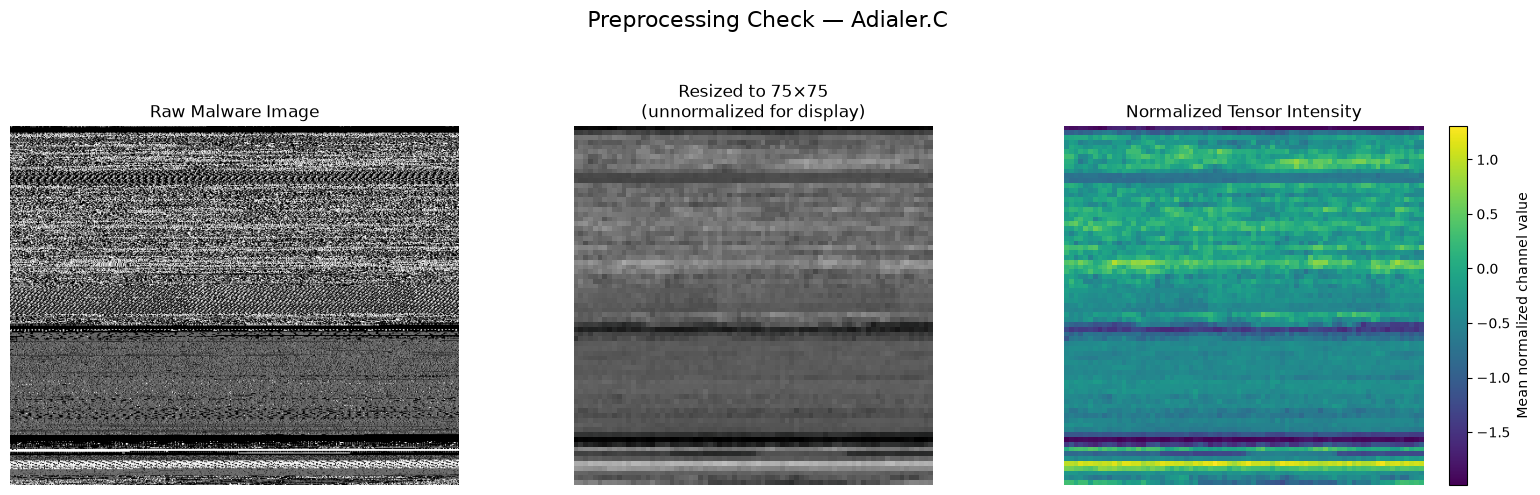

Family: Adialer.C
File: 000bde2e9a94ba41c0c111ffd80647c2.png
Tensor shape: (3, 75, 75)
Tensor range: -2.118 to 1.507


In [65]:
# Validate the Malimg preprocessing pipeline on one training example.
# HTB-derived inspection view; this adaptation correctly visualizes the
# normalized tensor and reports its shape and class.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


malware_sample_index = 0

malware_sample_path, malware_manifest_label = (
    malware_train_dataset.samples[
        malware_sample_index
    ]
)

malware_sample_tensor, malware_loader_label = (
    malware_train_dataset[
        malware_sample_index
    ]
)

assert malware_manifest_label == malware_loader_label

malware_sample_family = malware_class_names[
    malware_loader_label
]

with Image.open(
    Path(malware_sample_path)
) as malware_raw_image:
    malware_raw_grayscale = np.array(
        malware_raw_image.convert("L")
    )

malware_mean_tensor = torch.tensor(
    malware_normalize_mean
).view(3, 1, 1)

malware_std_tensor = torch.tensor(
    malware_normalize_std
).view(3, 1, 1)

malware_restored_tensor = (
    malware_sample_tensor
    * malware_std_tensor
    + malware_mean_tensor
).clamp(0, 1)

malware_normalized_intensity = (
    malware_sample_tensor
    .mean(dim=0)
    .numpy()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)

axes[0].imshow(
    malware_raw_grayscale,
    cmap="gray",
)

axes[0].set_title(
    "Raw Malware Image"
)

axes[1].imshow(
    malware_restored_tensor
    .permute(1, 2, 0)
    .numpy()
)

axes[1].set_title(
    "Resized to 75×75\n(unnormalized for display)"
)

normalized_plot = axes[2].imshow(
    malware_normalized_intensity,
    cmap="viridis",
)

axes[2].set_title(
    "Normalized Tensor Intensity"
)

fig.colorbar(
    normalized_plot,
    ax=axes[2],
    label="Mean normalized channel value",
)

for axis in axes:
    axis.axis("off")

fig.suptitle(
    f"Preprocessing Check — {malware_sample_family}",
    fontsize=16,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.92]
)

plt.show()

print(
    f"Family: {malware_sample_family}"
)

print(
    f"File: {Path(malware_sample_path).name}"
)

print(
    f"Tensor shape: {tuple(malware_sample_tensor.shape)}"
)

print(
    f"Tensor range: "
    f"{malware_sample_tensor.min():.3f} to "
    f"{malware_sample_tensor.max():.3f}"
)

## Convert byteplots into controlled model inputs

Images are resized to 75×75, converted to tensors, and normalized with ImageNet statistics so that the pretrained backbone receives inputs in the range it expects. The training/test split contains 7,459 and 1,880 images respectively, with no separate validation set in the original lesson split.

The sample-transform view makes the preprocessing concrete, while the class-coverage and proportion checks ensure that the directory structure translated into loaders as intended. The next audit adds two safeguards that are especially important for image datasets: duplicate-content detection and a profile of image dimensions, intensity, and family-level quality.


,source_count,train_count,test_count,split_total,train_fraction,test_fraction,train_fraction_delta,class_present_in_train,class_present_in_test
family,,,,,,,,,
Allaple.A,2949,2359,590,2949,0.799932,0.200068,-0.000068,True,True
Allaple.L,1591,1272,319,1591,0.799497,0.200503,-0.000503,True,True
Yuner.A,800,640,160,800,0.800000,0.200000,0.000000,True,True
Instantaccess,431,344,87,431,0.798144,0.201856,-0.001856,True,True
VB.AT,408,326,82,408,0.799020,0.200980,-0.000980,True,True
Fakerean,381,304,77,381,0.797900,0.202100,-0.002100,True,True
Lolyda.AA1,213,170,43,213,0.798122,0.201878,-0.001878,True,True
C2LOP.gen!g,200,160,40,200,0.800000,0.200000,0.000000,True,True
Alueron.gen!J,198,158,40,198,0.797980,0.202020,-0.002020,True,True


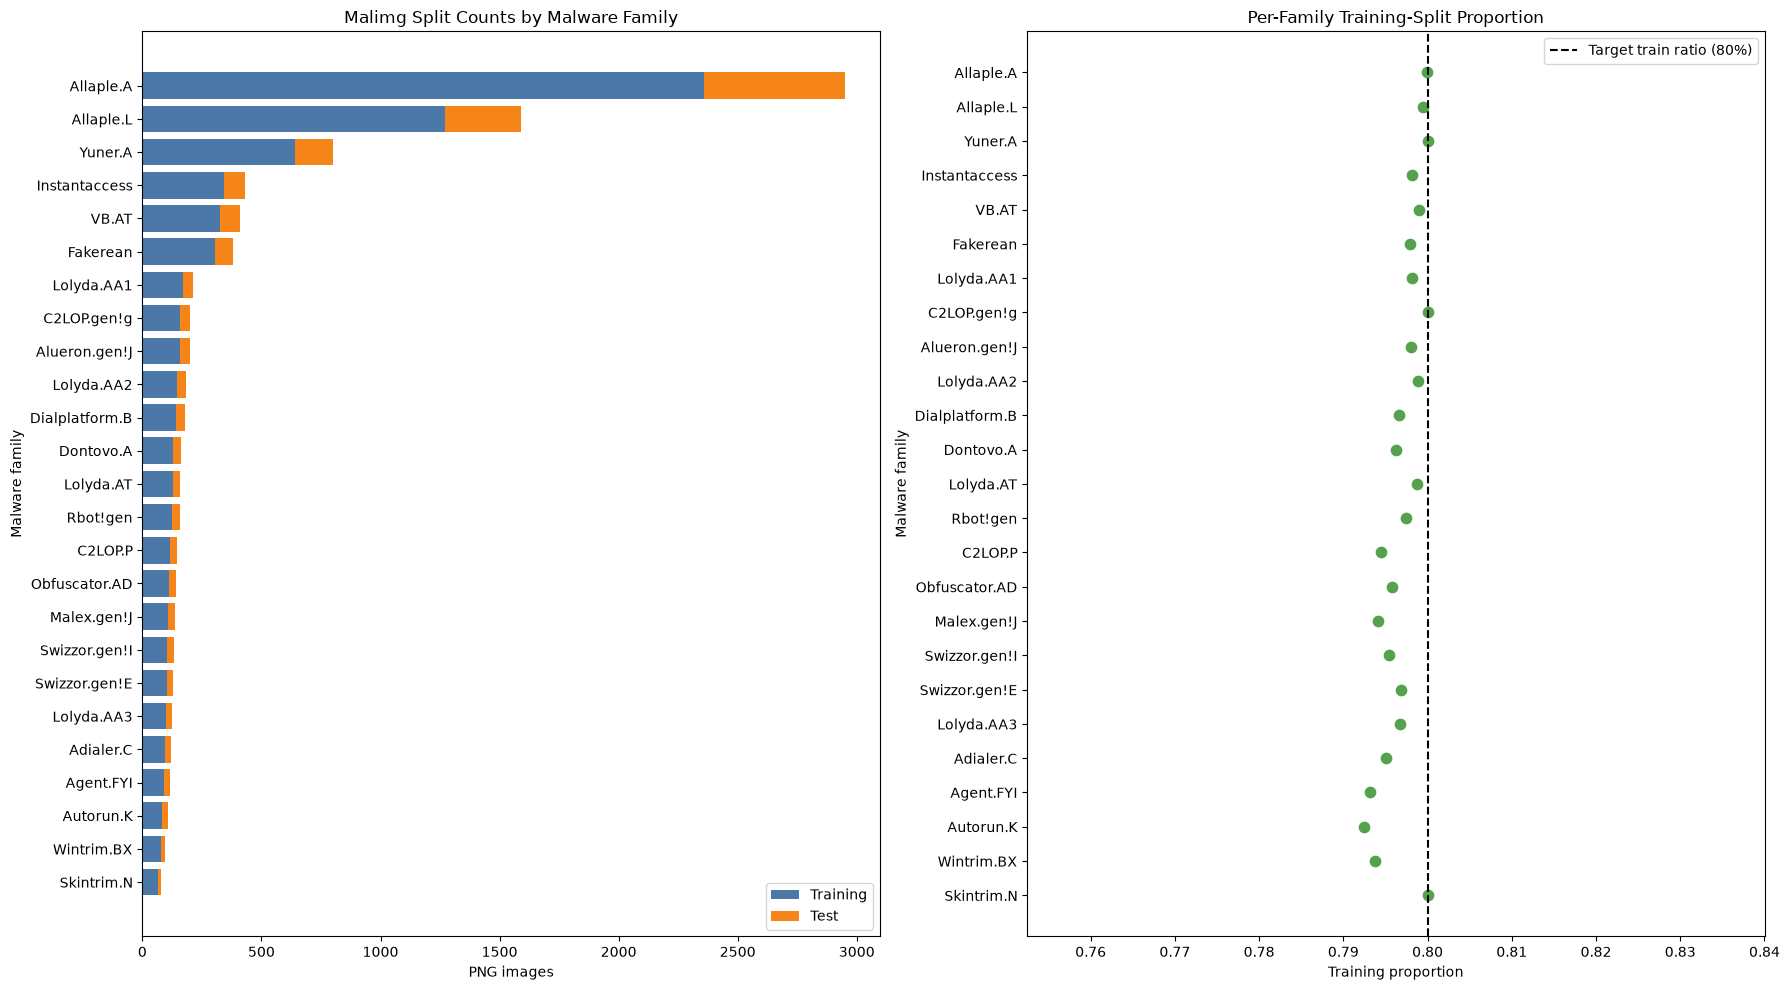

PASS: every malware family is represented in both training and test data.


In [66]:
# Audit the Malimg train/test split for class coverage, proportions, and
# imbalance.
# Personal notebook addition (not in HTB): validates the split before model
# development.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def count_pngs_by_family(dataset_root):
    counts = {}

    for family_dir in sorted(Path(dataset_root).iterdir()):
        if family_dir.is_dir():
            counts[family_dir.name] = sum(
                image_path.is_file()
                for image_path in family_dir.rglob("*.png")
            )

    return pd.Series(counts, dtype="int64")


malware_source_counts = (
    malware_image_manifest
    .groupby("family")["path"]
    .size()
    .astype("int64")
)

malware_train_counts = count_pngs_by_family(
    malware_train_dir
)

malware_test_counts = count_pngs_by_family(
    malware_test_dir
)

malware_split_families = sorted(
    set(malware_source_counts.index)
    | set(malware_train_counts.index)
    | set(malware_test_counts.index)
)

malware_split_audit = pd.DataFrame(
    index=malware_split_families
)

malware_split_audit.index.name = "family"

malware_split_audit["source_count"] = (
    malware_source_counts
    .reindex(malware_split_families)
    .fillna(0)
    .astype(int)
)

malware_split_audit["train_count"] = (
    malware_train_counts
    .reindex(malware_split_families)
    .fillna(0)
    .astype(int)
)

malware_split_audit["test_count"] = (
    malware_test_counts
    .reindex(malware_split_families)
    .fillna(0)
    .astype(int)
)

malware_split_audit["split_total"] = (
    malware_split_audit["train_count"]
    + malware_split_audit["test_count"]
)

malware_split_audit["train_fraction"] = (
    malware_split_audit["train_count"]
    / malware_split_audit["source_count"]
)

malware_split_audit["test_fraction"] = (
    malware_split_audit["test_count"]
    / malware_split_audit["source_count"]
)

malware_split_audit["train_fraction_delta"] = (
    malware_split_audit["train_fraction"]
    - MALWARE_TRAIN_RATIO
)

malware_split_audit["class_present_in_train"] = (
    malware_split_audit["train_count"] > 0
)

malware_split_audit["class_present_in_test"] = (
    malware_split_audit["test_count"] > 0
)

malware_invalid_split_rows = malware_split_audit.loc[
    (
        malware_split_audit["source_count"]
        != malware_split_audit["split_total"]
    )
    | ~malware_split_audit["class_present_in_train"]
    | ~malware_split_audit["class_present_in_test"]
]

if not malware_invalid_split_rows.empty:
    display(malware_invalid_split_rows)
    raise ValueError(
        "The Malimg split failed an integrity check. "
        "Inspect the displayed families before training."
    )

assert malware_split_audit["source_count"].sum() == malware_source_count
assert malware_split_audit["train_count"].sum() == malware_train_count
assert malware_split_audit["test_count"].sum() == malware_test_count

display(
    malware_split_audit
    .sort_values("source_count", ascending=False)
)

malware_split_plot_data = (
    malware_split_audit
    .sort_values("source_count", ascending=True)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 10),
)

axes[0].barh(
    malware_split_plot_data.index,
    malware_split_plot_data["train_count"],
    label="Training",
    color="#4C78A8",
)

axes[0].barh(
    malware_split_plot_data.index,
    malware_split_plot_data["test_count"],
    left=malware_split_plot_data["train_count"],
    label="Test",
    color="#F58518",
)

axes[0].set_title(
    "Malimg Split Counts by Malware Family"
)

axes[0].set_xlabel(
    "PNG images"
)

axes[0].set_ylabel(
    "Malware family"
)

axes[0].legend()

axes[1].scatter(
    malware_split_plot_data["train_fraction"],
    malware_split_plot_data.index,
    color="#54A24B",
    s=55,
)

axes[1].axvline(
    MALWARE_TRAIN_RATIO,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Target train ratio ({MALWARE_TRAIN_RATIO:.0%})",
)

axes[1].set_title(
    "Per-Family Training-Split Proportion"
)

axes[1].set_xlabel(
    "Training proportion"
)

axes[1].set_ylabel(
    "Malware family"
)

axes[1].set_xlim(
    max(
        0,
        malware_split_plot_data["train_fraction"].min() - 0.04,
    ),
    min(
        1,
        malware_split_plot_data["train_fraction"].max() + 0.04,
    ),
)

axes[1].legend()

plt.tight_layout()
plt.show()

print(
    "PASS: every malware family is represented in both "
    "training and test data."
)

In [67]:
# Re-hash every Malimg train/test image to check for exact cross-split
# duplicates.
# Personal notebook addition (not in HTB): performs a fresh leakage audit on
# every execution.

from pathlib import Path

import hashlib
import pandas as pd


def build_png_inventory(split_name, split_root):
    inventory_records = []

    for image_path in sorted(
        Path(split_root).rglob("*.png")
    ):
        inventory_records.append(
            {
                "split": split_name,
                "relative_path": str(
                    image_path.relative_to(split_root)
                ),
                "path": str(image_path),
            }
        )

    return pd.DataFrame(inventory_records)


def sha256_file(file_path, block_size=1_048_576):
    file_hash = hashlib.sha256()

    with open(file_path, "rb") as file_handle:
        for block in iter(
            lambda: file_handle.read(block_size),
            b"",
        ):
            file_hash.update(block)

    return file_hash.hexdigest()


malware_hash_manifest = pd.concat(
    [
        build_png_inventory(
            "train",
            malware_train_dir,
        ),
        build_png_inventory(
            "test",
            malware_test_dir,
        ),
    ],
    ignore_index=True,
)

print(
    "Fresh-hashing "
    f"{len(malware_hash_manifest):,} PNG files..."
)

for completed, row_index in enumerate(
    malware_hash_manifest.index,
    start=1,
):
    malware_hash_manifest.loc[
        row_index,
        "sha256",
    ] = sha256_file(
        malware_hash_manifest.loc[
            row_index,
            "path",
        ]
    )

    if completed % 1_000 == 0:
        print(
            f"Hashed {completed:,} files..."
        )

malware_hash_group_summary = (
    malware_hash_manifest
    .groupby("sha256", as_index=False)
    .agg(
        file_count=("relative_path", "size"),
        split_count=("split", "nunique"),
    )
)

malware_cross_split_hashes = (
    malware_hash_group_summary.loc[
        malware_hash_group_summary["split_count"] > 1,
        "sha256",
    ]
)

malware_cross_split_duplicates = (
    malware_hash_manifest.loc[
        malware_hash_manifest["sha256"].isin(
            malware_cross_split_hashes
        )
    ]
    .sort_values(
        ["sha256", "split", "relative_path"]
    )
)

malware_hash_audit_summary = pd.DataFrame(
    {
        "value": [
            len(malware_hash_manifest),
            malware_hash_manifest["sha256"].nunique(),
            len(malware_cross_split_hashes),
        ]
    },
    index=[
        "PNG files freshly hashed",
        "Unique exact file hashes",
        "Cross-split duplicate hash groups",
    ],
)

display(malware_hash_audit_summary)

if malware_cross_split_duplicates.empty:
    print(
        "PASS: no exact PNG content appears in both "
        "training and test sets."
    )
else:
    print(
        "WARNING: exact duplicate content was found across "
        "training and test sets."
    )

    display(
        malware_cross_split_duplicates
    )

Fresh-hashing 9,339 PNG files...
Hashed 1,000 files...
Hashed 2,000 files...
Hashed 3,000 files...
Hashed 4,000 files...
Hashed 5,000 files...
Hashed 6,000 files...
Hashed 7,000 files...
Hashed 8,000 files...
Hashed 9,000 files...


,value
PNG files freshly hashed,9339
Unique exact file hashes,8444
Cross-split duplicate hash groups,149


,split,relative_path,path,sha256
9324,test,Yuner.A/07afb20dda022eeb2c334ecdde65280b.png,malimg_split_80_20/test/Yuner.A/07afb20dda022e...,06aedd6cd73c3a6432efccc1fa5f2fd1599c0134b33afd...
9325,test,Yuner.A/07bf8b2cfd36c36e50fb46be9d81dc7b.png,malimg_split_80_20/test/Yuner.A/07bf8b2cfd36c3...,06aedd6cd73c3a6432efccc1fa5f2fd1599c0134b33afd...
7398,train,Yuner.A/07aa5297b80bf1072399e4e9b953827f.png,malimg_split_80_20/train/Yuner.A/07aa5297b80bf...,06aedd6cd73c3a6432efccc1fa5f2fd1599c0134b33afd...
7399,train,Yuner.A/07ad187f285af5a7de79d32418ec9705.png,malimg_split_80_20/train/Yuner.A/07ad187f285af...,06aedd6cd73c3a6432efccc1fa5f2fd1599c0134b33afd...
7400,train,Yuner.A/07b4202cc2631c3cf260a96dff3d9ea3.png,malimg_split_80_20/train/Yuner.A/07b4202cc2631...,06aedd6cd73c3a6432efccc1fa5f2fd1599c0134b33afd...
...,...,...,...,...
9180,test,Yuner.A/001dcd7215ee0691b4e2c1057da21c54.png,malimg_split_80_20/test/Yuner.A/001dcd7215ee06...,ff59c07e3ddac83398a4f743b296960ea19fa185d80db6...
6831,train,Yuner.A/0014c7fe1f032f7e59521b5e87385b95.png,malimg_split_80_20/train/Yuner.A/0014c7fe1f032...,ff59c07e3ddac83398a4f743b296960ea19fa185d80db6...
6832,train,Yuner.A/001500f5dd7559b3bfb2d80259c48de3.png,malimg_split_80_20/train/Yuner.A/001500f5dd755...,ff59c07e3ddac83398a4f743b296960ea19fa185d80db6...
6833,train,Yuner.A/001b1d0ed82432d2b245cd8c8bab7e40.png,malimg_split_80_20/train/Yuner.A/001b1d0ed8243...,ff59c07e3ddac83398a4f743b296960ea19fa185d80db6...


Using cached profiles for all training images.


,current_imagenet_mean,current_imagenet_std,training_data_mean,training_data_std
red,0.485,0.229,0.423714,0.332746
green,0.456,0.224,0.423714,0.332746
blue,0.406,0.225,0.423714,0.332746


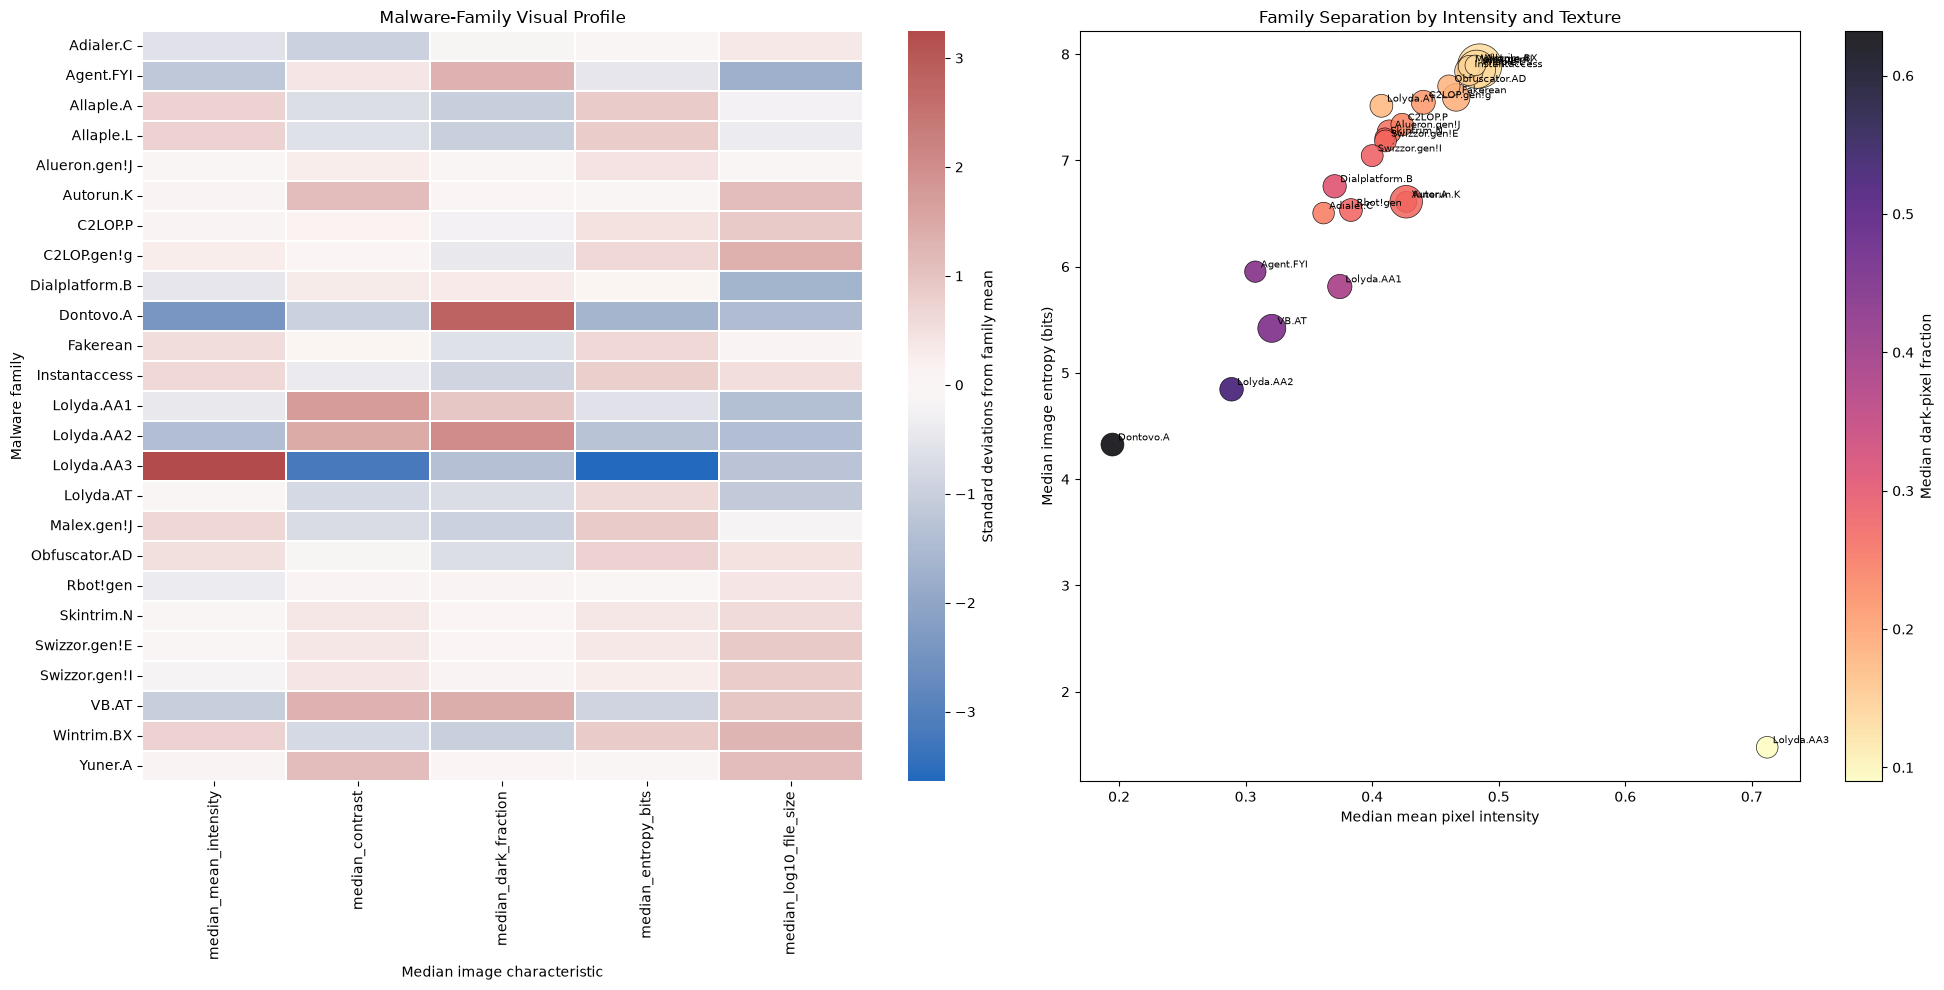

,family,image_count,median_mean_intensity,median_contrast,median_dark_fraction,median_entropy_bits,median_log10_file_size
2,Allaple.A,2359,0.484876,0.299738,0.128891,7.888104,4.800635
3,Allaple.L,1272,0.482405,0.301250,0.133296,7.857302,4.729703
24,Yuner.A,640,0.426860,0.343687,0.266919,6.610592,5.523758
11,Instantaccess,344,0.476359,0.306506,0.150497,7.837797,5.209244
22,VB.AT,326,0.320669,0.348980,0.444095,5.419103,5.438846
10,Fakerean,304,0.466361,0.317931,0.184988,7.592528,4.986467
12,Lolyda.AA1,170,0.374387,0.360214,0.384799,5.812672,4.189728
7,C2LOP.gen!g,160,0.440366,0.317417,0.210335,7.546577,5.653359
4,Alueron.gen!J,158,0.413453,0.323407,0.255203,7.268023,4.896149
13,Lolyda.AA2,147,0.288855,0.352630,0.524794,4.845873,4.183782


In [68]:
# Profile raw Malimg training images and compare family-level visual
# characteristics.
# Personal notebook addition (not in HTB): creates cached quality metrics and
# a pre-model representation audit.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

malware_audit_dir = Path("malimg_audit")
malware_audit_dir.mkdir(
    parents=True,
    exist_ok=True,
)

malware_profile_cache_path = (
    malware_audit_dir
    / "malimg_train_image_profile.csv"
)


def build_training_image_inventory(dataset_root):
    inventory_records = []

    for image_path in sorted(
        Path(dataset_root).rglob("*.png")
    ):
        file_stat = image_path.stat()

        inventory_records.append(
            {
                "relative_path": str(
                    image_path.relative_to(dataset_root)
                ),
                "family": image_path.parent.name,
                "path": str(image_path),
                "size_bytes": file_stat.st_size,
                "modified_ns": file_stat.st_mtime_ns,
            }
        )

    return pd.DataFrame(inventory_records)


def profile_grayscale_png(file_path):
    with Image.open(file_path) as image:
        grayscale_image = np.asarray(
            image.convert("L"),
            dtype=np.uint8,
        )

    if grayscale_image.size == 0:
        raise ValueError(
            f"Empty image encountered: {file_path}"
        )

    normalized_pixels = (
        grayscale_image.astype(np.float64)
        / 255.0
    )

    intensity_counts = np.bincount(
        grayscale_image.ravel(),
        minlength=256,
    )

    intensity_probabilities = (
        intensity_counts[
            intensity_counts > 0
        ]
        / grayscale_image.size
    )

    entropy_bits = -np.sum(
        intensity_probabilities
        * np.log2(intensity_probabilities)
    )

    return {
        "width": grayscale_image.shape[1],
        "height": grayscale_image.shape[0],
        "pixel_count": grayscale_image.size,
        "pixel_sum": normalized_pixels.sum(),
        "pixel_sum_squared": np.square(
            normalized_pixels
        ).sum(),
        "mean_intensity": normalized_pixels.mean(),
        "std_intensity": normalized_pixels.std(),
        "dark_fraction": (
            normalized_pixels <= 0.10
        ).mean(),
        "bright_fraction": (
            normalized_pixels >= 0.90
        ).mean(),
        "entropy_bits": entropy_bits,
    }


malware_profile_inventory = (
    build_training_image_inventory(
        malware_train_dir
    )
)

malware_profile_key_columns = [
    "relative_path",
    "size_bytes",
    "modified_ns",
]

malware_profile_metric_columns = [
    "width",
    "height",
    "pixel_count",
    "pixel_sum",
    "pixel_sum_squared",
    "mean_intensity",
    "std_intensity",
    "dark_fraction",
    "bright_fraction",
    "entropy_bits",
]

malware_profile_required_columns = (
    malware_profile_key_columns
    + malware_profile_metric_columns
)

if malware_profile_cache_path.exists():
    malware_profile_cache = pd.read_csv(
        malware_profile_cache_path
    )

    if set(
        malware_profile_required_columns
    ).issubset(
        malware_profile_cache.columns
    ):
        malware_profile_cache = (
            malware_profile_cache[
                malware_profile_required_columns
            ]
            .drop_duplicates(
                malware_profile_key_columns,
                keep="last",
            )
        )
    else:
        malware_profile_cache = pd.DataFrame(
            columns=malware_profile_required_columns
        )
else:
    malware_profile_cache = pd.DataFrame(
        columns=malware_profile_required_columns
    )

malware_train_image_profile = (
    malware_profile_inventory
    .merge(
        malware_profile_cache,
        on=malware_profile_key_columns,
        how="left",
        validate="one_to_one",
    )
)

malware_missing_profiles = (
    malware_train_image_profile["pixel_count"]
    .isna()
)

if malware_missing_profiles.any():
    print(
        "Profiling "
        f"{malware_missing_profiles.sum():,} new or changed "
        "training images..."
    )

    malware_profile_records = []

    for completed, row_index in enumerate(
        malware_train_image_profile.index[
            malware_missing_profiles
        ],
        start=1,
    ):
        profile_metrics = profile_grayscale_png(
            malware_train_image_profile.loc[
                row_index,
                "path",
            ]
        )

        profile_metrics["_row_index"] = row_index

        malware_profile_records.append(
            profile_metrics
        )

        if completed % 1_000 == 0:
            print(
                f"Profiled {completed:,} images..."
            )

    malware_profile_updates = (
        pd.DataFrame(
            malware_profile_records
        )
        .set_index("_row_index")
    )

    malware_train_image_profile.loc[
        malware_profile_updates.index,
        malware_profile_metric_columns,
    ] = malware_profile_updates[
        malware_profile_metric_columns
    ]

else:
    print(
        "Using cached profiles for all training images."
    )

if malware_train_image_profile[
    malware_profile_metric_columns
].isna().any().any():
    raise ValueError(
        "One or more training images were not fully profiled."
    )

malware_train_image_profile[
    malware_profile_key_columns
    + ["family"]
    + malware_profile_metric_columns
].to_csv(
    malware_profile_cache_path,
    index=False,
)

malware_total_pixel_count = (
    malware_train_image_profile["pixel_count"]
    .sum()
)

malware_training_pixel_mean = (
    malware_train_image_profile["pixel_sum"]
    .sum()
    / malware_total_pixel_count
)

malware_training_pixel_variance = (
    malware_train_image_profile[
        "pixel_sum_squared"
    ].sum()
    / malware_total_pixel_count
    - malware_training_pixel_mean ** 2
)

malware_training_pixel_std = np.sqrt(
    max(
        malware_training_pixel_variance,
        0,
    )
)

malware_normalization_audit = pd.DataFrame(
    {
        "current_imagenet_mean": (
            malware_normalize_mean
        ),
        "current_imagenet_std": (
            malware_normalize_std
        ),
        "training_data_mean": [
            malware_training_pixel_mean
        ] * 3,
        "training_data_std": [
            malware_training_pixel_std
        ] * 3,
    },
    index=["red", "green", "blue"],
)

display(
    malware_normalization_audit
)

malware_family_image_profile = (
    malware_train_image_profile
    .assign(
        log10_file_size=np.log10(
            malware_train_image_profile[
                "size_bytes"
            ]
        )
    )
    .groupby("family", as_index=False)
    .agg(
        image_count=("family", "size"),
        median_mean_intensity=(
            "mean_intensity",
            "median",
        ),
        median_contrast=(
            "std_intensity",
            "median",
        ),
        median_dark_fraction=(
            "dark_fraction",
            "median",
        ),
        median_entropy_bits=(
            "entropy_bits",
            "median",
        ),
        median_log10_file_size=(
            "log10_file_size",
            "median",
        ),
    )
)

malware_profile_features = [
    "median_mean_intensity",
    "median_contrast",
    "median_dark_fraction",
    "median_entropy_bits",
    "median_log10_file_size",
]

malware_profile_matrix = (
    malware_family_image_profile
    .set_index("family")[
        malware_profile_features
    ]
)

malware_profile_standard_deviation = (
    malware_profile_matrix
    .std(ddof=0)
    .replace(0, 1)
)

malware_profile_z_scores = (
    malware_profile_matrix
    - malware_profile_matrix.mean()
) / malware_profile_standard_deviation

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 10),
)

sns.heatmap(
    malware_profile_z_scores.sort_index(),
    cmap="vlag",
    center=0,
    linewidths=0.35,
    linecolor="white",
    cbar_kws={
        "label": "Standard deviations from family mean"
    },
    ax=axes[0],
)

axes[0].set_title(
    "Malware-Family Visual Profile"
)

axes[0].set_xlabel(
    "Median image characteristic"
)

axes[0].set_ylabel(
    "Malware family"
)

malware_scatter = axes[1].scatter(
    malware_family_image_profile[
        "median_mean_intensity"
    ],
    malware_family_image_profile[
        "median_entropy_bits"
    ],
    s=45 + 20 * np.sqrt(
        malware_family_image_profile[
            "image_count"
        ]
    ),
    c=malware_family_image_profile[
        "median_dark_fraction"
    ],
    cmap="magma_r",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
)

for family_row in (
    malware_family_image_profile
    .itertuples(index=False)
):
    axes[1].annotate(
        family_row.family,
        (
            family_row.median_mean_intensity,
            family_row.median_entropy_bits,
        ),
        xytext=(4, 3),
        textcoords="offset points",
        fontsize=7,
    )

axes[1].set_title(
    "Family Separation by Intensity and Texture"
)

axes[1].set_xlabel(
    "Median mean pixel intensity"
)

axes[1].set_ylabel(
    "Median image entropy (bits)"
)

fig.colorbar(
    malware_scatter,
    ax=axes[1],
    label="Median dark-pixel fraction",
)

plt.tight_layout()
plt.show()

display(
    malware_family_image_profile
    .sort_values(
        "image_count",
        ascending=False,
    )
)

In [69]:
# Create a deterministic validation subset from the existing Malimg training
# split.
# Personal notebook addition (not in HTB): preserves the untouched test set
# for final evaluation.

from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import (
    StratifiedShuffleSplit,
)
from torch.utils.data import (
    DataLoader,
    Subset,
)


MALWARE_VALIDATION_RATIO = 0.15
MALWARE_SPLIT_RANDOM_SEED = 1337

malware_training_targets = np.asarray(
    malware_train_dataset.targets
)

malware_validation_splitter = (
    StratifiedShuffleSplit(
        n_splits=1,
        test_size=MALWARE_VALIDATION_RATIO,
        random_state=MALWARE_SPLIT_RANDOM_SEED,
    )
)

malware_model_train_indices, malware_validation_indices = next(
    malware_validation_splitter.split(
        np.zeros(
            len(malware_training_targets)
        ),
        malware_training_targets,
    )
)

assert (
    len(
        np.intersect1d(
            malware_model_train_indices,
            malware_validation_indices,
        )
    )
    == 0
)

assert (
    len(malware_model_train_indices)
    + len(malware_validation_indices)
    == len(malware_train_dataset)
)

malware_model_train_dataset = Subset(
    malware_train_dataset,
    malware_model_train_indices,
)

malware_validation_dataset = Subset(
    malware_train_dataset,
    malware_validation_indices,
)

malware_model_train_loader = DataLoader(
    malware_model_train_dataset,
    batch_size=MALWARE_TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=MALWARE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=torch.Generator().manual_seed(
        MALWARE_SPLIT_RANDOM_SEED
    ),
)

malware_validation_loader = DataLoader(
    malware_validation_dataset,
    batch_size=MALWARE_TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=MALWARE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


def count_labels(label_values):
    return np.bincount(
        label_values,
        minlength=malware_class_count,
    )


malware_model_train_label_counts = count_labels(
    malware_training_targets[
        malware_model_train_indices
    ]
)

malware_validation_label_counts = count_labels(
    malware_training_targets[
        malware_validation_indices
    ]
)

malware_test_label_counts = count_labels(
    np.asarray(
        malware_test_dataset.targets
    )
)

assert np.all(
    malware_model_train_label_counts > 0
)

assert np.all(
    malware_validation_label_counts > 0
)

assert np.all(
    malware_test_label_counts > 0
)

malware_model_partition_summary = pd.DataFrame(
    {
        "image_count": [
            len(malware_model_train_dataset),
            len(malware_validation_dataset),
            len(malware_test_dataset),
        ],
        "share_of_full_dataset": [
            len(malware_model_train_dataset)
            / malware_source_count,
            len(malware_validation_dataset)
            / malware_source_count,
            len(malware_test_dataset)
            / malware_source_count,
        ],
    },
    index=[
        "Model training",
        "Validation",
        "Final test",
    ],
)

malware_validation_class_audit = pd.DataFrame(
    {
        "family": malware_class_names,
        "model_train_count": (
            malware_model_train_label_counts
        ),
        "validation_count": (
            malware_validation_label_counts
        ),
        "test_count": malware_test_label_counts,
    }
)

malware_validation_class_audit[
    "training_plus_validation_count"
] = (
    malware_validation_class_audit[
        "model_train_count"
    ]
    + malware_validation_class_audit[
        "validation_count"
    ]
)

malware_partition_manifest_records = []

for subset_name, subset_indices in [
    (
        "model_train",
        malware_model_train_indices,
    ),
    (
        "validation",
        malware_validation_indices,
    ),
]:
    for original_index in subset_indices:
        image_path, class_index = (
            malware_train_dataset.samples[
                int(original_index)
            ]
        )

        image_path = Path(image_path)

        malware_partition_manifest_records.append(
            {
                "subset": subset_name,
                "original_train_index": int(
                    original_index
                ),
                "relative_path": str(
                    image_path.relative_to(
                        malware_train_dir
                    )
                ),
                "family": malware_class_names[
                    class_index
                ],
            }
        )

malware_partition_manifest = pd.DataFrame(
    malware_partition_manifest_records
)

malware_partition_manifest.to_csv(
    malware_audit_dir
    / "malimg_model_train_validation_manifest.csv",
    index=False,
)

display(
    malware_model_partition_summary
)

display(
    malware_validation_class_audit
)

print(
    "Future model-training cells should use:\n"
    "- malware_model_train_loader\n"
    "- malware_validation_loader\n"
    "- malware_test_loader (final evaluation only)"
)

,image_count,share_of_full_dataset
Model training,6340,0.678874
Validation,1119,0.119820
Final test,1880,0.201306


,family,model_train_count,validation_count,test_count,training_plus_validation_count
0,Adialer.C,83,14,25,97
1,Agent.FYI,78,14,24,92
2,Allaple.A,2005,354,590,2359
3,Allaple.L,1081,191,319,1272
4,Alueron.gen!J,134,24,40,158
5,Autorun.K,71,13,22,84
6,C2LOP.P,99,17,30,116
7,C2LOP.gen!g,136,24,40,160
8,Dialplatform.B,120,21,36,141
9,Dontovo.A,110,19,33,129


Future model-training cells should use:
- malware_model_train_loader
- malware_validation_loader
- malware_test_loader (final evaluation only)


## Audit leakage and create a validation signal

The notebook performs a fresh SHA-256 audit of the train and test image bytes rather than relying on cached hashes. It also profiles image quality and family coverage, then creates a deterministic 85/15 validation partition inside the lesson’s training set. The official test set remains untouched until final evaluation, so early stopping and checkpoint selection do not optimize against the final benchmark.

With that split in place, the model is a transfer-learning experiment: a ResNet50 pretrained on ImageNet supplies a visual backbone, while a new head maps its 2,048-dimensional representation to the 25 malware families. The next cells define the model, training controls, and experiment configuration.


In [70]:
# Define the ResNet50 transfer-learning classifier used for Malimg family
# classification.
# HTB lesson content adapted for current torchvision: ResNet50_Weights.DEFAULT
# is the current equivalent of weights='DEFAULT', and the output size follows
# the dataset's 25 discovered families.

import torch
import torch.nn as nn
import torchvision.models as models

from torchvision.models import ResNet50_Weights


MALWARE_HIDDEN_LAYER_SIZE = 1000


class MalwareClassifier(nn.Module):
    def __init__(
        self,
        n_classes,
        weights=ResNet50_Weights.DEFAULT,
    ):
        super().__init__()

        self.resnet = models.resnet50(
            weights=weights
        )

        for parameter in self.resnet.parameters():
            parameter.requires_grad = False

        input_features = self.resnet.fc.in_features

        self.resnet.fc = nn.Sequential(
            nn.Linear(
                input_features,
                MALWARE_HIDDEN_LAYER_SIZE,
            ),
            nn.ReLU(),
            nn.Linear(
                MALWARE_HIDDEN_LAYER_SIZE,
                n_classes,
            ),
        )

    def forward(self, images):
        return self.resnet(images)


In [71]:
# Configure a reproducible, validation-aware Malimg experiment before any
# model is trained.
# Personal notebook addition (not in HTB): records deterministic settings,
# selects the best available device, and makes class weighting an explicit
# experiment choice.

import json
import platform
import random
import sys

from pathlib import Path

import numpy as np
import pandas as pd
import torch


MALWARE_EXPERIMENT_NAME = (
    "resnet50_frozen_baseline"
)
MALWARE_EXPERIMENT_SEED = 1337
MALWARE_MAX_EPOCHS = 10
MALWARE_LEARNING_RATE = 1e-3
MALWARE_WEIGHT_DECAY = 1e-4
MALWARE_EARLY_STOPPING_PATIENCE = 3
MALWARE_MIN_DELTA = 1e-4
MALWARE_GRAD_CLIP_NORM = 1.0

# Keep the HTB baseline unweighted initially. Set this to True only for a
# separately named comparison run.
MALWARE_USE_CLASS_WEIGHTS = False


def seed_malware_experiment(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_malware_experiment(
    MALWARE_EXPERIMENT_SEED
)

if torch.cuda.is_available():
    MALWARE_DEVICE = torch.device("cuda")
elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    MALWARE_DEVICE = torch.device("mps")
else:
    MALWARE_DEVICE = torch.device("cpu")

malware_model_artifact_dir = Path(
    "malware_model_artifacts"
)
malware_model_artifact_dir.mkdir(
    parents=True,
    exist_ok=True,
)

malware_model_train_counts = np.asarray(
    malware_model_train_label_counts,
    dtype=np.float64,
)

if np.any(
    malware_model_train_counts <= 0
):
    raise ValueError(
        "Every malware family needs at least one training image."
    )

malware_class_weights = (
    len(malware_model_train_dataset)
    / (
        malware_class_count
        * malware_model_train_counts
    )
)

malware_class_weight_tensor = torch.tensor(
    malware_class_weights,
    dtype=torch.float32,
    device=MALWARE_DEVICE,
)

malware_class_weight_table = pd.DataFrame(
    {
        "family": malware_class_names,
        "model_train_images": (
            malware_model_train_label_counts
        ),
        "optional_cross_entropy_weight": (
            malware_class_weights
        ),
    }
).sort_values(
    "model_train_images",
    ascending=True,
).reset_index(
    drop=True
)

malware_experiment_config = {
    "experiment_name": MALWARE_EXPERIMENT_NAME,
    "seed": MALWARE_EXPERIMENT_SEED,
    "device": str(MALWARE_DEVICE),
    "image_size": list(MALWARE_IMAGE_SIZE),
    "class_count": malware_class_count,
    "class_names": malware_class_names,
    "max_epochs": MALWARE_MAX_EPOCHS,
    "learning_rate": MALWARE_LEARNING_RATE,
    "weight_decay": MALWARE_WEIGHT_DECAY,
    "use_class_weights": MALWARE_USE_CLASS_WEIGHTS,
    "validation_ratio": MALWARE_VALIDATION_RATIO,
    "train_batch_size": MALWARE_TRAIN_BATCH_SIZE,
    "evaluation_batch_size": MALWARE_TEST_BATCH_SIZE,
}

display(
    malware_class_weight_table
)

print(
    "Experiment device: "
    f"{MALWARE_DEVICE}"
)
print(
    "Class weighting enabled: "
    f"{MALWARE_USE_CLASS_WEIGHTS}"
)


,family,model_train_images,optional_cross_entropy_weight
0,Skintrim.N,54,4.696296
1,Wintrim.BX,66,3.842424
2,Autorun.K,71,3.571831
3,Agent.FYI,78,3.251282
4,Adialer.C,83,3.055422
5,Lolyda.AA3,83,3.055422
6,Swizzor.gen!E,87,2.914943
7,Swizzor.gen!I,89,2.849438
8,Malex.gen!J,92,2.756522
9,Obfuscator.AD,96,2.641667


Experiment device: mps
Class weighting enabled: False


In [72]:
# Provide the HTB-style train, predict, accuracy, plotting, and
# TorchScript-export helpers.
# HTB lesson content adapted for this notebook: the helpers now move tensors
# to MALWARE_DEVICE and preserve the HTB TorchScript .pth export format.

import copy

import matplotlib.pyplot as plt
import torch


def compute_accuracy(model, data_loader):
    model.eval()

    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(MALWARE_DEVICE)
            labels = labels.to(MALWARE_DEVICE)

            outputs = model(images)
            predictions = outputs.argmax(
                dim=1
            )

            correct_predictions += (
                predictions == labels
            ).sum().item()
            total_predictions += labels.size(0)

    return correct_predictions / total_predictions


def train_htb_baseline(
    model,
    train_loader,
    n_epochs,
    verbose=False,
):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters()
    )

    loss_history = []
    accuracy_history = []

    for epoch in range(n_epochs):
        model.train()
        cumulative_loss = 0.0

        for images, labels in train_loader:
            images = images.to(MALWARE_DEVICE)
            labels = labels.to(MALWARE_DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            cumulative_loss += loss.item()

        epoch_loss = cumulative_loss / len(train_loader)
        epoch_accuracy = compute_accuracy(
            model,
            train_loader,
        )

        loss_history.append(epoch_loss)
        accuracy_history.append(epoch_accuracy)

        if verbose:
            print(
                f"Epoch {epoch + 1}/{n_epochs} | "
                f"loss: {epoch_loss:.4f} | "
                f"accuracy: {epoch_accuracy:.4f}"
            )

    return accuracy_history, loss_history


def predict(model, images):
    model.eval()

    with torch.no_grad():
        images = images.to(MALWARE_DEVICE)
        outputs = model(images)
        return outputs.argmax(
            dim=1
        )


def plot_htb_series(
    values,
    title,
    y_label,
):
    figure, axis = plt.subplots(
        figsize=(8, 4)
    )

    axis.plot(
        range(1, len(values) + 1),
        values,
        marker="o",
    )
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel(y_label)
    axis.grid(
        alpha=0.25
    )
    plt.show()


def save_htb_torchscript_model(
    model,
    destination_path,
):
    export_model = copy.deepcopy(model).to(
        "cpu"
    ).eval()

    scripted_model = torch.jit.script(
        export_model
    )
    scripted_model.save(
        str(destination_path)
    )


In [73]:
# Train with validation monitoring, checkpointing, and early stopping while
# keeping the final test split untouched.
# Personal notebook addition (not in HTB): adds a reproducible model-selection
# loop around the HTB classifier rather than choosing an epoch from final-test
# performance.

import copy

import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)


def set_malware_training_mode(
    model,
    training,
):
    model.train(training)

    if training:
        # Frozen ImageNet BatchNorm statistics should not drift during
        # head-only transfer learning.
        model.resnet.eval()
        model.resnet.fc.train()


def run_malware_epoch(
    model,
    data_loader,
    criterion,
    optimizer=None,
):
    is_training = optimizer is not None
    set_malware_training_mode(
        model,
        training=is_training,
    )

    total_loss = 0.0
    total_examples = 0
    all_labels = []
    all_predictions = []

    gradient_context = torch.enable_grad()
    if not is_training:
        gradient_context = torch.no_grad()

    with gradient_context:
        for images, labels in data_loader:
            images = images.to(
                MALWARE_DEVICE,
                non_blocking=True,
            )
            labels = labels.to(
                MALWARE_DEVICE,
                non_blocking=True,
            )

            if is_training:
                optimizer.zero_grad(
                    set_to_none=True
                )

            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [
                        parameter
                        for parameter in model.parameters()
                        if parameter.requires_grad
                    ],
                    max_norm=MALWARE_GRAD_CLIP_NORM,
                )
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size

            all_labels.extend(
                labels.detach().cpu().tolist()
            )
            all_predictions.extend(
                logits.argmax(
                    dim=1
                ).detach().cpu().tolist()
            )

    return {
        "loss": total_loss / total_examples,
        "accuracy": accuracy_score(
            all_labels,
            all_predictions,
        ),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            all_labels,
            all_predictions,
        ),
    }


def fit_malware_classifier(
    model,
    train_loader,
    validation_loader,
):
    criterion_weights = None

    if MALWARE_USE_CLASS_WEIGHTS:
        criterion_weights = (
            malware_class_weight_tensor
        )

    criterion = torch.nn.CrossEntropyLoss(
        weight=criterion_weights
    )

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=MALWARE_LEARNING_RATE,
        weight_decay=MALWARE_WEIGHT_DECAY,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1,
    )

    best_validation_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    best_model_state = None
    history_records = []

    best_checkpoint_path = (
        malware_model_artifact_dir
        / f"{MALWARE_EXPERIMENT_NAME}_best_validation.pt"
    )

    for epoch in range(
        1,
        MALWARE_MAX_EPOCHS + 1,
    ):
        train_metrics = run_malware_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
        )

        validation_metrics = run_malware_epoch(
            model,
            validation_loader,
            criterion,
        )

        scheduler.step(
            validation_metrics["loss"]
        )

        history_record = {
            "epoch": epoch,
            "learning_rate": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "validation_loss": validation_metrics["loss"],
            "validation_accuracy": validation_metrics["accuracy"],
            "validation_macro_f1": validation_metrics["macro_f1"],
            "validation_balanced_accuracy": (
                validation_metrics["balanced_accuracy"]
            ),
        }

        history_records.append(
            history_record
        )

        validation_improved = (
            validation_metrics["loss"]
            < best_validation_loss - MALWARE_MIN_DELTA
        )

        if validation_improved:
            best_validation_loss = validation_metrics["loss"]
            best_epoch = epoch
            epochs_without_improvement = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                {
                    "model_state_dict": best_model_state,
                    "epoch": best_epoch,
                    "validation_loss": best_validation_loss,
                    "class_names": malware_class_names,
                    "experiment_config": malware_experiment_config,
                },
                best_checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_metrics['loss']:.4f}, "
            f"train acc {train_metrics['accuracy']:.3f} | "
            f"val loss {validation_metrics['loss']:.4f}, "
            f"val acc {validation_metrics['accuracy']:.3f}, "
            f"val macro F1 {validation_metrics['macro_f1']:.3f}"
        )

        if (
            epochs_without_improvement
            >= MALWARE_EARLY_STOPPING_PATIENCE
        ):
            print(
                "Early stopping: validation loss did not improve "
                f"for {MALWARE_EARLY_STOPPING_PATIENCE} epochs."
            )
            break

    if best_model_state is None:
        raise RuntimeError(
            "No validation checkpoint was produced."
        )

    model.load_state_dict(
        best_model_state
    )

    print(
        f"Restored epoch {best_epoch} "
        f"with validation loss {best_validation_loss:.4f}."
    )

    return (
        model,
        pd.DataFrame(history_records),
        best_checkpoint_path,
    )


In [74]:
# Train the Malimg ResNet50 classifier using model-training and validation
# splits only.
# HTB lesson workflow with personal experiment controls: 
# this is the only cell that downloads pretrained ResNet50 weights 
# and performs training; the final test split remains unused here.

seed_malware_experiment(
    MALWARE_EXPERIMENT_SEED
)

malware_model = MalwareClassifier(
    n_classes=malware_class_count
).to(
    MALWARE_DEVICE
)

malware_total_parameter_count = sum(
    parameter.numel()
    for parameter in malware_model.parameters()
)

malware_trainable_parameter_count = sum(
    parameter.numel()
    for parameter in malware_model.parameters()
    if parameter.requires_grad
)

print(
    f"Total parameters: {malware_total_parameter_count:,}"
)
print(
    "Trainable head parameters: "
    f"{malware_trainable_parameter_count:,}"
)
print(
    "Final test images intentionally withheld: "
    f"{len(malware_test_dataset):,}"
)

(
    malware_model,
    malware_training_history,
    malware_best_checkpoint_path,
) = fit_malware_classifier(
    model=malware_model,
    train_loader=malware_model_train_loader,
    validation_loader=malware_validation_loader,
)

display(
    malware_training_history
)


Total parameters: 25,582,057
Trainable head parameters: 2,074,025
Final test images intentionally withheld: 1,880
Epoch 01 | train loss 0.4708, train acc 0.856 | val loss 0.2204, val acc 0.929, val macro F1 0.874
Epoch 02 | train loss 0.1552, train acc 0.947 | val loss 0.1540, val acc 0.945, val macro F1 0.905
Epoch 03 | train loss 0.1191, train acc 0.956 | val loss 0.1563, val acc 0.945, val macro F1 0.892
Epoch 04 | train loss 0.0911, train acc 0.967 | val loss 0.1735, val acc 0.949, val macro F1 0.884
Epoch 05 | train loss 0.0504, train acc 0.984 | val loss 0.1365, val acc 0.959, val macro F1 0.947
Epoch 06 | train loss 0.0435, train acc 0.985 | val loss 0.1209, val acc 0.966, val macro F1 0.951
Epoch 07 | train loss 0.0302, train acc 0.990 | val loss 0.1278, val acc 0.958, val macro F1 0.947
Epoch 08 | train loss 0.0252, train acc 0.993 | val loss 0.1335, val acc 0.958, val macro F1 0.947
Epoch 09 | train loss 0.0163, train acc 0.996 | val loss 0.1222, val acc 0.962, val macro F1 0

,epoch,learning_rate,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_f1,validation_balanced_accuracy
0,1,0.00100,0.470808,0.856151,0.812263,0.220391,0.928508,0.874026,0.893968
1,2,0.00100,0.155168,0.947319,0.916919,0.153954,0.944593,0.905370,0.909032
2,3,0.00100,0.119105,0.955836,0.925743,0.156339,0.944593,0.891856,0.896056
3,4,0.00050,0.091080,0.967350,0.950997,0.173509,0.949062,0.884192,0.900326
4,5,0.00050,0.050397,0.983754,0.976994,0.136510,0.958892,0.947239,0.949244
5,6,0.00050,0.043509,0.984700,0.984631,0.120858,0.966041,0.950768,0.952258
6,7,0.00050,0.030228,0.990379,0.993683,0.127755,0.957998,0.947341,0.948830
7,8,0.00025,0.025173,0.992744,0.996134,0.133536,0.957998,0.947164,0.950883
8,9,0.00025,0.016339,0.995741,0.997526,0.122171,0.962466,0.947814,0.949042


## Train with controls that make the result inspectable

The classifier contains roughly 25.6 million parameters, with about 2.07 million trainable parameters in the replacement head. Cross-entropy loss and Adam provide the basic optimization loop; validation monitoring, checkpoint restoration, learning-rate reduction, gradient clipping, and early stopping turn that loop into a controlled experiment rather than an unbounded training run.

The best checkpoint occurs at epoch 6 after training stops at epoch 9. At that checkpoint, validation loss is approximately 0.1209, validation accuracy is 96.60%, and validation macro F1 is 95.08%. The learning curves are the next diagnostic: they show whether the apparent progress is supported by both optimization behavior and held-out validation rather than by training loss alone.


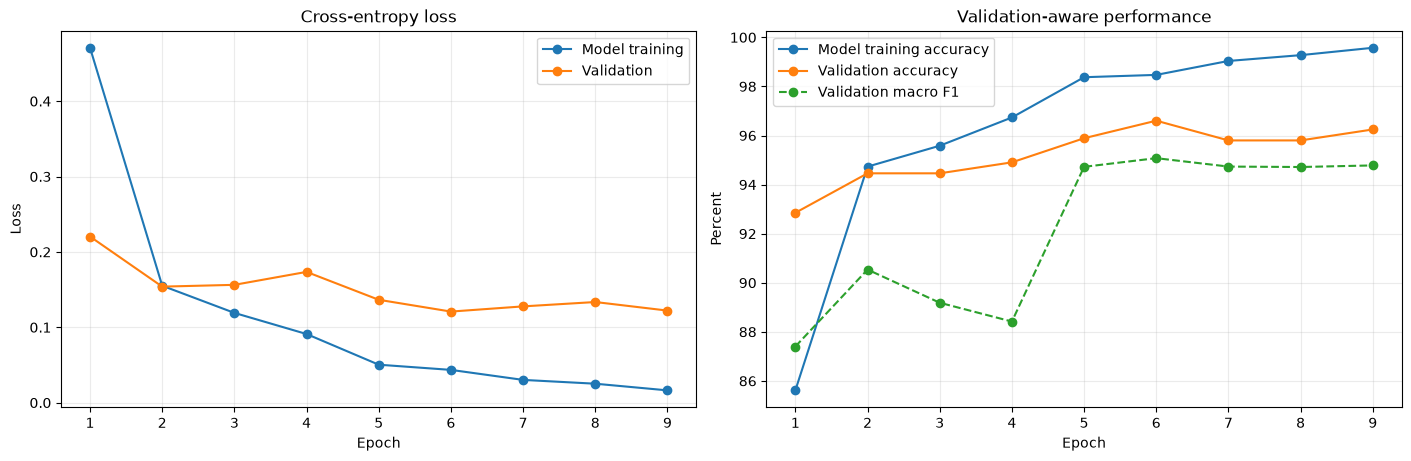

In [75]:
# Visualize learning curves from the validation-aware MalwareClassifier
# training run.
# HTB lesson plots extended as a personal addition: 
# shows both training and validation behavior, 
# which is needed to diagnose overfitting 
# without consulting the final test split.

if "malware_training_history" not in globals():
    raise RuntimeError(
        "Run the preceding training cell before plotting learning curves."
    )

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 4.5),
    constrained_layout=True,
)

axes[0].plot(
    malware_training_history["epoch"],
    malware_training_history["train_loss"],
    marker="o",
    label="Model training",
)
axes[0].plot(
    malware_training_history["epoch"],
    malware_training_history["validation_loss"],
    marker="o",
    label="Validation",
)
axes[0].set_title("Cross-entropy loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    malware_training_history["epoch"],
    100 * malware_training_history["train_accuracy"],
    marker="o",
    label="Model training accuracy",
)
axes[1].plot(
    malware_training_history["epoch"],
    100 * malware_training_history["validation_accuracy"],
    marker="o",
    label="Validation accuracy",
)
axes[1].plot(
    malware_training_history["epoch"],
    100 * malware_training_history["validation_macro_f1"],
    marker="o",
    linestyle="--",
    label="Validation macro F1",
)
axes[1].set_title("Validation-aware performance")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Percent")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()


,value
Accuracy (%),97.29
Balanced accuracy (%),95.20
Macro F1 (%),95.41
Weighted F1 (%),97.32


,precision,recall,f1-score,support
Swizzor.gen!I,0.529,0.667,0.590,27.0
Swizzor.gen!E,0.682,0.577,0.625,26.0
C2LOP.P,0.833,0.833,0.833,30.0
C2LOP.gen!g,0.973,0.900,0.935,40.0
Allaple.L,0.972,0.975,0.973,319.0
Alueron.gen!J,0.975,0.975,0.975,40.0
Malex.gen!J,1.000,0.964,0.982,28.0
Allaple.A,0.981,0.985,0.983,590.0
Rbot!gen,1.000,0.969,0.984,32.0
Lolyda.AT,1.000,0.969,0.984,32.0


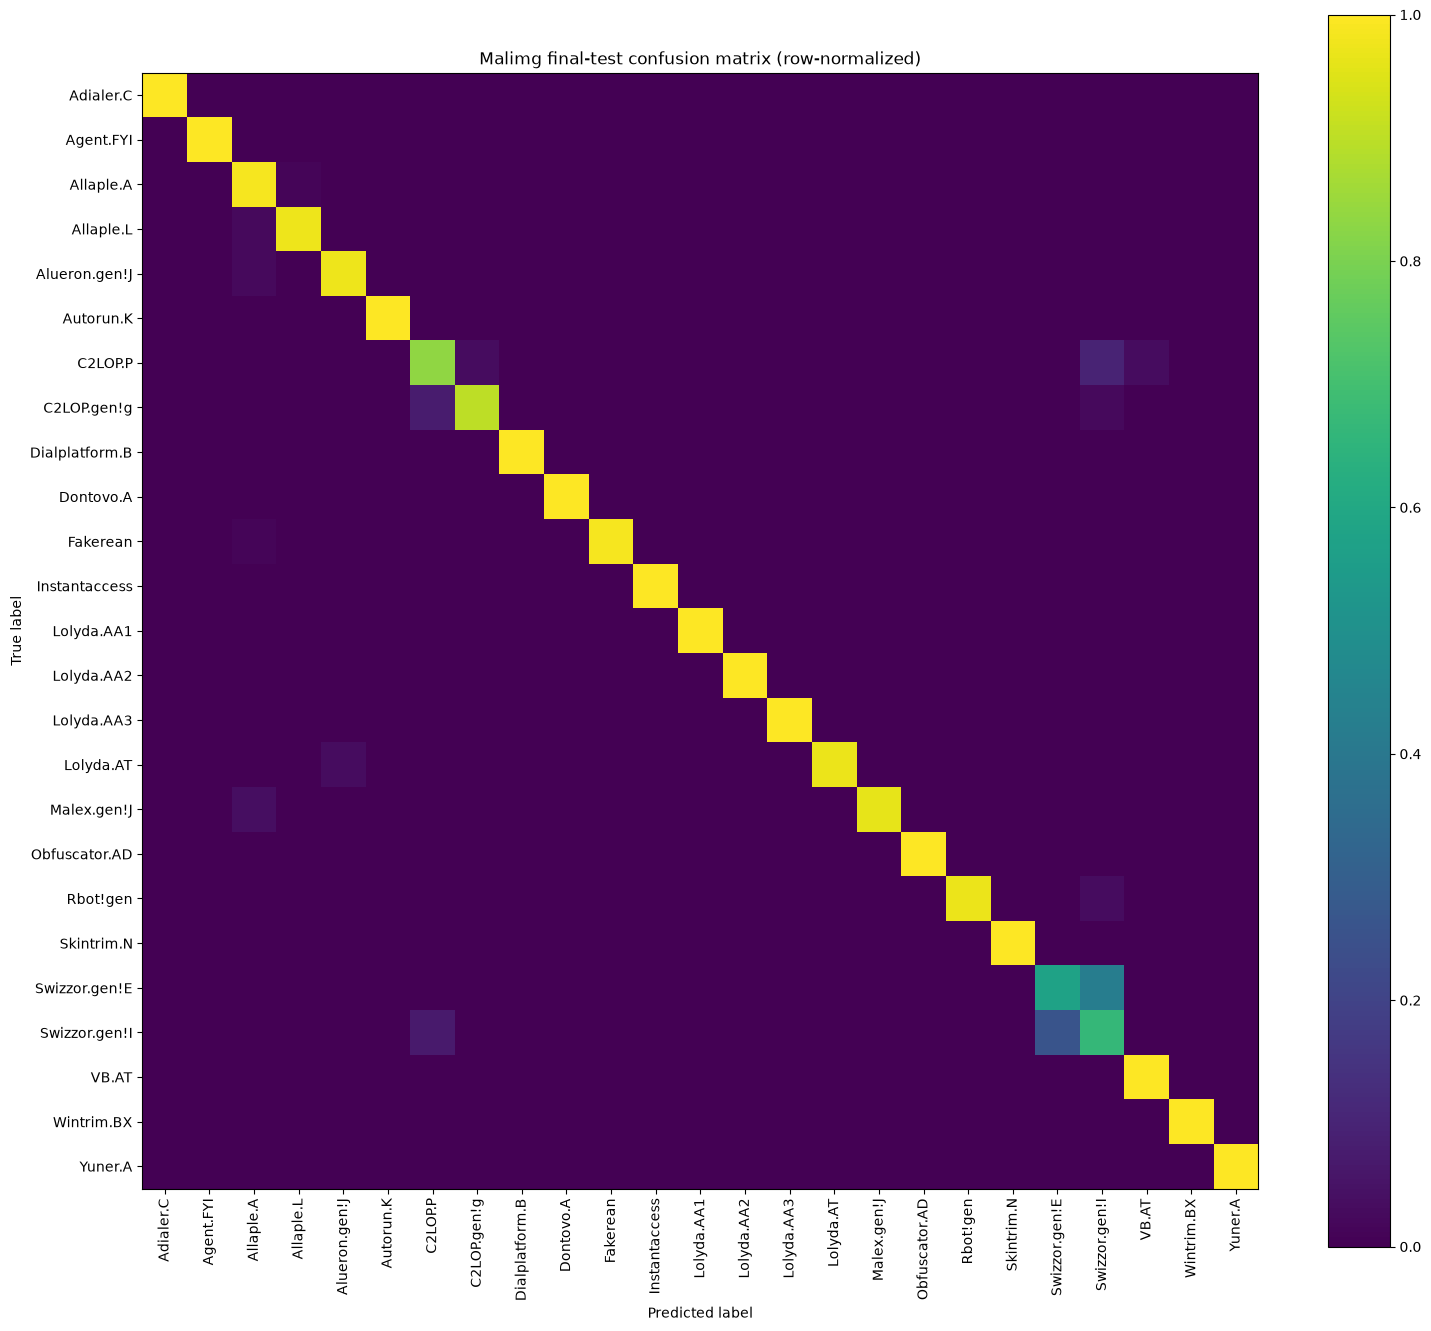

,test_index,image_path,actual_index,predicted_index,actual_family,predicted_family,confidence,correct
1647,1647,malimg_split_80_20/test/VB.AT/029d519fc10ef402...,22,22,VB.AT,VB.AT,1.0,True
334,334,malimg_split_80_20/test/Allaple.A/0428c0bcf623...,2,2,Allaple.A,Allaple.A,1.0,True
133,133,malimg_split_80_20/test/Allaple.A/009ac68df192...,2,2,Allaple.A,Allaple.A,1.0,True
523,523,malimg_split_80_20/test/Allaple.A/073cc37a2f3a...,2,2,Allaple.A,Allaple.A,1.0,True
128,128,malimg_split_80_20/test/Allaple.A/008868ad3974...,2,2,Allaple.A,Allaple.A,1.0,True
467,467,malimg_split_80_20/test/Allaple.A/06515bfb2192...,2,2,Allaple.A,Allaple.A,1.0,True
122,122,malimg_split_80_20/test/Allaple.A/007d6cb12558...,2,2,Allaple.A,Allaple.A,1.0,True
324,324,malimg_split_80_20/test/Allaple.A/040340a111c5...,2,2,Allaple.A,Allaple.A,1.0,True
116,116,malimg_split_80_20/test/Allaple.A/006f37930116...,2,2,Allaple.A,Allaple.A,1.0,True
465,465,malimg_split_80_20/test/Allaple.A/064d007a86f6...,2,2,Allaple.A,Allaple.A,1.0,True


In [76]:
# Evaluate the selected model once on the untouched Malimg test split and
# retain per-image predictions.
# HTB lesson evaluation expanded as a personal addition: 
# accuracy is supplemented with macro F1, balanced accuracy, 
# per-family metrics, and a normalized confusion matrix.

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)


def collect_malware_test_predictions(
    model,
    data_loader,
):
    model.eval()

    records = []
    test_index = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(
                MALWARE_DEVICE,
                non_blocking=True,
            )

            logits = model(images)
            probabilities = torch.softmax(
                logits,
                dim=1,
            )
            confidences, predictions = probabilities.max(
                dim=1
            )

            labels_list = labels.tolist()
            predictions_list = predictions.cpu().tolist()
            confidences_list = confidences.cpu().tolist()

            for actual_label, predicted_label, confidence in zip(
                labels_list,
                predictions_list,
                confidences_list,
            ):
                image_path, _ = malware_test_dataset.samples[
                    test_index
                ]

                records.append(
                    {
                        "test_index": test_index,
                        "image_path": str(image_path),
                        "actual_index": actual_label,
                        "predicted_index": predicted_label,
                        "actual_family": malware_class_names[actual_label],
                        "predicted_family": (
                            malware_class_names[predicted_label]
                        ),
                        "confidence": confidence,
                        "correct": actual_label == predicted_label,
                    }
                )

                test_index += 1

    return pd.DataFrame(records)


malware_test_predictions = collect_malware_test_predictions(
    malware_model,
    malware_test_loader,
)

malware_test_actual = malware_test_predictions[
    "actual_index"
]
malware_test_predicted = malware_test_predictions[
    "predicted_index"
]

malware_test_metrics = pd.DataFrame(
    {
        "value": [
            100 * accuracy_score(
                malware_test_actual,
                malware_test_predicted,
            ),
            100 * balanced_accuracy_score(
                malware_test_actual,
                malware_test_predicted,
            ),
            100 * f1_score(
                malware_test_actual,
                malware_test_predicted,
                average="macro",
                zero_division=0,
            ),
            100 * f1_score(
                malware_test_actual,
                malware_test_predicted,
                average="weighted",
                zero_division=0,
            ),
        ],
    },
    index=[
        "Accuracy (%)",
        "Balanced accuracy (%)",
        "Macro F1 (%)",
        "Weighted F1 (%)",
    ],
)

malware_family_report = pd.DataFrame(
    classification_report(
        malware_test_actual,
        malware_test_predicted,
        labels=list(
            range(malware_class_count)
        ),
        target_names=malware_class_names,
        output_dict=True,
        zero_division=0,
    )
).transpose().loc[
    malware_class_names
]

malware_normalized_confusion = confusion_matrix(
    malware_test_actual,
    malware_test_predicted,
    labels=list(
        range(malware_class_count)
    ),
    normalize="true",
)

display(
    malware_test_metrics.round(2)
)

display(
    malware_family_report.sort_values(
        "f1-score"
    ).head(10).round(3)
)

figure, axis = plt.subplots(
    figsize=(18, 16)
)

ConfusionMatrixDisplay(
    confusion_matrix=malware_normalized_confusion,
    display_labels=malware_class_names,
).plot(
    ax=axis,
    include_values=False,
    xticks_rotation=90,
    colorbar=True,
)

axis.set_title(
    "Malimg final-test confusion matrix (row-normalized)"
)
plt.show()

display(
    malware_test_predictions.sort_values(
        "confidence",
        ascending=False,
    ).head(10)
)


In [77]:
# Export the evaluated Malimg classifier in HTB-compatible TorchScript format
# plus a reproducible experiment checkpoint.
# HTB lesson export retained for the .pth artifact; personal additions save
# state, configuration, class names, and metrics for later audit or reuse.

if "malware_test_metrics" not in globals():
    raise RuntimeError(
        "Run final-test evaluation before exporting model artifacts."
    )

MALWARE_TORCHSCRIPT_PATH = (
    malware_model_artifact_dir
    / "malware_classifier.pth"
)

MALWARE_EXPERIMENT_CHECKPOINT_PATH = (
    malware_model_artifact_dir
    / f"{MALWARE_EXPERIMENT_NAME}_final.pt"
)

MALWARE_EXPERIMENT_METADATA_PATH = (
    malware_model_artifact_dir
    / f"{MALWARE_EXPERIMENT_NAME}_metadata.json"
)

save_htb_torchscript_model(
    malware_model,
    MALWARE_TORCHSCRIPT_PATH,
)

malware_cpu_state_dict = {
    name: parameter.detach().cpu()
    for name, parameter in malware_model.state_dict().items()
}

malware_final_metrics = {
    metric_name: float(metric_value)
    for metric_name, metric_value in malware_test_metrics[
        "value"
    ].items()
}

torch.save(
    {
        "model_state_dict": malware_cpu_state_dict,
        "class_names": malware_class_names,
        "experiment_config": malware_experiment_config,
        "best_validation_checkpoint": str(
            malware_best_checkpoint_path
        ),
        "final_test_metrics": malware_final_metrics,
    },
    MALWARE_EXPERIMENT_CHECKPOINT_PATH,
)

malware_artifact_metadata = {
    "experiment_config": malware_experiment_config,
    "class_weights": {
        family: float(weight)
        for family, weight in zip(
            malware_class_names,
            malware_class_weights,
        )
    },
    "best_validation_checkpoint": str(
        malware_best_checkpoint_path
    ),
    "final_test_metrics": malware_final_metrics,
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "platform": platform.platform(),
}

with MALWARE_EXPERIMENT_METADATA_PATH.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        malware_artifact_metadata,
        metadata_file,
        indent=2,
    )

malware_export_summary = pd.DataFrame(
    {
        "artifact": [
            "HTB TorchScript classifier",
            "Full experiment checkpoint",
            "Experiment metadata",
        ],
        "path": [
            str(MALWARE_TORCHSCRIPT_PATH),
            str(MALWARE_EXPERIMENT_CHECKPOINT_PATH),
            str(MALWARE_EXPERIMENT_METADATA_PATH),
        ],
        "size_kb": [
            path.stat().st_size / 1024
            for path in [
                MALWARE_TORCHSCRIPT_PATH,
                MALWARE_EXPERIMENT_CHECKPOINT_PATH,
                MALWARE_EXPERIMENT_METADATA_PATH,
            ]
        ],
    }
)

display(
    malware_export_summary.round(1)
)


,artifact,path,size_kb
0,HTB TorchScript classifier,malware_model_artifacts/malware_classifier.pth,100317.3
1,Full experiment checkpoint,malware_model_artifacts/resnet50_frozen_baseli...,100242.0
2,Experiment metadata,malware_model_artifacts/resnet50_frozen_baseli...,2.3


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


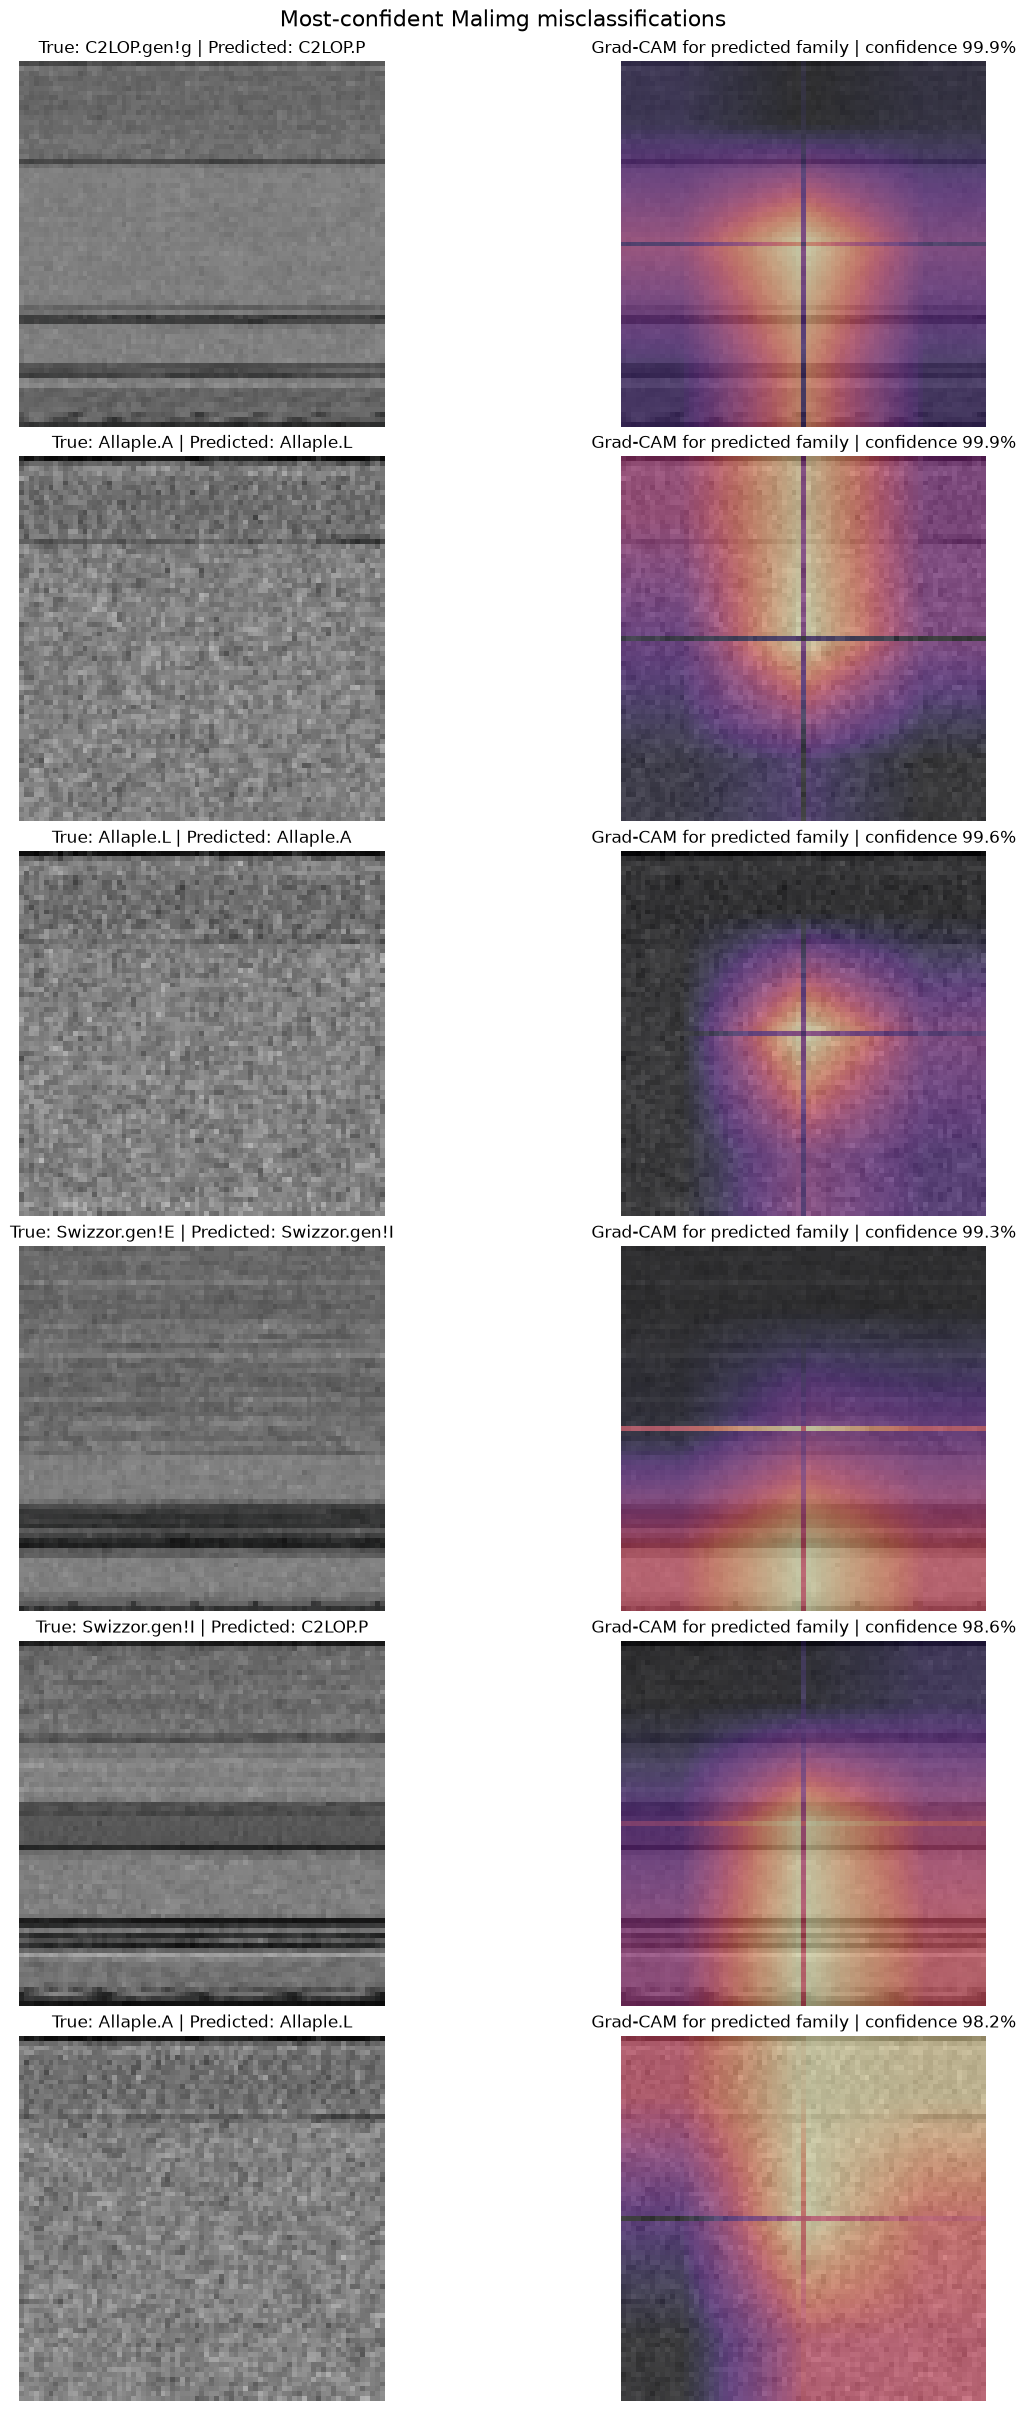

In [78]:
# Inspect difficult final-test examples with prediction confidence and
# Grad-CAM evidence.
# Personal notebook addition (not in HTB): prioritizes misclassifications,
# falls back to low-confidence predictions, and highlights image regions that
# most influenced each predicted family.

import numpy as np
import torch
import torch.nn.functional as functional


def unnormalize_malware_image(image_tensor):
    mean = torch.tensor(
        malware_normalize_mean
    ).view(3, 1, 1)
    standard_deviation = torch.tensor(
        malware_normalize_std
    ).view(3, 1, 1)

    image = image_tensor.detach().cpu()
    image = image * standard_deviation + mean
    image = image.permute(1, 2, 0).numpy()

    return np.clip(
        image,
        0,
        1,
    )


def malware_grad_cam(
    model,
    image_tensor,
    target_class=None,
):
    target_layer = model.resnet.layer4[-1].conv3
    activations = []
    gradients = []
    original_training_state = model.training
    original_requires_grad = [
        parameter.requires_grad
        for parameter in target_layer.parameters()
    ]

    for parameter in target_layer.parameters():
        parameter.requires_grad = True

    forward_handle = target_layer.register_forward_hook(
        lambda module, inputs, output: activations.append(
            output
        )
    )

    backward_handle = target_layer.register_full_backward_hook(
        lambda module, gradient_input, gradient_output: gradients.append(
            gradient_output[0]
        )
    )

    try:
        model.eval()
        model.zero_grad(
            set_to_none=True
        )

        model_input = image_tensor.unsqueeze(0).to(
            MALWARE_DEVICE
        )
        logits = model(model_input)

        if target_class is None:
            target_class = int(
                logits.argmax(
                    dim=1
                ).item()
            )

        logits[0, target_class].backward()

        if not activations or not gradients:
            raise RuntimeError(
                "Grad-CAM hooks did not capture activations and gradients."
            )

        activation_map = activations[0]
        gradient_map = gradients[0]
        channel_weights = gradient_map.mean(
            dim=(2, 3),
            keepdim=True,
        )

        heatmap = torch.relu(
            (channel_weights * activation_map).sum(
                dim=1,
                keepdim=True,
            )
        )

        heatmap = functional.interpolate(
            heatmap,
            size=MALWARE_IMAGE_SIZE,
            mode="bilinear",
            align_corners=False,
        ).squeeze()

        heatmap = heatmap.detach().cpu().numpy()
        heatmap = heatmap - heatmap.min()

        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        return heatmap
    finally:
        forward_handle.remove()
        backward_handle.remove()

        for parameter, original_flag in zip(
            target_layer.parameters(),
            original_requires_grad,
        ):
            parameter.requires_grad = original_flag

        model.train(
            original_training_state
        )


malware_error_cases = malware_test_predictions.loc[
    ~malware_test_predictions["correct"]
].sort_values(
    "confidence",
    ascending=False,
)

if malware_error_cases.empty:
    malware_error_cases = malware_test_predictions.nsmallest(
        6,
        "confidence",
    )
    malware_error_heading = (
        "No errors found; showing the least-confident predictions"
    )
else:
    malware_error_cases = malware_error_cases.head(6)
    malware_error_heading = (
        "Most-confident Malimg misclassifications"
    )

figure, axes = plt.subplots(
    nrows=len(malware_error_cases),
    ncols=2,
    figsize=(12, 4 * len(malware_error_cases)),
    squeeze=False,
    constrained_layout=True,
)

for row_number, (_, record) in enumerate(
    malware_error_cases.iterrows()
):
    image_tensor, _ = malware_test_dataset[
        int(record["test_index"])
    ]

    original_image = unnormalize_malware_image(
        image_tensor
    )

    heatmap = malware_grad_cam(
        malware_model,
        image_tensor,
        target_class=int(record["predicted_index"]),
    )

    axes[row_number, 0].imshow(
        original_image
    )
    axes[row_number, 0].set_title(
        f"True: {record['actual_family']} | "
        f"Predicted: {record['predicted_family']}"
    )
    axes[row_number, 0].axis("off")

    axes[row_number, 1].imshow(
        original_image
    )
    axes[row_number, 1].imshow(
        heatmap,
        cmap="magma",
        alpha=0.55,
    )
    axes[row_number, 1].set_title(
        "Grad-CAM for predicted family | "
        f"confidence {record['confidence']:.1%}"
    )
    axes[row_number, 1].axis("off")

figure.suptitle(
    malware_error_heading,
    fontsize=16,
)
plt.show()


## Evaluate the malware model and transition to the final assessment

On the untouched test set, the malware classifier reaches 97.29% accuracy, 95.20% balanced accuracy, 95.41% macro F1, and 97.32% weighted F1. The weakest reported family-level results are for `Swizzor.gen!I` (F1 approximately 0.590) and `Swizzor.gen!E` (approximately 0.625), reinforcing the lesson from the network dataset: aggregate performance is not a sufficient description of rare-class behavior.

The notebook exports a TorchScript-compatible artifact, reloads the saved state, and uses Grad-CAM-style analysis to connect predictions back to image regions. The interpretation is necessarily cautious—salient pixels are not automatically causal evidence—but it is useful for investigating whether a model is responding to plausible byteplot structure.

# IMDB Sentiment classification as a deployment exercise: Skills assessment

The final assessment covers an IMDB dataset containing separate `train.json` and `test.json` corpora of roughly 25,000 records each. Although the labels describe sentiment rather than a security event, the engineering problem is the same: acquire data idempotently, audit overlap and label consistency, create a validation protocol, select a model, refit only after selection, evaluate the official test set once, and export a portable artifact.

This section therefore serves as a compact unit capstone. It tests whether the workflow generalizes beyond the three security datasets while preserving the same standards for provenance, leakage control, error analysis, and reproducible packaging.

In [79]:
# Download and prepare the HTB Skills Assessment sentiment dataset
# idempotently.
# HTB workflow adapted for repeatable notebook execution: download once,
# extract only missing files, and preserve the supplied train/test split.

import random
import shutil
import zipfile
from pathlib import Path
from urllib.request import Request, urlopen

import numpy as np
import pandas as pd


IMDB_ASSESSMENT_SEED = 1337
IMDB_VALIDATION_RATIO = 0.15
IMDB_DATA_URL = (
    "https://academy.hackthebox.com/storage/modules/292/"
    "skills_assessment_data.zip"
)
IMDB_WORKSPACE = Path("imdb_skills_assessment")
IMDB_ARCHIVE_PATH = IMDB_WORKSPACE / "skills_assessment_data.zip"
IMDB_EXTRACT_DIRECTORY = IMDB_WORKSPACE / "data"
IMDB_ARTIFACT_DIRECTORY = IMDB_WORKSPACE / "artifacts"
IMDB_MODEL_FILENAME = "skills_assessment.joblib"
IMDB_TRAIN_JSON_PATH = IMDB_EXTRACT_DIRECTORY / "train.json"
IMDB_TEST_JSON_PATH = IMDB_EXTRACT_DIRECTORY / "test.json"

random.seed(IMDB_ASSESSMENT_SEED)
np.random.seed(IMDB_ASSESSMENT_SEED)
IMDB_EXTRACT_DIRECTORY.mkdir(parents=True, exist_ok=True)
IMDB_ARTIFACT_DIRECTORY.mkdir(parents=True, exist_ok=True)

download_status = "reused existing archive"
if not IMDB_ARCHIVE_PATH.exists():
    temporary_archive = IMDB_ARCHIVE_PATH.with_suffix(".zip.part")
    request = Request(IMDB_DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
    with (
        urlopen(request, timeout=120) as response,
        temporary_archive.open("wb") as output
    ):
        shutil.copyfileobj(response, output)
    temporary_archive.replace(IMDB_ARCHIVE_PATH)
    download_status = "downloaded from HTB"

if not zipfile.is_zipfile(IMDB_ARCHIVE_PATH):
    raise ValueError(
        f"Downloaded file is not a valid ZIP archive: {IMDB_ARCHIVE_PATH}"
    )

required_files = {
    "train.json": IMDB_TRAIN_JSON_PATH,
    "test.json": IMDB_TEST_JSON_PATH,
}
missing_files = [
    name for name, target in required_files.items() if not target.exists()
]

if missing_files:
    with zipfile.ZipFile(IMDB_ARCHIVE_PATH) as archive:
        unavailable = set(missing_files) - set(archive.namelist())
        if unavailable:
            raise ValueError(
                "HTB archive is missing required files: "
                f"{sorted(unavailable)}"
            )
        for member_name in missing_files:
            with (
                archive.open(member_name) as source,
                required_files[member_name].open("wb") as target
            ):
                shutil.copyfileobj(source, target)
    extraction_status = f"extracted {', '.join(missing_files)}"
else:
    extraction_status = "reused extracted JSON files"

display(pd.DataFrame({
    "item": ["archive", "train data", "test data", "artifact directory"],
    "status": [
        download_status, extraction_status, extraction_status, "ready"
    ],
    "path": [
        str(IMDB_ARCHIVE_PATH.resolve()),
        str(IMDB_TRAIN_JSON_PATH.resolve()),
        str(IMDB_TEST_JSON_PATH.resolve()),
        str(IMDB_ARTIFACT_DIRECTORY.resolve()),
    ],
}))


,item,status,path
0,archive,reused existing archive,/Users/seankilfoy/Documents/Studies/HTB Academ...
1,train data,reused extracted JSON files,/Users/seankilfoy/Documents/Studies/HTB Academ...
2,test data,reused extracted JSON files,/Users/seankilfoy/Documents/Studies/HTB Academ...
3,artifact directory,ready,/Users/seankilfoy/Documents/Studies/HTB Academ...


In [80]:
# Load HTB's train.json and test.json sentiment records into the notebook's
# modeling schema.
# HTB dataset integration: map text/label to review/sentiment while retaining
# each supplied partition's provenance.

import json


def load_htb_sentiment_json(json_path, split_name):
    with json_path.open(encoding="utf-8") as input_file:
        records = json.load(input_file)

    dataframe = pd.DataFrame(records)
    required_columns = {"text", "label"}
    missing_columns = required_columns - set(dataframe.columns)
    if missing_columns:
        raise ValueError(
            f"{json_path.name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    dataframe = dataframe.rename(
        columns={"text": "review", "label": "sentiment"}
    )
    if dataframe["review"].isna().any():
        raise ValueError(f"{json_path.name} contains missing review text.")

    dataframe["review"] = dataframe["review"].astype(str)
    dataframe["sentiment"] = pd.to_numeric(
        dataframe["sentiment"], errors="raise"
    ).astype(int)
    if not set(dataframe["sentiment"].unique()).issubset({0, 1}):
        raise ValueError(
            f"{json_path.name} labels must use negative=0 and positive=1."
        )

    dataframe.insert(
        0,
        "record_id",
        [f"{split_name}-json-{index}" for index in range(len(dataframe))],
    )
    dataframe.insert(1, "source_split", split_name)
    return dataframe[["record_id", "source_split", "review", "sentiment"]]


imdb_official_train = load_htb_sentiment_json(
    IMDB_TRAIN_JSON_PATH, "train"
)
imdb_official_test = load_htb_sentiment_json(
    IMDB_TEST_JSON_PATH, "test"
)
imdb_reviews = pd.concat(
    [imdb_official_train, imdb_official_test], ignore_index=True
)

if set(imdb_reviews["sentiment"].unique()) != {0, 1}:
    raise ValueError(
        "The combined HTB dataset must contain both sentiment classes."
    )

imdb_load_summary = imdb_reviews.groupby("source_split").agg(
    review_count=("record_id", "size"),
    positive_share=("sentiment", "mean"),
)

print("Input format: HTB train.json/test.json")
display(imdb_load_summary)
display(imdb_reviews.head(3))


Input format: HTB train.json/test.json


,review_count,positive_share
source_split,,
test,25000,0.5
train,25000,0.5


,record_id,source_split,review,sentiment
0,train-json-0,train,Bromwell High is a cartoon comedy. It ran at t...,1
1,train-json-1,train,Homelessness (or Houselessness as George Carli...,1
2,train-json-2,train,Brilliant over-acting by Lesley Ann Warren. Be...,1


## Load the assessment corpus with rerun-safe acquisition

The compact loader downloads each JSON file only when it is absent, then reads the supplied train and test records into data frames. This is the same idempotent acquisition principle used for the SMS and NSL-KDD datasets, now applied to a split corpus whose train/test boundary is part of the assessment contract.

Before fitting a classifier, the notebook audits schema, labels, lengths, missingness, duplicates, and overlap. That audit is especially important here because an apparent test advantage can be caused by repeated or near-repeated text rather than by generalization.


,review_count,positive_share,blank_reviews,within_split_duplicates,median_word_count
Official train,25000,0.5,0,96,181.0
Official test,25000,0.5,0,199,178.0


Normalized review hashes shared across official train/test: 123
Data-quality note: retaining the supplied HTB partitions unchanged; 123 normalized reviews occur in both splits with consistent labels. Final-test metrics may be slightly optimistic.


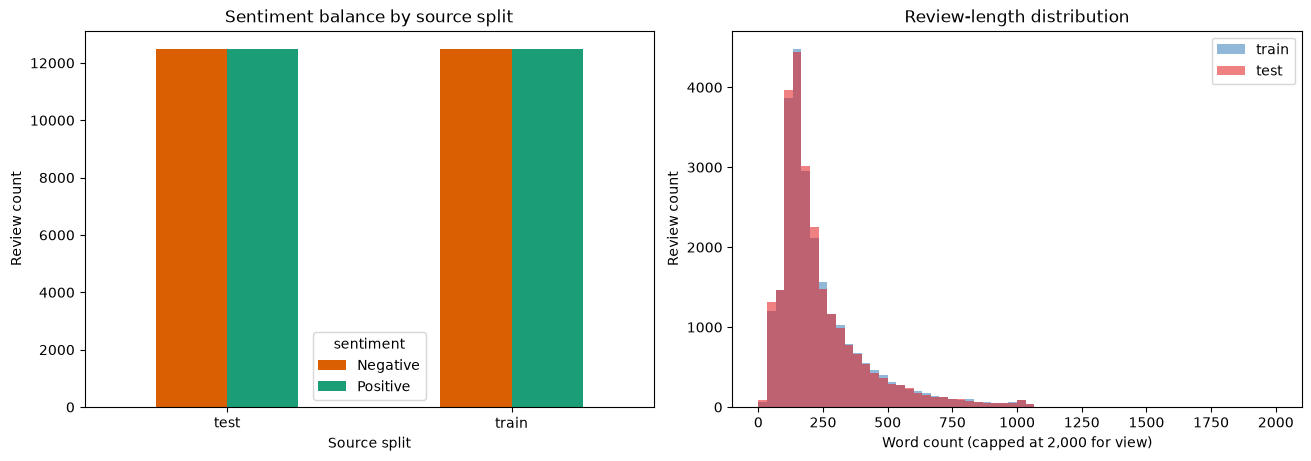

In [81]:
# Audit IMDB text quality, class balance, and train/test leakage before
# feature extraction.
# Personal notebook addition (not in HTB): computes fresh review hashes on
# every run and blocks training if normalized duplicate reviews cross the
# official split boundary.

import hashlib

import matplotlib.pyplot as plt


def canonicalize_review_for_audit(review):
    return " ".join(review.lower().split())


imdb_reviews["review_character_count"] = imdb_reviews[
    "review"
].str.len()

imdb_reviews["review_word_count"] = imdb_reviews[
    "review"
].str.findall(r"\b\w+\b").str.len()

imdb_reviews["review_sha256"] = imdb_reviews[
    "review"
].map(
    lambda review: hashlib.sha256(
        canonicalize_review_for_audit(
            review
        ).encode("utf-8")
    ).hexdigest()
)

imdb_official_train = imdb_reviews.loc[
    imdb_reviews["source_split"] == "train"
].reset_index(drop=True)

imdb_official_test = imdb_reviews.loc[
    imdb_reviews["source_split"] == "test"
].reset_index(drop=True)

imdb_cross_split_hashes = set(
    imdb_official_train["review_sha256"]
).intersection(
    imdb_official_test["review_sha256"]
)

imdb_data_quality_summary = pd.DataFrame(
    {
        "review_count": [
            len(imdb_official_train),
            len(imdb_official_test),
        ],
        "positive_share": [
            imdb_official_train["sentiment"].mean(),
            imdb_official_test["sentiment"].mean(),
        ],
        "blank_reviews": [
            imdb_official_train["review"].str.strip().eq("").sum(),
            imdb_official_test["review"].str.strip().eq("").sum(),
        ],
        "within_split_duplicates": [
            imdb_official_train["review_sha256"].duplicated().sum(),
            imdb_official_test["review_sha256"].duplicated().sum(),
        ],
        "median_word_count": [
            imdb_official_train["review_word_count"].median(),
            imdb_official_test["review_word_count"].median(),
        ],
    },
    index=["Official train", "Official test"],
)

display(imdb_data_quality_summary)

print(
    "Normalized review hashes shared across official train/test: "
    f"{len(imdb_cross_split_hashes):,}"
)

imdb_cross_split_label_conflicts = int(
    (
        pd.concat(
            [
                imdb_official_train[
                    ["review_sha256", "sentiment"]
                ],
                imdb_official_test[
                    ["review_sha256", "sentiment"]
                ],
            ],
            ignore_index=True,
        )
        .loc[
            lambda frame: frame["review_sha256"].isin(
                imdb_cross_split_hashes
            )
        ]
        .groupby("review_sha256")["sentiment"]
        .nunique()
        .gt(1)
        .sum()
    )
)

if imdb_cross_split_label_conflicts:
    raise ValueError(
        "Conflicting labels found for normalized reviews shared across the "
        "supplied HTB train/test partitions. Stop and inspect the source "
        "data."
    )

if imdb_cross_split_hashes:
    print(
        "Data-quality note: retaining the supplied HTB partitions unchanged; "
        f"{len(imdb_cross_split_hashes):,} normalized reviews occur in both "
        "splits with consistent labels. Final-test metrics may be slightly "
        "optimistic."
    )

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 4.5),
    constrained_layout=True,
)

imdb_label_counts = (
    imdb_reviews.groupby(
        ["source_split", "sentiment"]
    ).size().unstack(fill_value=0)
)

imdb_label_counts.rename(
    columns={0: "Negative", 1: "Positive"}
).plot(
    kind="bar",
    ax=axes[0],
    color=["#d95f02", "#1b9e77"],
)

axes[0].set_title("Sentiment balance by source split")
axes[0].set_xlabel("Source split")
axes[0].set_ylabel("Review count")
axes[0].tick_params(axis="x", rotation=0)

for split_name, color in [
    ("train", "#377eb8"),
    ("test", "#e41a1c"),
]:
    axes[1].hist(
        imdb_reviews.loc[
            imdb_reviews["source_split"] == split_name,
            "review_word_count",
        ],
        bins=60,
        range=(0, 2000),
        alpha=0.55,
        label=split_name,
        color=color,
    )

axes[1].set_title("Review-length distribution")
axes[1].set_xlabel("Word count (capped at 2,000 for view)")
axes[1].set_ylabel("Review count")
axes[1].legend()
plt.show()


## Treat overlap as an explicit assumption

The audit identifies 123 train/test overlaps with consistent labels. They are documented rather than removed, because changing the supplied assessment data would alter the task being evaluated. The correct conclusion is not “there is no leakage”; it is “the corpus contains a small, known overlap that must be considered when interpreting the final result.”

A stratified validation split of the official training data provides the decision surface for model selection. The next cells compare TF-IDF feature configurations and candidate linear models without touching the official test labels.


In [82]:
# Create a deterministic validation partition from the official IMDB training
# set.
# Personal notebook addition (not in HTB): uses validation data for model
# selection and keeps the supplied official test split isolated for final
# evaluation.

from sklearn.model_selection import train_test_split


(
    imdb_model_train,
    imdb_validation,
) = train_test_split(
    imdb_official_train,
    test_size=IMDB_VALIDATION_RATIO,
    random_state=IMDB_ASSESSMENT_SEED,
    stratify=imdb_official_train["sentiment"],
)

imdb_model_train = imdb_model_train.reset_index(
    drop=True
)

imdb_validation = imdb_validation.reset_index(
    drop=True
)

imdb_final_test = imdb_official_test.copy().reset_index(
    drop=True
)

imdb_partition_record_ids = {
    "model_train": set(
        imdb_model_train["record_id"]
    ),
    "validation": set(
        imdb_validation["record_id"]
    ),
    "final_test": set(
        imdb_final_test["record_id"]
    ),
}

for left_name, right_name in [
    ("model_train", "validation"),
    ("model_train", "final_test"),
    ("validation", "final_test"),
]:
    if imdb_partition_record_ids[left_name].intersection(
        imdb_partition_record_ids[right_name]
    ):
        raise ValueError(
            f"Record identity overlap between {left_name} and {right_name}."
        )

if (
    len(imdb_model_train)
    + len(imdb_validation)
    != len(imdb_official_train)
):
    raise AssertionError(
        "Training and validation counts do not reconcile to the "
        "official training set."
    )

imdb_partition_summary = pd.DataFrame(
    {
        "review_count": [
            len(imdb_model_train),
            len(imdb_validation),
            len(imdb_final_test),
        ],
        "positive_share": [
            imdb_model_train["sentiment"].mean(),
            imdb_validation["sentiment"].mean(),
            imdb_final_test["sentiment"].mean(),
        ],
    },
    index=[
        "Model training",
        "Validation",
        "Official final test",
    ],
)

display(imdb_partition_summary)


,review_count,positive_share
Model training,21250,0.5
Validation,3750,0.5
Official final test,25000,0.5


In [83]:
# Define portable TF-IDF sentiment-classification candidates that HTB can load
# directly from Joblib.
# Personal notebook addition (not in HTB): compares a probability-producing
# Logistic Regression baseline with a strong LinearSVC alternative while
# preserving negation-bearing words.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


IMDB_TFIDF_MAX_FEATURES = 150000
IMDB_TFIDF_MIN_DOCUMENT_FREQUENCY = 2
IMDB_TFIDF_MAX_DOCUMENT_FREQUENCY = 0.98


def build_imdb_word_vectorizer():
    return TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1, 2),
        min_df=IMDB_TFIDF_MIN_DOCUMENT_FREQUENCY,
        max_df=IMDB_TFIDF_MAX_DOCUMENT_FREQUENCY,
        max_features=IMDB_TFIDF_MAX_FEATURES,
        sublinear_tf=True,
        dtype=np.float32,
    )


def build_logistic_regression_pipeline():
    return Pipeline(
        [
            ("vectorizer", build_imdb_word_vectorizer()),
            (
                "classifier",
                LogisticRegression(
                    C=4.0,
                    max_iter=2000,
                    solver="liblinear",
                    random_state=IMDB_ASSESSMENT_SEED,
                ),
            ),
        ]
    )


def build_linear_svc_pipeline():
    return Pipeline(
        [
            ("vectorizer", build_imdb_word_vectorizer()),
            (
                "classifier",
                LinearSVC(
                    C=1.25,
                    random_state=IMDB_ASSESSMENT_SEED,
                ),
            ),
        ]
    )


imdb_candidate_factories = {
    "word_tfidf_logistic_regression": build_logistic_regression_pipeline,
    "word_tfidf_linear_svc": build_linear_svc_pipeline,
}

imdb_candidate_design = pd.DataFrame(
    {
        "candidate": [
            "word_tfidf_logistic_regression",
            "word_tfidf_linear_svc",
        ],
        "classifier": [
            "LogisticRegression",
            "LinearSVC",
        ],
        "features": [
            "word TF-IDF unigrams and bigrams",
            "word TF-IDF unigrams and bigrams",
        ],
        "selection split": [
            "Validation only",
            "Validation only",
        ],
    }
)

display(imdb_candidate_design)


,candidate,classifier,features,selection split
0,word_tfidf_logistic_regression,LogisticRegression,word TF-IDF unigrams and bigrams,Validation only
1,word_tfidf_linear_svc,LinearSVC,word TF-IDF unigrams and bigrams,Validation only


In [84]:
# Fit candidate IMDB pipelines and choose a final configuration using
# validation metrics only.
# Personal notebook addition (not in HTB): makes model selection auditable
# with fixed data partitions, fit timing, and balanced metrics instead of
# choosing by raw accuracy alone.

import time

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


imdb_candidate_models = {}
imdb_candidate_score_records = []

for candidate_name, candidate_factory in (
    imdb_candidate_factories.items()
):
    candidate_model = candidate_factory()
    fit_started_at = time.perf_counter()

    candidate_model.fit(
        imdb_model_train["review"],
        imdb_model_train["sentiment"],
    )

    fit_seconds = time.perf_counter() - fit_started_at

    validation_predictions = candidate_model.predict(
        imdb_validation["review"]
    )

    imdb_candidate_models[candidate_name] = (
        candidate_model
    )

    imdb_candidate_score_records.append(
        {
            "candidate": candidate_name,
            "fit_seconds": fit_seconds,
            "validation_accuracy": accuracy_score(
                imdb_validation["sentiment"],
                validation_predictions,
            ),
            "validation_balanced_accuracy": balanced_accuracy_score(
                imdb_validation["sentiment"],
                validation_predictions,
            ),
            "validation_macro_f1": f1_score(
                imdb_validation["sentiment"],
                validation_predictions,
                average="macro",
                zero_division=0,
            ),
            "validation_positive_precision": precision_score(
                imdb_validation["sentiment"],
                validation_predictions,
                zero_division=0,
            ),
            "validation_positive_recall": recall_score(
                imdb_validation["sentiment"],
                validation_predictions,
                zero_division=0,
            ),
        }
    )

imdb_validation_scoreboard = pd.DataFrame(
    imdb_candidate_score_records
).sort_values(
    [
        "validation_macro_f1",
        "validation_balanced_accuracy",
        "validation_accuracy",
        "fit_seconds",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

imdb_selected_model_name = (
    imdb_validation_scoreboard.loc[
        0,
        "candidate",
    ]
)

imdb_selected_validation_model = (
    imdb_candidate_models[
        imdb_selected_model_name
    ]
)

display(imdb_validation_scoreboard.round(4))

print(
    "Selected candidate from validation performance: "
    f"{imdb_selected_model_name}"
)


,candidate,fit_seconds,validation_accuracy,validation_balanced_accuracy,validation_macro_f1,validation_positive_precision,validation_positive_recall
0,word_tfidf_linear_svc,8.7795,0.9144,0.9144,0.9144,0.9111,0.9184
1,word_tfidf_logistic_regression,10.1337,0.9051,0.9051,0.9051,0.9012,0.9099


Selected candidate from validation performance: word_tfidf_linear_svc


## Select the model on validation evidence

TF-IDF converts text into weighted sparse features so that a term’s importance reflects both its presence and its frequency across the corpus. Candidate configurations are compared on the validation partition, and the selected LinearSVC-style classifier is chosen for validation performance rather than for a post-hoc test result. This is a practical choice for high-dimensional sparse text: linear decision boundaries are fast, strong baselines and easy to inspect through their coefficients.

The following diagnostics examine the selected model’s errors and its most influential terms. The purpose is not to treat coefficients as a complete explanation, but to identify vocabulary that contributes to class separation and to locate examples that warrant human review.


,precision,recall,f1-score,support
Negative,0.918,0.910,0.914,1875.000
Positive,0.911,0.918,0.915,1875.000
accuracy,0.914,0.914,0.914,0.914
macro avg,0.914,0.914,0.914,3750.000
weighted avg,0.914,0.914,0.914,3750.000


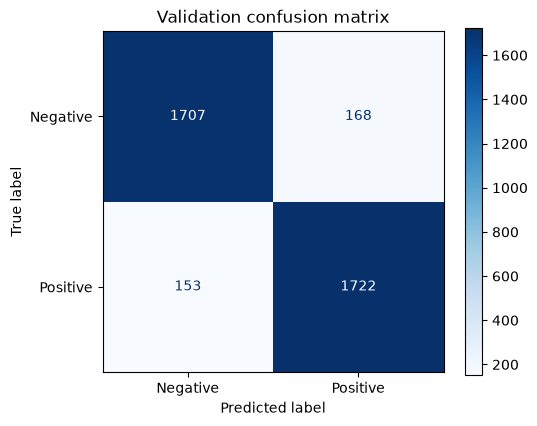

,sentiment,predicted_sentiment,confidence,review_word_count,review_preview
1315,0,1,0.818157,99,normally i'm not the sort to be scared by horr...
2904,0,1,0.756785,685,"Welcome to Our Town, welcome to your town? As ..."
914,1,0,0.755330,78,If the creators of this film had made any atte...
3654,0,1,0.749993,508,"I saw Chan Is Missing when it first came out, ..."
3037,1,0,0.739207,157,Say what you want about Andy Milligan - but if...
3591,0,1,0.736128,75,"Despite the excellent cast, this is an unremar..."
2161,0,1,0.732227,205,<br /><br />Whether any indictment was intende...
2113,1,0,0.718320,263,"Man, if anyone was expecting a great zombie mo..."
2610,0,1,0.718188,105,Florence Chadwick was actually the far more ac...
2326,0,1,0.716536,171,I like Brad Pitt enormously. He is an actor wi...


In [85]:
# Diagnose validation performance, confidence, and representative IMDB
# classification errors.
# Personal notebook addition (not in HTB): keeps qualitative error review
# inside the validation stage so it cannot influence the final-test estimate.

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)


def imdb_prediction_confidence(model, reviews):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(reviews).max(axis=1)

    decision_scores = model.decision_function(reviews)
    decision_scores = np.asarray(decision_scores).reshape(-1)

    return 1 / (
        1 + np.exp(-np.abs(decision_scores))
    )


imdb_validation_predicted_labels = (
    imdb_selected_validation_model.predict(
        imdb_validation["review"]
    )
)

imdb_validation_predictions = imdb_validation.assign(
    predicted_sentiment=imdb_validation_predicted_labels,
    confidence=imdb_prediction_confidence(
        imdb_selected_validation_model,
        imdb_validation["review"],
    ),
)

imdb_validation_predictions["correct"] = (
    imdb_validation_predictions["sentiment"]
    == imdb_validation_predictions[
        "predicted_sentiment"
    ]
)

imdb_validation_report = pd.DataFrame(
    classification_report(
        imdb_validation_predictions["sentiment"],
        imdb_validation_predictions[
            "predicted_sentiment"
        ],
        labels=[0, 1],
        target_names=["Negative", "Positive"],
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(imdb_validation_report.round(3))

figure, axis = plt.subplots(figsize=(5.5, 4.5))

ConfusionMatrixDisplay.from_predictions(
    imdb_validation_predictions["sentiment"],
    imdb_validation_predictions[
        "predicted_sentiment"
    ],
    display_labels=["Negative", "Positive"],
    cmap="Blues",
    ax=axis,
)

axis.set_title("Validation confusion matrix")
plt.show()

imdb_validation_errors = imdb_validation_predictions.loc[
    ~imdb_validation_predictions["correct"]
].copy()

imdb_validation_errors["review_preview"] = (
    imdb_validation_errors["review"].str.replace(
        r"\s+",
        " ",
        regex=True,
    ).str.slice(0, 300)
)

display(
    imdb_validation_errors.sort_values(
        "confidence",
        ascending=False,
    )[
        [
            "sentiment",
            "predicted_sentiment",
            "confidence",
            "review_word_count",
            "review_preview",
        ]
    ].head(10)
)


,feature,weight_for_positive
147974,worst,-4.080837
14963,bad,-3.719838
14669,awful,-3.597970
98485,poor,-3.098766
127704,the worst,-3.036954
20027,boring,-3.005421
141850,waste,-2.846962
35710,disappointing,-2.682258
59547,horrible,-2.541378
120771,terrible,-2.433499


,feature,weight_for_positive
52698,great,3.389015
42431,excellent,3.313895
96098,perfect,2.740029
49462,fun,2.293171
147294,wonderful,2.275710
5225,amazing,2.073020
18496,better than,2.046689
133562,today,2.028722
21692,brilliant,2.020589
40576,enjoyable,1.916445


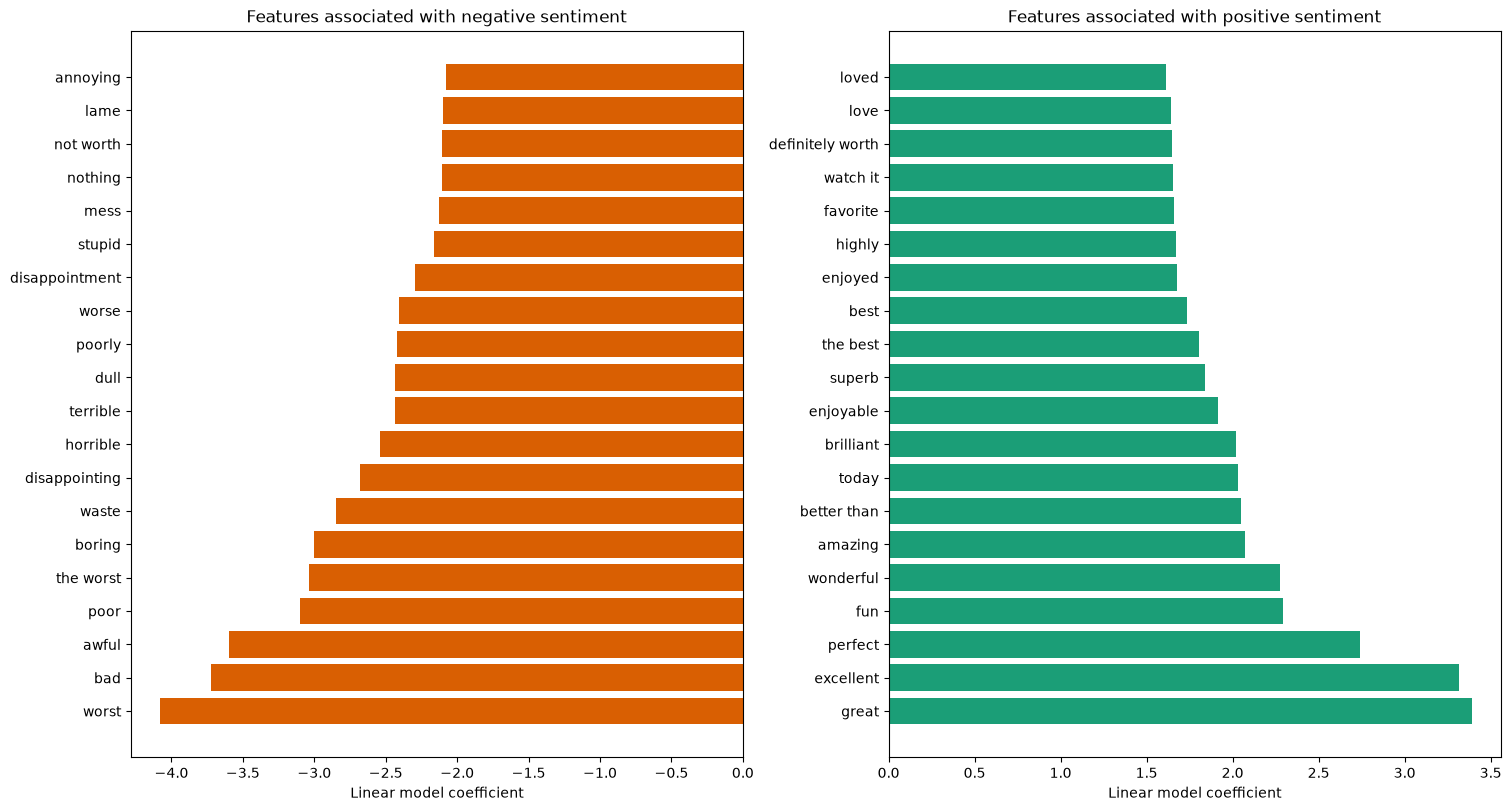

In [86]:
# Explain the validation-selected linear sentiment model through its strongest
# positive and negative TF-IDF features.
# Personal notebook addition (not in HTB): adds coefficient-level
# interpretation so the selected model can be reviewed for intuitive and
# suspicious sentiment signals.

imdb_selected_vectorizer = (
    imdb_selected_validation_model.named_steps[
        "vectorizer"
    ]
)

imdb_selected_classifier = (
    imdb_selected_validation_model.named_steps[
        "classifier"
    ]
)

if not hasattr(
    imdb_selected_classifier,
    "coef_",
):
    raise TypeError(
        "Selected candidate does not expose linear feature coefficients."
    )

imdb_feature_names = (
    imdb_selected_vectorizer.get_feature_names_out()
)

imdb_feature_weights = (
    imdb_selected_classifier.coef_.ravel()
)

imdb_feature_importance = pd.DataFrame(
    {
        "feature": imdb_feature_names,
        "weight_for_positive": imdb_feature_weights,
    }
)

imdb_top_negative_features = (
    imdb_feature_importance.nsmallest(
        20,
        "weight_for_positive",
    )
)

imdb_top_positive_features = (
    imdb_feature_importance.nlargest(
        20,
        "weight_for_positive",
    )
)

display(imdb_top_negative_features)
display(imdb_top_positive_features)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 8),
    constrained_layout=True,
)

axes[0].barh(
    imdb_top_negative_features["feature"],
    imdb_top_negative_features[
        "weight_for_positive"
    ],
    color="#d95f02",
)
axes[0].set_title(
    "Features associated with negative sentiment"
)
axes[0].set_xlabel(
    "Linear model coefficient"
)

axes[1].barh(
    imdb_top_positive_features["feature"],
    imdb_top_positive_features[
        "weight_for_positive"
    ],
    color="#1b9e77",
)
axes[1].set_title(
    "Features associated with positive sentiment"
)
axes[1].set_xlabel(
    "Linear model coefficient"
)

plt.show()


## Refit only after selection, then report once

Coefficient inspection provides a bridge between model behavior and language patterns, but it is performed before the final refit so that selection remains separate from final reporting. Once the representation and estimator are fixed, the model is retrained on all official training data and evaluated on the held-out assessment test set.

That sequence is the notebook’s final example of disciplined evaluation: use validation data to choose, use all permitted training data to fit the final artifact, and use the test data once for the final estimate. The next cells add post-hoc error slices before packaging the pipeline.


In [87]:
# Refit the validation-selected IMDB pipeline using every review from the
# official training partition.
# Personal notebook addition (not in HTB): this refit incorporates validation
# examples only after the model configuration was fixed, with no final-test
# data used.

imdb_final_training_frame = pd.concat(
    [
        imdb_model_train,
        imdb_validation,
    ],
    ignore_index=True,
).sample(
    frac=1,
    random_state=IMDB_ASSESSMENT_SEED,
).reset_index(
    drop=True
)

imdb_final_model = imdb_candidate_factories[
    imdb_selected_model_name
]()

imdb_final_fit_started_at = time.perf_counter()

imdb_final_model.fit(
    imdb_final_training_frame["review"],
    imdb_final_training_frame["sentiment"],
)

imdb_final_fit_seconds = (
    time.perf_counter()
    - imdb_final_fit_started_at
)

imdb_final_training_summary = pd.DataFrame(
    {
        "selected_candidate": [
            imdb_selected_model_name
        ],
        "official_train_reviews_used": [
            len(imdb_final_training_frame)
        ],
        "final_fit_seconds": [
            imdb_final_fit_seconds
        ],
        "held_out_official_test_reviews": [
            len(imdb_final_test)
        ],
    }
)

display(imdb_final_training_summary.round(3))


,selected_candidate,official_train_reviews_used,final_fit_seconds,held_out_official_test_reviews
0,word_tfidf_linear_svc,25000,13.007,25000


,value
Accuracy (%),90.37
Balanced accuracy (%),90.37
Macro F1 (%),90.37
Positive precision (%),90.58
Positive recall (%),90.11


,precision,recall,f1-score,support
Negative,0.902,0.906,0.904,12500.000
Positive,0.906,0.901,0.903,12500.000
accuracy,0.904,0.904,0.904,0.904
macro avg,0.904,0.904,0.904,25000.000
weighted avg,0.904,0.904,0.904,25000.000


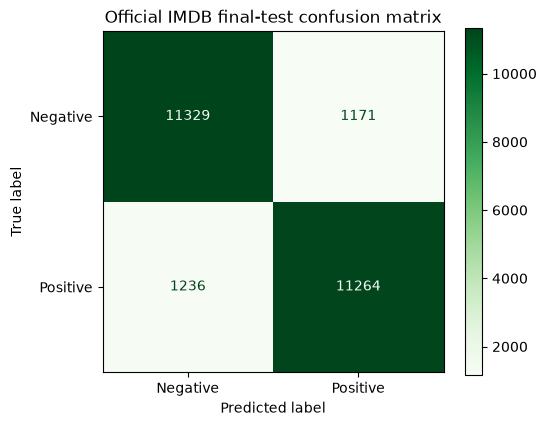

In [88]:
# Evaluate the finalized IMDB pipeline against the untouched official test
# partition.
# Personal notebook addition (not in HTB): records a complete final-test
# report after model selection rather than using accuracy alone as the success
# criterion.

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)


imdb_final_test_predicted_labels = imdb_final_model.predict(
    imdb_final_test["review"]
)

imdb_final_test_confidence = imdb_prediction_confidence(
    imdb_final_model,
    imdb_final_test["review"],
)

imdb_final_test_metrics = pd.DataFrame(
    {
        "value": [
            100 * accuracy_score(
                imdb_final_test["sentiment"],
                imdb_final_test_predicted_labels,
            ),
            100 * balanced_accuracy_score(
                imdb_final_test["sentiment"],
                imdb_final_test_predicted_labels,
            ),
            100 * f1_score(
                imdb_final_test["sentiment"],
                imdb_final_test_predicted_labels,
                average="macro",
                zero_division=0,
            ),
            100 * precision_score(
                imdb_final_test["sentiment"],
                imdb_final_test_predicted_labels,
                zero_division=0,
            ),
            100 * recall_score(
                imdb_final_test["sentiment"],
                imdb_final_test_predicted_labels,
                zero_division=0,
            ),
        ],
    },
    index=[
        "Accuracy (%)",
        "Balanced accuracy (%)",
        "Macro F1 (%)",
        "Positive precision (%)",
        "Positive recall (%)",
    ],
)

imdb_final_test_report = pd.DataFrame(
    classification_report(
        imdb_final_test["sentiment"],
        imdb_final_test_predicted_labels,
        labels=[0, 1],
        target_names=["Negative", "Positive"],
        output_dict=True,
        zero_division=0,
    )
).transpose()

imdb_final_test_predictions = imdb_final_test.assign(
    predicted_sentiment=imdb_final_test_predicted_labels,
    confidence=imdb_final_test_confidence,
)

imdb_final_test_predictions["correct"] = (
    imdb_final_test_predictions["sentiment"]
    == imdb_final_test_predictions[
        "predicted_sentiment"
    ]
)

display(imdb_final_test_metrics.round(2))
display(imdb_final_test_report.round(3))

figure, axis = plt.subplots(figsize=(5.5, 4.5))

ConfusionMatrixDisplay.from_predictions(
    imdb_final_test_predictions["sentiment"],
    imdb_final_test_predictions[
        "predicted_sentiment"
    ],
    display_labels=["Negative", "Positive"],
    cmap="Greens",
    ax=axis,
)

axis.set_title(
    "Official IMDB final-test confusion matrix"
)
plt.show()


,length_quartile,review_count,accuracy,median_word_count,median_confidence
0,"(5.999, 130.0]",6279,0.907,104.0,0.690
1,"(130.0, 178.0]",6230,0.903,150.0,0.687
2,"(178.0, 288.0]",6273,0.903,219.0,0.682
3,"(288.0, 2389.0]",6218,0.901,417.0,0.680


,sentiment,predicted_sentiment,confidence,review_word_count,review_preview
10426,1,0,0.863054,219,This was Laurel and Hardy's last silent film f...
20744,0,1,0.852739,427,Mickey Rourke hunts Diane Lane in Elmore Leona...
14867,0,1,0.845262,82,This movie was pure genius. John Waters is bri...
1567,1,0,0.843749,110,Simon Wests pg-13 thriller about a babysitter ...
23753,0,1,0.831008,190,"In all honesty, I haven't seen this film for m..."
17761,0,1,0.824759,74,"This film has the language, the style and the ..."
18557,0,1,0.817648,61,This is definitely one of the best Kung fu mov...
8360,1,0,0.815709,203,Miles O'Keeffe once again assumes the role of ...
4493,1,0,0.812627,425,**SPOILERS AHEAD**<br /><br />It is really unf...
21774,0,1,0.810528,67,"This has to be one of, if not THE greatest Mob..."


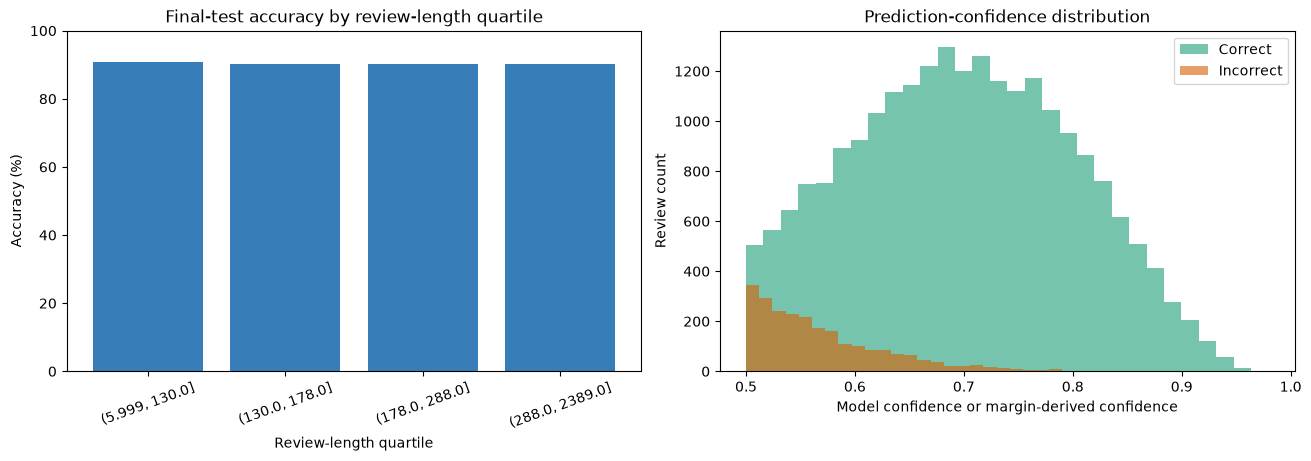

In [89]:
# Examine final-test performance by review length and inspect the most
# confident IMDB errors.
# Personal notebook addition (not in HTB): uses the final-test results for
# post-hoc analysis only; it does not alter model selection or refit the
# artifact.

imdb_final_test_predictions["review_preview"] = (
    imdb_final_test_predictions["review"].str.replace(
        r"\s+",
        " ",
        regex=True,
    ).str.slice(0, 350)
)

imdb_final_test_predictions["length_quartile"] = pd.qcut(
    imdb_final_test_predictions[
        "review_word_count"
    ],
    q=4,
    duplicates="drop",
)

imdb_length_diagnostics = (
    imdb_final_test_predictions.groupby(
        "length_quartile",
        observed=True,
    )
    .agg(
        review_count=(
            "correct",
            "size",
        ),
        accuracy=(
            "correct",
            "mean",
        ),
        median_word_count=(
            "review_word_count",
            "median",
        ),
        median_confidence=(
            "confidence",
            "median",
        ),
    )
    .reset_index()
)

display(imdb_length_diagnostics.round(3))

imdb_final_test_errors = (
    imdb_final_test_predictions.loc[
        ~imdb_final_test_predictions["correct"]
    ]
    .sort_values(
        "confidence",
        ascending=False,
    )
    .copy()
)

display(
    imdb_final_test_errors[
        [
            "sentiment",
            "predicted_sentiment",
            "confidence",
            "review_word_count",
            "review_preview",
        ]
    ].head(12)
)

figure, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(13, 4.5),
    constrained_layout=True,
)

axes[0].bar(
    imdb_length_diagnostics[
        "length_quartile"
    ].astype(str),
    100 * imdb_length_diagnostics[
        "accuracy"
    ],
    color="#377eb8",
)

axes[0].set_title(
    "Final-test accuracy by review-length quartile"
)
axes[0].set_xlabel("Review-length quartile")
axes[0].set_ylabel("Accuracy (%)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylim(0, 100)

axes[1].hist(
    imdb_final_test_predictions.loc[
        imdb_final_test_predictions["correct"],
        "confidence",
    ],
    bins=30,
    alpha=0.6,
    label="Correct",
    color="#1b9e77",
)

axes[1].hist(
    imdb_final_test_predictions.loc[
        ~imdb_final_test_predictions["correct"],
        "confidence",
    ],
    bins=30,
    alpha=0.6,
    label="Incorrect",
    color="#d95f02",
)

axes[1].set_title(
    "Prediction-confidence distribution"
)
axes[1].set_xlabel(
    "Model confidence or margin-derived confidence"
)
axes[1].set_ylabel("Review count")
axes[1].legend()

plt.show()


## Measure error slices, then package the pipeline

The post-hoc analysis compares errors and confidence behavior across message-length bands. Such slices are modest but valuable: they can reveal a model that performs well on typical messages while becoming uncertain or brittle on unusually short or long inputs.

The final export stores the vectorizer and classifier together. Reloading the artifact and running a smoke test verifies that the deployed representation and estimator remain compatible after serialization. The empty cell that follows is left untouched; the conclusion is added after it so the notebook ends with interpretation rather than with executable state.


In [90]:
# Export the final IMDB pipeline as the exact portable Joblib artifact
# required by the HTB evaluator.
# Personal notebook addition (not in HTB): persists reproducibility metadata,
# checksums, package versions, and final metrics alongside the upload
# artifact.

import hashlib
import json
import platform
import sys
from datetime import datetime, timezone

import joblib
import sklearn


IMDB_MODEL_PATH = (
    IMDB_ARTIFACT_DIRECTORY
    / IMDB_MODEL_FILENAME
)

IMDB_METADATA_PATH = (
    IMDB_ARTIFACT_DIRECTORY
    / "skills_assessment_metadata.json"
)

joblib.dump(
    imdb_final_model,
    IMDB_MODEL_PATH,
    compress=3,
)

imdb_final_metric_values = {
    metric_name: float(metric_value)
    for metric_name, metric_value in imdb_final_test_metrics[
        "value"
    ].items()
}

imdb_artifact_sha256 = hashlib.sha256(
    IMDB_MODEL_PATH.read_bytes()
).hexdigest()

imdb_artifact_metadata = {
    "artifact_filename": IMDB_MODEL_FILENAME,
    "artifact_path": str(
        IMDB_MODEL_PATH.resolve()
    ),
    "artifact_sha256": imdb_artifact_sha256,
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "selected_candidate": imdb_selected_model_name,
    "input_format": "HTB train.json/test.json",
    "label_contract": {
        "negative": 0,
        "positive": 1,
    },
    "dataset_counts": {
        "model_training": len(
            imdb_model_train
        ),
        "validation": len(imdb_validation),
        "final_refit_training": len(
            imdb_final_training_frame
        ),
        "official_final_test": len(
            imdb_final_test
        ),
    },
    "validation_scoreboard": (
        imdb_validation_scoreboard.to_dict(
            orient="records"
        )
    ),
    "final_test_metrics": imdb_final_metric_values,
    "python_version": sys.version,
    "scikit_learn_version": sklearn.__version__,
    "platform": platform.platform(),
}

IMDB_METADATA_PATH.write_text(
    json.dumps(
        imdb_artifact_metadata,
        indent=2,
    ),
    encoding="utf-8",
)

imdb_export_summary = pd.DataFrame(
    {
        "artifact": [
            "HTB upload model",
            "Experiment metadata",
        ],
        "path": [
            str(IMDB_MODEL_PATH.resolve()),
            str(IMDB_METADATA_PATH.resolve()),
        ],
        "size_kb": [
            IMDB_MODEL_PATH.stat().st_size / 1024,
            IMDB_METADATA_PATH.stat().st_size / 1024,
        ],
    }
)

display(imdb_export_summary.round(1))


,artifact,path,size_kb
0,HTB upload model,/Users/seankilfoy/Documents/Studies/HTB Academ...,2893.8
1,Experiment metadata,/Users/seankilfoy/Documents/Studies/HTB Academ...,1.8


In [91]:
# Reload the exported Skills Assessment artifact and verify the HTB inference
# contract before transfer.
# Personal notebook addition (not in HTB): confirms that the saved object is a
# standard Joblib-loaded pipeline accepting raw reviews and returning only
# integer labels 0 or 1.

imdb_reloaded_model = joblib.load(
    IMDB_MODEL_PATH
)

imdb_smoke_test_reviews = [
    (
        "An excellent, moving film with memorable performances "
        "and a satisfying ending."
    ),
    (
        "A tedious and poorly written movie that I would not "
        "recommend to anyone."
    ),
]

imdb_smoke_test_predictions = np.asarray(
    imdb_reloaded_model.predict(
        imdb_smoke_test_reviews
    )
).astype(int)

if len(imdb_smoke_test_predictions) != len(
    imdb_smoke_test_reviews
):
    raise AssertionError(
        "Reloaded model did not return one prediction per review."
    )

if not set(imdb_smoke_test_predictions).issubset(
    {0, 1}
):
    raise AssertionError(
        "Reloaded model predictions must use the HTB label contract: 0 or 1."
    )

if not (
    hasattr(imdb_reloaded_model, "named_steps")
    and "vectorizer" in imdb_reloaded_model.named_steps
    and "classifier" in imdb_reloaded_model.named_steps
):
    raise TypeError(
        "Export is not the expected portable scikit-learn text pipeline."
    )

imdb_upload_readiness = pd.DataFrame(
    {
        "check": [
            "Artifact exists",
            "Reloaded from Joblib",
            "Accepts raw review strings",
            "Predictions conform to 0/1 labels",
            "HTB upload filename",
        ],
        "result": [
            IMDB_MODEL_PATH.exists(),
            type(imdb_reloaded_model).__name__,
            imdb_smoke_test_predictions.tolist(),
            set(imdb_smoke_test_predictions).issubset(
                {0, 1}
            ),
            IMDB_MODEL_PATH.name,
        ],
    }
)

display(imdb_upload_readiness)

print(
    "Upload-ready artifact: "
    f"{IMDB_MODEL_PATH.resolve()}"
)


,check,result
0,Artifact exists,True
1,Reloaded from Joblib,Pipeline
2,Accepts raw review strings,"[1, 0]"
3,Predictions conform to 0/1 labels,True
4,HTB upload filename,skills_assessment.joblib


Upload-ready artifact: /Users/seankilfoy/Documents/Studies/HTB Academy/AI Red Teamer/Applications of AI in InfoSec/imdb_skills_assessment/artifacts/skills_assessment.joblib


# Conclusion: a reusable security-ML workflow

This notebook began with six columns of imperfect network events and ended with a family of reusable model artifacts spanning tabular traffic, short-form language, image-based malware representations, and a separate text assessment. The datasets differ radically in modality, scale, and label structure, but the reliable workflow is remarkably consistent.

## What the case studies establish

- **Data quality is part of the model.** Placeholder strings, invalid ports, missing addresses, duplicate network rows, duplicate messages, image collisions, and train/test overlap all change what a score means. Validation rules and audits are not administrative overhead; they define the evidence the model is allowed to learn from.
- **Representation determines the available signal.** One-hot encoding preserves categorical semantics in network logs. `log1p` makes a skewed byte count easier to model. Token normalization and n-grams expose local language patterns. TF-IDF emphasizes discriminative terms. Image tensors preserve byteplot structure for a convolutional backbone. Each representation is a hypothesis about what matters.
- **Evaluation must follow the operational risk.** Spam detection requires a precision/recall conversation, network detection requires attention to rare attack classes, and malware classification benefits from balanced and macro-averaged metrics in addition to accuracy. Confusion matrices, per-class reports, ROC/precision-recall views, and error slices prevent a dominant class from writing the entire performance narrative.
- **Leakage control is a design constraint.** Vectorizers belong inside validation pipelines, validation partitions must be created before tuning, the malware test set must remain untouched while checkpoints are selected, and known assessment overlaps must be documented instead of ignored. A high score without a credible separation between fitting and evaluation is not strong evidence.
- **A notebook can be an engineering artifact.** Idempotent downloads, explicit manifests, deterministic splits, fresh integrity checks, checkpoint restoration, model reload tests, and saved preprocessing make the work reproducible beyond the current kernel session. The model is not complete when training ends; it is complete when another process can load it and reproduce the intended inference path.

## Limitations and next steps

These datasets are educational benchmarks, so their results should not be presented as production threat-detection guarantees. The network data is historically derived, the SMS corpus may contain collection-specific language patterns and duplicates, the Malimg images encode a constrained static view of executables, and the sentiment assessment is not a security label. A production extension would add time-aware splits, external validation, drift monitoring, calibrated thresholds, cost-sensitive decision policies, lineage for every downloaded artifact, and a documented retraining and rollback procedure.

The next level of this work is therefore not simply a larger model. It is a stronger evidence chain: version the data and environment, record the preprocessing contract, test the artifact on representative future inputs, monitor subgroup and rare-class behavior, and make the human or operational consequence of each error explicit. That is the central lesson carried across the module—from exploratory data analysis to deployment-ready model validation.

## Portfolio summary

The resulting notebook is best understood as an auditable case-study collection rather than a single benchmark. It demonstrates how an analyst or engineer can move from raw observations to defensible model decisions while preserving provenance, explaining tradeoffs, and leaving behind artifacts that can be inspected and reused. The narrative and the code together make the work suitable for review: the code shows what was executed, and the surrounding analysis explains why it was the right next step.
